# How Small a Planet Can TESS Really See?



I am using real TESS light curves, hiding synthetic transits inside them, and asking a simple question:

> How small can a planet get before my frozen search pipeline stops recovering it reliably?

I keep the work in the order I actually built it:

1. real TESS data
2. preprocessing
3. blind BLS search
4. known-planet validation
5. frozen baseline
6. realistic transit injection
6.5. development control stars
7. recovery pilot
7.5. frozen RECOVERY_V2 and held-out split
8. 1,000-case completeness benchmark

I keep failed ideas in the record. I do not change the rules after seeing the answer.

# 0. Setup

In [1]:
pip install -r requirements_tess_project.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install numpy pandas matplotlib scipy astropy lightkurve astroquery batman-package joblib jupyterlab ipykernel pyyaml pytest transitleastsquares

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from datetime import datetime, timezone
import json, os, time, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightkurve as lk
import batman

from scipy.signal import savgol_filter
from astropy.timeseries import BoxLeastSquares
import astropy.units as u
import astropy.constants as const
from astroquery.mast import Catalogs

warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path.cwd() / "tess_small_planet_project"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "configs"
LOG_DIR = PROJECT_ROOT / "logs"

for d in [DATA_DIR, FIGURES_DIR, RESULTS_DIR, CONFIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CPU_COUNT = os.cpu_count() or 2
N_JOBS = max(1, CPU_COUNT - 2)

RUN_OBJECTIVE_7_PILOT = True
RUN_OBJECTIVE_8_BENCHMARK = True

print("Project:", PROJECT_ROOT.resolve())
print("CPU cores:", CPU_COUNT)
print("Week 11 workers:", N_JOBS)

c:\Users\waqar\anaconda3\envs\sprint\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Project: C:\Users\waqar\OneDrive\Desktop\ayesha waqas project\tess_small_planet_project
CPU cores: 16
Week 11 workers: 14


# 1. Real TESS data

I start with WASP-18 because it gives me a strong known transit to validate the basic machinery.

I inspect one SPOC sector rather than blindly stitching everything together.

In [4]:
def normalize_flux(flux):
    flux = np.asarray(flux, float)
    med = np.nanmedian(flux)
    if not np.isfinite(med) or med == 0:
        raise ValueError("Invalid median flux")
    return flux / med

def download_spoc_sector(target, sector=None):
    search = lk.search_lightcurve(target, mission="TESS", author="SPOC")
    if len(search) == 0:
        raise RuntimeError(f"No SPOC TESS light curve for {target}")

    table = search.table.to_pandas().reset_index(drop=True)
    sector_col = "sequence_number" if "sequence_number" in table.columns else "sector"
    sector_values = pd.to_numeric(table[sector_col], errors="coerce")

    if sector is None:
        sector = int(np.nanmin(sector_values))
    idxs = np.where(np.asarray(sector_values == sector))[0]
    if len(idxs) == 0:
        raise RuntimeError(f"Sector {sector} unavailable for {target}")

    chosen = search[int(idxs[0]):int(idxs[0])+1]

    try:
        lc = chosen.download(flux_column="pdcsap_flux", quality_bitmask="none")
        flux_product = "PDCSAP_FLUX"
    except Exception:
        lc = chosen.download(flux_column="sap_flux", quality_bitmask="none")
        flux_product = "SAP_FLUX"

    t = np.asarray(lc.time.value, float)
    f = np.asarray(lc.flux.value, float)
    q = np.asarray(lc.quality).astype(np.int64)

    good = np.isfinite(t) & np.isfinite(f) & (q == 0)
    t, f = t[good], normalize_flux(f[good])

    return {
        "target": target,
        "sector": sector,
        "flux_product": flux_product,
        "time": t,
        "flux": f,
    }

wasp18 = download_spoc_sector("WASP-18")
time_input = wasp18["time"]
flux_input = wasp18["flux"]

print("Sector:", wasp18["sector"])
print("Product:", wasp18["flux_product"])
print("Points:", len(time_input))
print("Cadence [min]:", np.nanmedian(np.diff(time_input)) * 1440)

Sector: 2
Product: PDCSAP_FLUX
Points: 18299
Cadence [min]: 2.0000324045395246


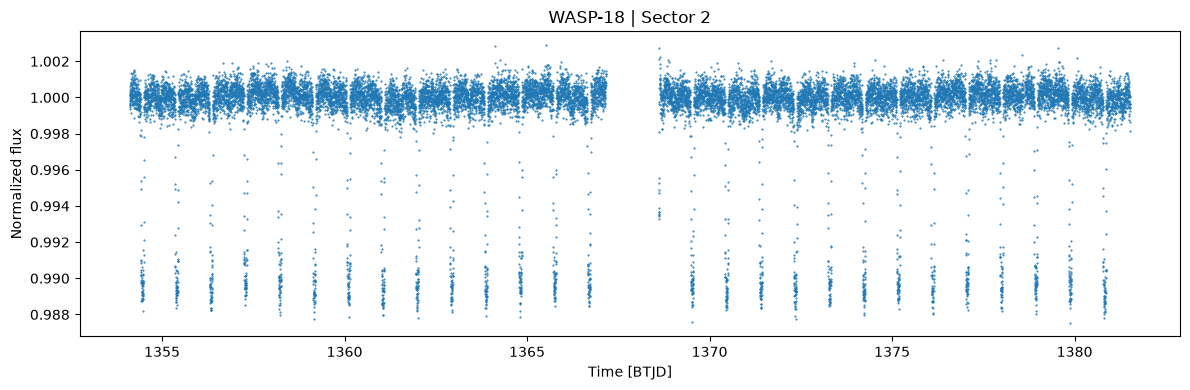

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_input, flux_input, ".", ms=1)
ax.set(xlabel="Time [BTJD]", ylabel="Normalized flux",
       title=f"WASP-18 | Sector {wasp18['sector']}")
fig.tight_layout()
plt.show()

# 2. Preprocessing

I keep the baseline deliberately simple. I also keep a Savitzky-Golay option because the early WASP-18 experiment showed that smoothing can change transit depth.

In [6]:
def robust_sigma(x):
    x = np.asarray(x, float)
    med = np.nanmedian(x)
    return float(1.4826 * np.nanmedian(np.abs(x - med)))

def preprocess(time_values, flux_values, detrend=False, window=101, polyorder=2):
    t = np.asarray(time_values, float)
    f = normalize_flux(flux_values)

    if not detrend:
        return {"time": t, "flux": f}

    w = min(int(window), len(f) - 1)
    if w % 2 == 0:
        w -= 1
    w = max(w, polyorder + 3)
    if w % 2 == 0:
        w += 1

    trend = savgol_filter(f, window_length=w, polyorder=polyorder)
    return {"time": t, "flux": f / trend, "trend": trend}

baseline_preprocessed = preprocess(time_input, flux_input, detrend=False)
savgol_preprocessed = preprocess(time_input, flux_input, detrend=True, window=101)

# 3. Blind BLS search

In [7]:
BLS_CONFIG = {
    "minimum_period_days": 0.5,
    "maximum_period_days": 15.0,
    "durations_hours": [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0],
    "minimum_n_transit": 2,
    "oversample": 10,
}

def build_period_grid(t, f, config=BLS_CONFIG):
    durations = np.asarray(config["durations_hours"]) / 24.0
    bls = BoxLeastSquares(np.asarray(t, float), np.asarray(f, float))
    return np.asarray(
        bls.autoperiod(
            durations,
            minimum_period=config["minimum_period_days"],
            maximum_period=config["maximum_period_days"],
            minimum_n_transit=config["minimum_n_transit"],
        ),
        float,
    )

def blind_bls_search(t, f, period_grid=None, config=BLS_CONFIG):
    t, f = np.asarray(t, float), np.asarray(f, float)
    durations = np.asarray(config["durations_hours"]) / 24.0
    if period_grid is None:
        period_grid = build_period_grid(t, f, config)

    start = time.perf_counter()
    bls = BoxLeastSquares(t, f)
    out = bls.power(period_grid, durations, oversample=config["oversample"])
    power = np.asarray(out.power, float)
    best = int(np.nanargmax(power))

    s = robust_sigma(power)
    sde = np.nan if (not np.isfinite(s) or s <= 0) else (power[best] - np.nanmedian(power)) / s

    return {
        "found_period_days": float(out.period[best]),
        "found_duration_days": float(out.duration[best]),
        "found_epoch_btjd": float(out.transit_time[best]),
        "found_depth": float(out.depth[best]),
        "bls_power": float(power[best]),
        "detection_sde": float(sde),
        "runtime_seconds": time.perf_counter() - start,
    }

candidate = blind_bls_search(
    savgol_preprocessed["time"],
    savgol_preprocessed["flux"],
)
candidate

{'found_period_days': 0.9414989801168709,
 'found_duration_days': 0.08333333333333333,
 'found_epoch_btjd': 1354.4573405950525,
 'found_depth': 0.0013798996694363804,
 'bls_power': 0.0015128258011310972,
 'detection_sde': 232.58495554367917,
 'runtime_seconds': 2.6967434000000026}

# 4. Known-planet validation and preprocessing diagnostic

This is where I first saw the important failure mode: the period stayed stable while aggressive smoothing could suppress the depth and make the planet look much smaller.

In [8]:
def folded_depth(t, f, period, epoch, duration):
    phase_time = ((t - epoch + 0.5 * period) % period) - 0.5 * period
    inside = np.abs(phase_time) <= duration / 2
    if inside.sum() < 3:
        return np.nan
    return float(np.nanmedian(f[~inside]) - np.nanmedian(f[inside]))

WASP18_PERIOD = 0.94145223
WASP18_RADIUS_REARTH = 13.89913607
WASP18_STAR_RADIUS_RSUN = 1.319

rows = []
for label, detrend, window in [
    ("no_detrending", False, 101),
    ("savgol_101", True, 101),
    ("savgol_301", True, 301),
    ("savgol_501", True, 501),
]:
    x = preprocess(time_input, flux_input, detrend=detrend, window=window)
    c = blind_bls_search(x["time"], x["flux"])
    depth = folded_depth(
        x["time"], x["flux"],
        c["found_period_days"], c["found_epoch_btjd"], c["found_duration_days"]
    )
    rprs = np.sqrt(depth) if np.isfinite(depth) and depth > 0 else np.nan
    radius = rprs * WASP18_STAR_RADIUS_RSUN * (const.R_sun / const.R_earth).decompose().value

    rows.append({
        "preprocessing": label,
        "period_days": c["found_period_days"],
        "period_error_percent": abs(c["found_period_days"] - WASP18_PERIOD) / WASP18_PERIOD * 100,
        "depth": depth,
        "estimated_radius_rearth": radius,
        "radius_error_percent": abs(radius - WASP18_RADIUS_REARTH) / WASP18_RADIUS_REARTH * 100,
    })

objective4_diagnostics = pd.DataFrame(rows)
display(objective4_diagnostics)

,preprocessing,period_days,period_error_percent,depth,estimated_radius_rearth,radius_error_percent
0,no_detrending,0.941499,0.004966,0.010333,14.624610,5.219558
1,savgol_101,0.941499,0.004966,0.001214,5.012408,63.937270
2,savgol_301,0.941499,0.004966,0.006132,11.265784,18.946157
3,savgol_501,0.941499,0.004966,0.008234,13.055368,6.070651


# 5. Freeze baseline_v1 and validate five known planets

I now stop changing the baseline. Every target gets the same preprocessing and search settings.

In [9]:
VALIDATION_TARGETS = [
    ("VAL-001", "WASP-18", 0.94145223),
    ("VAL-002", "WASP-19", 0.788839),
    ("VAL-003", "WASP-43", 0.813475),
    ("VAL-004", "WASP-121", 1.274925),
    ("VAL-005", "WASP-4", 1.338231),
]

validation_rows = []
for validation_id, target, reference_period in VALIDATION_TARGETS:
    print("Validating:", target)
    host = download_spoc_sector(target)
    c = blind_bls_search(host["time"], host["flux"])
    err = abs(c["found_period_days"] - reference_period) / reference_period

    validation_rows.append({
        "validation_id": validation_id,
        "target": target,
        "sector": host["sector"],
        "found_period_days": c["found_period_days"],
        "reference_period_days": reference_period,
        "period_error_percent": err * 100,
        "period_class": "EXACT" if err <= 0.01 else "MISS",
    })

baseline_v1_validation = pd.DataFrame(validation_rows)
display(baseline_v1_validation)

with open(CONFIG_DIR / "baseline_v1.json", "w") as f:
    json.dump({"version": "baseline_v1", "bls": BLS_CONFIG, "detrend": False}, f, indent=2)

Validating: WASP-18
Validating: WASP-19
Validating: WASP-43
Validating: WASP-121
Validating: WASP-4


,validation_id,target,sector,found_period_days,reference_period_days,period_error_percent,period_class
0,VAL-001,WASP-18,2,0.941499,0.941452,0.004966,EXACT
1,VAL-002,WASP-19,9,0.788770,0.788839,0.008749,EXACT
2,VAL-003,WASP-43,9,0.813505,0.813475,0.003698,EXACT
3,VAL-004,WASP-121,7,1.274923,1.274925,0.000184,EXACT
4,VAL-005,WASP-4,2,1.338249,1.338231,0.001369,EXACT


# 6. Realistic transit injection

I keep the real TESS noise, timestamps and gaps. I only multiply in a physical BATMAN transit.

In [10]:
def a_over_rstar(period_days, mass_msun, radius_rsun):
    P = (period_days * u.day).to(u.s)
    a = (const.G * mass_msun * const.M_sun * P**2 / (4 * np.pi**2)) ** (1/3)
    return float((a / (radius_rsun * const.R_sun)).decompose().value)

def inject_transit(t, f, period, t0, rprs, mass_msun, radius_rsun, impact_b, supersample=7):
    t, f = np.asarray(t, float), np.asarray(f, float)
    a_rs = a_over_rstar(period, mass_msun, radius_rsun)
    inc = float(np.degrees(np.arccos(np.clip(impact_b / a_rs, -1, 1))))
    cadence = float(np.nanmedian(np.diff(t)))

    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = float(t0), float(period), float(rprs), a_rs, inc
    p.ecc, p.w, p.u, p.limb_dark = 0.0, 90.0, [0.3, 0.2], "quadratic"

    model = batman.TransitModel(
        p, t, exp_time=cadence, supersample_factor=int(supersample)
    ).light_curve(p)

    return f * model, {
        "period_days": float(period),
        "t0": float(t0),
        "rp_over_rstar": float(rprs),
        "impact_parameter": float(impact_b),
        "a_over_rstar": a_rs,
        "inclination_deg": inc,
        "model_depth": float(1 - np.nanmin(model)),
        "cadence_days": cadence,
    }

test_flux, test_truth = inject_transit(
    time_input, flux_input,
    period=2.5,
    t0=time_input.min() + 0.7,
    rprs=0.10,
    mass_msun=1.294,
    radius_rsun=1.319,
    impact_b=0.2,
)

assert len(test_flux) == len(flux_input)
assert np.isfinite(test_flux).all()
print(test_truth)

{'period_days': 2.5, 't0': 1354.8115072617193, 'rp_over_rstar': 0.1, 'impact_parameter': 0.2, 'a_over_rstar': 6.404193218915362, 'inclination_deg': 88.21038825903628, 'model_depth': 0.011457938303827464, 'cadence_days': 0.0013889113920413365}


# 6.5. Frozen development control stars

These five stars are development data. They span very quiet to very variable light curves.

I never promote one of them into the final held-out set after seeing its performance.

In [11]:
FROZEN_DEVELOPMENT_HOSTS = [
    ("CONTROL-001", "18 Sco",     135656809, 91),
    ("CONTROL-002", "HD 102365", 454082369, 10),
    ("CONTROL-003", "HD 76151",   62569281,   8),
    ("CONTROL-004", "HD 30495",  117979951,  5),
    ("CONTROL-005", "HD 20630",  343813545,  4),
]

development_host_data = {}
host_rows = []

for control_id, name, tic_id, sector in FROZEN_DEVELOPMENT_HOSTS:
    print("Loading:", control_id, name)
    host = download_spoc_sector(name, sector=sector)

    tic = Catalogs.query_criteria(catalog="TIC", ID=int(tic_id))
    r = tic[0]

    host.update({
        "control_id": control_id,
        "candidate_name": name,
        "tic_id": tic_id,
        "stellar_mass_msun": float(r["mass"]),
        "stellar_radius_rsun": float(r["rad"]),
        "teff_kelvin": float(r["Teff"]),
        "robust_rms": robust_sigma(host["flux"] - np.nanmedian(host["flux"])),
        "cadence_minutes": np.nanmedian(np.diff(host["time"])) * 1440,
    })

    development_host_data[control_id] = host
    host_rows.append({k: v for k, v in host.items() if k not in {"time", "flux"}})

development_hosts_df = pd.DataFrame(host_rows)
display(development_hosts_df)

host_bls_grids = {
    cid: build_period_grid(h["time"], h["flux"])
    for cid, h in development_host_data.items()
}

Loading: CONTROL-001 18 Sco
Loading: CONTROL-002 HD 102365
Loading: CONTROL-003 HD 76151
Loading: CONTROL-004 HD 30495
Loading: CONTROL-005 HD 20630


,target,sector,flux_product,control_id,candidate_name,tic_id,stellar_mass_msun,stellar_radius_rsun,teff_kelvin,robust_rms,cadence_minutes
0,18 Sco,91,PDCSAP_FLUX,CONTROL-001,18 Sco,135656809,1.04,1.039140,5791.00,0.000194,0.333351
1,HD 102365,10,PDCSAP_FLUX,CONTROL-002,HD 102365,454082369,1.01,0.951380,5672.00,0.000101,1.999990
2,HD 76151,8,PDCSAP_FLUX,CONTROL-003,HD 76151,62569281,1.04,0.983906,5776.65,0.000239,1.999979
3,HD 30495,5,PDCSAP_FLUX,CONTROL-004,HD 30495,117979951,1.05,0.962191,5834.00,0.001261,2.000003
4,HD 20630,4,PDCSAP_FLUX,CONTROL-005,HD 20630,343813545,1.02,0.945495,5711.88,0.009572,2.000026


# 7. RECOVERY_V2

The 300-case pilot rejected the original universal `SDE >= 6` rule because all five no-injection controls crossed it.

So I keep SDE as a diagnostic and define recovery by the period match.

In [12]:
RECOVERY_V2 = {
    "version": "RECOVERY_V2",
    "exact_tolerance": 0.01,
    "alias_tolerance": 0.01,
    "near_tolerance": 0.02,
}

def evaluate_recovery_v2(true_period, found_period):
    if not np.isfinite(true_period) or not np.isfinite(found_period):
        return {"category": "FAILED", "primary_recovered": False, "alias_aware_recovered": False}

    fd = lambda x, y: abs(x - y) / abs(y)
    exact = fd(found_period, true_period)
    half = fd(found_period, true_period / 2)
    double = fd(found_period, true_period * 2)

    if exact <= 0.01:
        category = "EXACT"
    elif half <= 0.01:
        category = "HALF_ALIAS"
    elif double <= 0.01:
        category = "DOUBLE_ALIAS"
    elif exact <= 0.02:
        category = "NEAR_MATCH"
    else:
        category = "MISS"

    return {
        "category": category,
        "primary_recovered": category == "EXACT",
        "alias_aware_recovered": category in {"EXACT", "HALF_ALIAS", "DOUBLE_ALIAS"},
        "exact_fractional_error": exact,
        "half_alias_fractional_error": half,
        "double_alias_fractional_error": double,
    }

assert evaluate_recovery_v2(4, 4)["category"] == "EXACT"
assert evaluate_recovery_v2(4, 2)["category"] == "HALF_ALIAS"
assert evaluate_recovery_v2(4, 8)["category"] == "DOUBLE_ALIAS"
assert evaluate_recovery_v2(4, 4.06)["category"] == "NEAR_MATCH"
assert evaluate_recovery_v2(4, 7)["category"] == "MISS"

with open(CONFIG_DIR / "RECOVERY_V2.json", "w") as f:
    json.dump(RECOVERY_V2, f, indent=2)

print("RECOVERY_V2 frozen.")

RECOVERY_V2 frozen.


# 7.5. Frozen held-out identities

These three stars are my final test set. They are not used in the 1,000-case Week 11 benchmark.

In [13]:
heldout_hosts_df = pd.DataFrame([
    {"heldout_id": "HELDOUT-001", "candidate_name": "HD 190406", "tic_id": 275240386, "sector": 54},
    {"heldout_id": "HELDOUT-002", "candidate_name": "HD 38858",  "tic_id": 176521059, "sector": 6},
    {"heldout_id": "HELDOUT-003", "candidate_name": "HD 10307",  "tic_id": 327507922, "sector": 18},
])

heldout_hosts_df["bls_run"] = False
heldout_hosts_df["injection_run"] = False
heldout_hosts_df["used_for_tuning"] = False

display(heldout_hosts_df)

,heldout_id,candidate_name,tic_id,sector,bls_run,injection_run,used_for_tuning
0,HELDOUT-001,HD 190406,275240386,54,False,False,False
1,HELDOUT-002,HD 38858,176521059,6,False,False,False
2,HELDOUT-003,HD 10307,327507922,18,False,False,False


# 8. Week 11: 1,000 planet completeness benchmark

The grid is frozen before I run it:

- 5 development stars
- 5 radius-ratio levels
- 4 orbital periods
- 10 random phases/geometries

Total: **1,000 injected planets**.

This PC version uses Joblib CPU workers and a checkpoint CSV.

In [14]:
from joblib import Parallel, delayed

W11_PERIODS = [1.0, 3.0, 6.0, 10.0]
W11_RPRS = [0.015, 0.025, 0.040, 0.060, 0.090]
W11_REPEATS = 10

obj8_dir = RESULTS_DIR / "objective_08_week11"
obj8_dir.mkdir(parents=True, exist_ok=True)

design = []
case_no, seed = 0, 800000

for control_id in development_host_data:
    for period in W11_PERIODS:
        for rprs in W11_RPRS:
            for rep in range(1, W11_REPEATS + 1):
                case_no += 1
                seed += 1
                design.append({
                    "case_id": f"W11-{case_no:05d}",
                    "control_id": control_id,
                    "true_period_days": period,
                    "rp_over_rstar": rprs,
                    "repetition": rep,
                    "seed": seed,
                })

week11_design_df = pd.DataFrame(design)
assert len(week11_design_df) == 1000
week11_design_df.to_csv(obj8_dir / "W11_injection_design.csv", index=False)

display(week11_design_df.head())

,case_id,control_id,true_period_days,rp_over_rstar,repetition,seed
0,W11-00001,CONTROL-001,1.0,0.015,1,800001
1,W11-00002,CONTROL-001,1.0,0.015,2,800002
2,W11-00003,CONTROL-001,1.0,0.015,3,800003
3,W11-00004,CONTROL-001,1.0,0.015,4,800004
4,W11-00005,CONTROL-001,1.0,0.015,5,800005


In [15]:
def run_week11_case(case):
    start = time.perf_counter()

    case_id = str(case["case_id"])
    control_id = str(case["control_id"])
    period = float(case["true_period_days"])
    rprs = float(case["rp_over_rstar"])
    seed = int(case["seed"])

    try:
        host = development_host_data[control_id]
        rng = np.random.default_rng(seed)

        b = float(rng.uniform(0, 0.7))
        t0 = float(host["time"].min() + rng.uniform(0, period))

        injected, truth = inject_transit(
            host["time"], host["flux"],
            period=period,
            t0=t0,
            rprs=rprs,
            mass_msun=host["stellar_mass_msun"],
            radius_rsun=host["stellar_radius_rsun"],
            impact_b=b,
        )

        candidate = blind_bls_search(
            host["time"], injected,
            period_grid=host_bls_grids[control_id],
        )

        evaluation = evaluate_recovery_v2(
            period,
            candidate["found_period_days"],
        )

        return {
            "case_id": case_id,
            "control_id": control_id,
            "seed": seed,
            "true_period_days": period,
            "rp_over_rstar": rprs,
            "true_epoch_btjd": t0,
            "impact_parameter": b,
            "model_depth": truth["model_depth"],
            **candidate,
            **evaluation,
            "runtime_seconds_total": time.perf_counter() - start,
            "status": "SUCCESS",
        }

    except Exception as exc:
        return {
            "case_id": case_id,
            "control_id": control_id,
            "seed": seed,
            "true_period_days": period,
            "rp_over_rstar": rprs,
            "category": "FAILED",
            "primary_recovered": False,
            "alias_aware_recovered": False,
            "runtime_seconds_total": time.perf_counter() - start,
            "status": "FAILED",
            "error": repr(exc),
        }

## Run or resume

I save after every small chunk. If this stops at 620/1000, the next run starts from the remaining 380.

In [16]:
checkpoint_path = obj8_dir / "W11_COMPLETENESS_V1_checkpoint.csv"
final_path = obj8_dir / "W11_COMPLETENESS_V1_results.csv"

if checkpoint_path.exists():
    existing = pd.read_csv(checkpoint_path).drop_duplicates("case_id", keep="last")
else:
    existing = pd.DataFrame()

done_ids = set(existing["case_id"].astype(str)) if len(existing) else set()
pending = week11_design_df[~week11_design_df["case_id"].isin(done_ids)].copy()

print("Completed:", len(done_ids))
print("Pending:", len(pending))
print("Workers:", N_JOBS)

if RUN_OBJECTIVE_8_BENCHMARK and len(pending):
    results = existing.copy()
    chunk_size = max(10, N_JOBS * 2)
    session_start = time.perf_counter()

    for start_i in range(0, len(pending), chunk_size):
        chunk = pending.iloc[start_i:start_i + chunk_size].to_dict("records")

        chunk_results = Parallel(n_jobs=N_JOBS, backend="loky")(
            delayed(run_week11_case)(case) for case in chunk
        )

        results = pd.concat([results, pd.DataFrame(chunk_results)], ignore_index=True)
        results = results.drop_duplicates("case_id", keep="last")

        tmp = checkpoint_path.with_suffix(".tmp.csv")
        results.to_csv(tmp, index=False)
        tmp.replace(checkpoint_path)

        print(
            f"Checkpoint: {len(results)}/1000 "
            f"| session {(time.perf_counter()-session_start)/60:.1f} min"
        )

    week11_results_df = results.sort_values("case_id").reset_index(drop=True)
    week11_results_df.to_csv(final_path, index=False)

else:
    source = final_path if final_path.exists() else checkpoint_path
    if not source.exists():
        raise RuntimeError("No Week 11 result file exists yet.")
    week11_results_df = pd.read_csv(source)

print("Rows available:", len(week11_results_df))

Completed: 1000
Pending: 0
Workers: 14
Rows available: 1000


# Completeness and uncertainty

I only freeze the final Week 11 result when all 1,000 rows are present.

Every main period × size cell contains 50 attempts, and failed runs stay in the denominator.

In [17]:
def wilson_interval(k, n, z=1.959963984540054):
    if n <= 0:
        return np.nan, np.nan
    p = k / n
    d = 1 + z*z/n
    center = (p + z*z/(2*n)) / d
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return max(0, center-half), min(1, center+half)

if len(week11_results_df) == 1000:
    rows = []

    for (period, rprs), g in week11_results_df.groupby(
        ["true_period_days", "rp_over_rstar"], sort=True
    ):
        n = len(g)
        k = int(g["primary_recovered"].sum())
        low, high = wilson_interval(k, n)

        rows.append({
            "true_period_days": period,
            "rp_over_rstar": rprs,
            "attempted": n,
            "exact_recovered": k,
            "exact_completeness": k/n,
            "exact_ci95_low": low,
            "exact_ci95_high": high,
        })

    week11_completeness_df = pd.DataFrame(rows)
    assert (week11_completeness_df["attempted"] == 50).all()
    display(week11_completeness_df)
else:
    print("Benchmark is not complete yet. Rerun the previous cell to resume.")

,true_period_days,rp_over_rstar,attempted,exact_recovered,exact_completeness,exact_ci95_low,exact_ci95_high
0,1.0,0.015,50,20,0.40,0.276084,0.538186
1,1.0,0.025,50,30,0.60,0.461814,0.723916
2,1.0,0.040,50,40,0.80,0.669629,0.887562
3,1.0,0.060,50,40,0.80,0.669629,0.887562
4,1.0,0.090,50,40,0.80,0.669629,0.887562
5,3.0,0.015,50,20,0.40,0.276084,0.538186
6,3.0,0.025,50,29,0.58,0.442334,0.706250
7,3.0,0.040,50,33,0.66,0.521538,0.775631
8,3.0,0.060,50,40,0.80,0.669629,0.887562
9,3.0,0.090,50,40,0.80,0.669629,0.887562


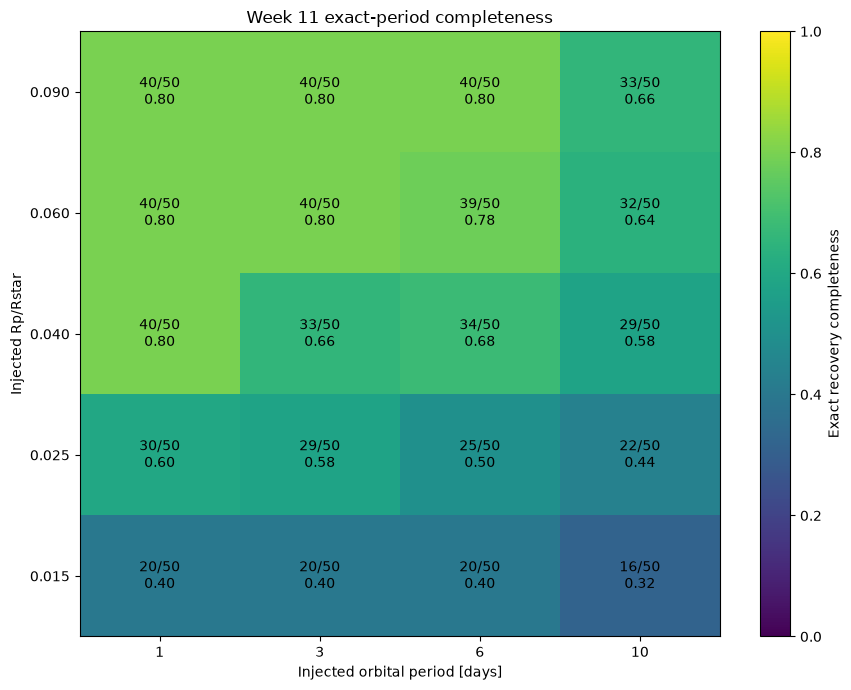

In [18]:
if len(week11_results_df) == 1000:
    pivot = week11_completeness_df.pivot(
        index="rp_over_rstar",
        columns="true_period_days",
        values="exact_completeness",
    ).sort_index()

    counts = week11_completeness_df.pivot(
        index="rp_over_rstar",
        columns="true_period_days",
        values="exact_recovered",
    ).sort_index()

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(pivot.to_numpy(), origin="lower", aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{x:g}" for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{x:.3f}" for x in pivot.index])

    ax.set_xlabel("Injected orbital period [days]")
    ax.set_ylabel("Injected Rp/Rstar")
    ax.set_title("Week 11 exact-period completeness")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(
                j, i,
                f"{int(counts.iloc[i,j])}/50\n{pivot.iloc[i,j]:.2f}",
                ha="center", va="center"
            )

    fig.colorbar(im, ax=ax, label="Exact recovery completeness")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "W11_exact_completeness_heatmap.png", dpi=220)
    plt.show()

In [19]:
if len(week11_results_df) == 1000:
    host_summary = (
        week11_results_df.groupby("control_id")
        .agg(
            attempted=("case_id", "count"),
            exact_recovered=("primary_recovered", "sum"),
            exact_completeness=("primary_recovered", "mean"),
        )
        .reset_index()
        .merge(
            development_hosts_df[
                ["control_id", "candidate_name", "robust_rms", "cadence_minutes"]
            ],
            on="control_id",
            how="left",
        )
        .sort_values("robust_rms")
    )

    size_summary = (
        week11_results_df.groupby("rp_over_rstar")
        .agg(
            attempted=("case_id", "count"),
            exact_recovered=("primary_recovered", "sum"),
            exact_completeness=("primary_recovered", "mean"),
        )
        .reset_index()
    )

    period_summary = (
        week11_results_df.groupby("true_period_days")
        .agg(
            attempted=("case_id", "count"),
            exact_recovered=("primary_recovered", "sum"),
            exact_completeness=("primary_recovered", "mean"),
        )
        .reset_index()
    )

    boundary_cells = week11_completeness_df[
        week11_completeness_df["exact_completeness"].between(0.20, 0.80)
    ].copy()

    print("By planet size")
    display(size_summary)
    print("By period")
    display(period_summary)
    print("By host")
    display(host_summary)
    print("Detection-boundary cells")
    display(boundary_cells)

By planet size


,rp_over_rstar,attempted,exact_recovered,exact_completeness
0,0.015,200,76,0.380
1,0.025,200,106,0.530
2,0.040,200,136,0.680
3,0.060,200,151,0.755
4,0.090,200,153,0.765


By period


,true_period_days,attempted,exact_recovered,exact_completeness
0,1.0,250,170,0.680
1,3.0,250,162,0.648
2,6.0,250,158,0.632
3,10.0,250,132,0.528


By host


,control_id,attempted,exact_recovered,exact_completeness,candidate_name,robust_rms,cadence_minutes
1,CONTROL-002,200,200,1.000,HD 102365,0.000101,1.999990
0,CONTROL-001,200,183,0.915,18 Sco,0.000194,0.333351
2,CONTROL-003,200,137,0.685,HD 76151,0.000239,1.999979
3,CONTROL-004,200,102,0.510,HD 30495,0.001261,2.000003
4,CONTROL-005,200,0,0.000,HD 20630,0.009572,2.000026


Detection-boundary cells


,true_period_days,rp_over_rstar,attempted,exact_recovered,exact_completeness,exact_ci95_low,exact_ci95_high
0,1.0,0.015,50,20,0.40,0.276084,0.538186
1,1.0,0.025,50,30,0.60,0.461814,0.723916
2,1.0,0.040,50,40,0.80,0.669629,0.887562
3,1.0,0.060,50,40,0.80,0.669629,0.887562
4,1.0,0.090,50,40,0.80,0.669629,0.887562
5,3.0,0.015,50,20,0.40,0.276084,0.538186
6,3.0,0.025,50,29,0.58,0.442334,0.706250
7,3.0,0.040,50,33,0.66,0.521538,0.775631
8,3.0,0.060,50,40,0.80,0.669629,0.887562
9,3.0,0.090,50,40,0.80,0.669629,0.887562


# Freeze Week 11

Once all 1,000 cases are present, I save a manifest and treat this benchmark as fixed. Later preprocessing experiments create new result tables instead of rewriting this one.

In [20]:
if len(week11_results_df) == 1000:
    exact_count = int(week11_results_df["primary_recovered"].sum())
    completeness = exact_count / 1000
    ci = wilson_interval(exact_count, 1000)

    freeze = {
        "version": "W11_COMPLETENESS_V1",
        "frozen_utc": datetime.now(timezone.utc).isoformat(),
        "recovery_protocol": "RECOVERY_V2",
        "expected_cases": 1000,
        "observed_cases": 1000,
        "exact_recovered": exact_count,
        "exact_completeness": completeness,
        "exact_ci95_low": ci[0],
        "exact_ci95_high": ci[1],
        "development_hosts": list(development_host_data.keys()),
        "heldout_hosts_used": False,
        "result_file": str(final_path),
    }

    with open(CONFIG_DIR / "W11_COMPLETENESS_V1_FREEZE_MANIFEST.json", "w") as f:
        json.dump(freeze, f, indent=2)

    print("Exact recovered:", f"{exact_count}/1000")
    print("Exact completeness:", f"{completeness:.4f}")
    print("95% CI:", f"[{ci[0]:.4f}, {ci[1]:.4f}]")
    print("Held-out hosts touched: NO")
    print("W11_COMPLETENESS_V1 frozen.")

Exact recovered: 622/1000
Exact completeness: 0.6220
95% CI: [0.5915, 0.6515]
Held-out hosts touched: NO
W11_COMPLETENESS_V1 frozen.


✅ Frozen Week 11 benchmark found.
✅ 1000 Week 11 cases found.
✅ Held-out firewall intact.
CPU cores: 16
Week 12 workers: 4
Checkpoint chunk size: 8
✅ Week 12 protocol frozen.
✅ Preprocessing function ready.

PAIRING SANITY CHECK


,case_id,epoch_original,epoch_regenerated,b_original,b_regenerated,depth_original,depth_regenerated
0,W11-00001,3775.840794,3775.840794,0.471457,0.471457,0.000250,0.000250
1,W11-00200,3777.458002,3777.458002,0.545806,0.545806,0.008831,0.008831
2,W11-00400,1577.537915,1577.537915,0.019077,0.019077,0.009340,0.009340
3,W11-00600,1524.712740,1524.712740,0.326059,0.326059,0.009180,0.009180
4,W11-00800,1438.027935,1438.027935,0.274447,0.274447,0.009229,0.009229
5,W11-01000,1414.902396,1414.902396,0.455988,0.455988,0.009006,0.009006


✅ Week 11 injections reproduce correctly.
✅ Frozen Week 11 baseline imported.
✅ Week 12 design: 3000 new searches
Already completed: 3000
Still pending: 0

New searches: 3000
Failures: 0
✅ New preprocessing searches finished.
✅ Perfect pairing confirmed:
1000 cases × 4 methods = 4000

✅ No-injection controls complete.


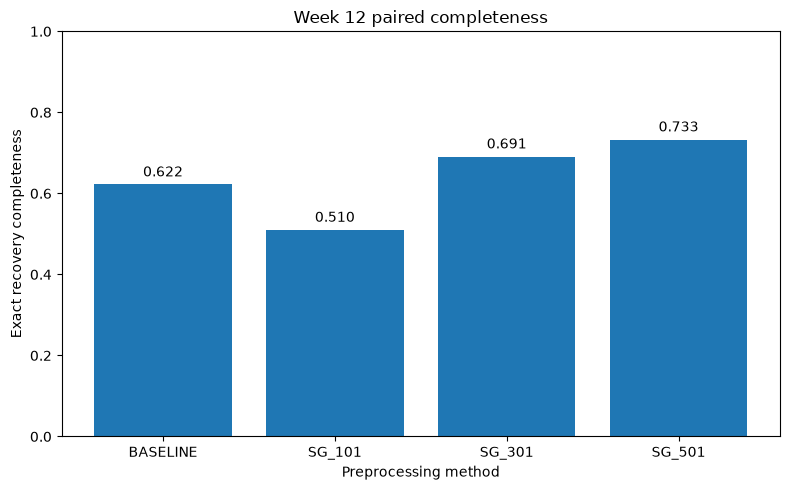

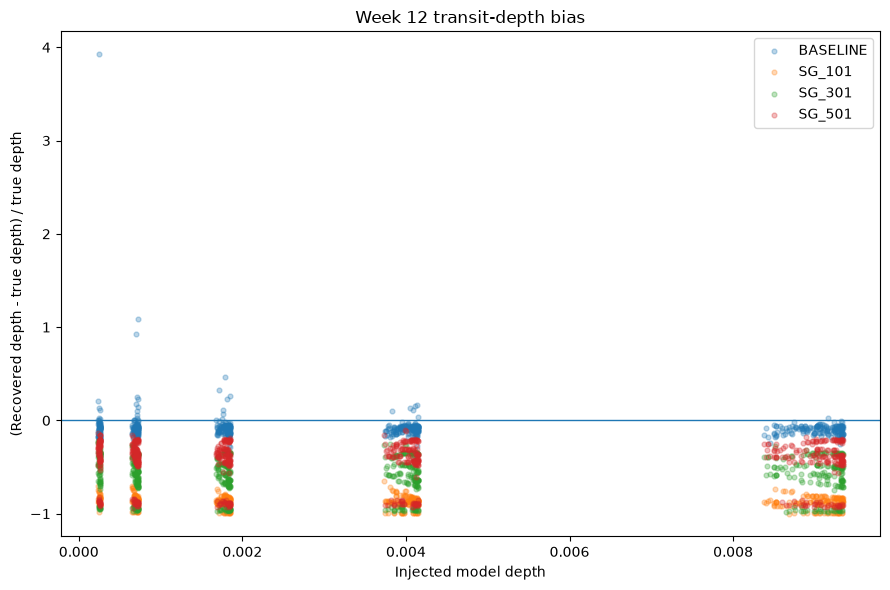

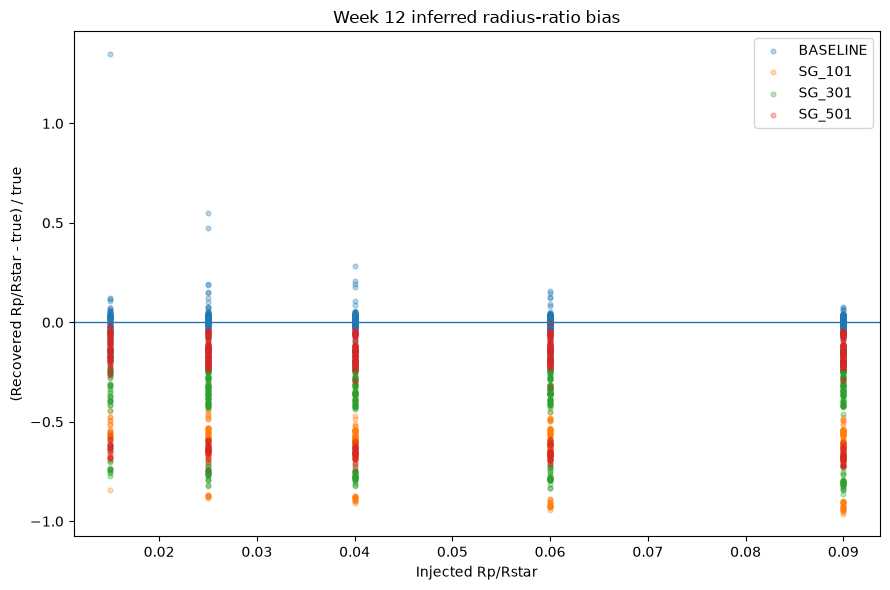


WEEK 12 PREPROCESSING-BIAS RESULTS

METHOD SUMMARY


,method,attempted,exact_recovered,exact_completeness,exact_ci95_low,exact_ci95_high,alias_aware_recovered,alias_aware_completeness,median_depth_fractional_error_exact,median_radius_fractional_error_exact,median_runtime_seconds
0,BASELINE,1000,622,0.622,0.591534,0.651532,634,0.634,-0.084080,0.010708,3.390042
1,SG_101,1000,510,0.510,0.479037,0.540886,516,0.516,-0.865378,-0.609969,2.602130
2,SG_301,1000,691,0.691,0.661675,0.718863,691,0.691,-0.564120,-0.308928,2.433825
3,SG_501,1000,733,0.733,0.704727,0.759490,735,0.735,-0.385444,-0.175715,2.389873



PAIRED RECOVERY SWITCHES


,method,baseline_miss_to_method_recovery,baseline_recovery_to_method_miss,both_recovered,both_missed,net_recovery_change
0,SG_101,44,156,466,334,-112
1,SG_301,128,59,563,250,69
2,SG_501,143,32,590,235,111



PAIRED DEPTH / RADIUS BIAS VS BASELINE


...


COMPLETENESS BY PERIOD


,method,true_period_days,attempted,exact_recovered,exact_completeness
0,BASELINE,1.0,250,170,0.680
1,BASELINE,3.0,250,162,0.648
2,BASELINE,6.0,250,158,0.632
3,BASELINE,10.0,250,132,0.528
4,SG_101,1.0,250,174,0.696
5,SG_101,3.0,250,139,0.556
6,SG_101,6.0,250,116,0.464
7,SG_101,10.0,250,81,0.324
8,SG_301,1.0,250,218,0.872
9,SG_301,3.0,250,177,0.708



COMPLETENESS BY HOST


,method,control_id,attempted,exact_recovered,exact_completeness,candidate_name,robust_rms,cadence_minutes
0,BASELINE,CONTROL-001,200,183,0.915,18 Sco,0.000194,0.333351
1,BASELINE,CONTROL-002,200,200,1.000,HD 102365,0.000101,1.999990
2,BASELINE,CONTROL-003,200,137,0.685,HD 76151,0.000239,1.999979
3,BASELINE,CONTROL-004,200,102,0.510,HD 30495,0.001261,2.000003
4,BASELINE,CONTROL-005,200,0,0.000,HD 20630,0.009572,2.000026
5,SG_101,CONTROL-001,200,63,0.315,18 Sco,0.000194,0.333351
6,SG_101,CONTROL-002,200,182,0.910,HD 102365,0.000101,1.999990
7,SG_101,CONTROL-003,200,128,0.640,HD 76151,0.000239,1.999979
8,SG_101,CONTROL-004,200,124,0.620,HD 30495,0.001261,2.000003
9,SG_101,CONTROL-005,200,13,0.065,HD 20630,0.009572,2.000026



✅ WEEK 12 COMPLETE
✅ 1000 IDENTICAL INJECTIONS
✅ 4 PREPROCESSING METHODS
✅ 4000 PAIRED METHOD/CASE ROWS
✅ COMPLETENESS MEASURED
✅ DEPTH BIAS MEASURED
✅ RADIUS-RATIO BIAS MEASURED
✅ NO-INJECTION CONTROLS COMPARED
✅ HELD-OUT HOSTS REMAIN UNTOUCHED
✅ W12_PREPROCESSING_V1 FROZEN


In [23]:
# ============================================================
# WEEK 12
# PAIRED PREPROCESSING-BIAS BENCHMARK
# CONSOLIDATED + COMPATIBILITY-SAFE VERSION
#
# Uses frozen Week 11:
#   - 1000 identical injections
#   - same hosts
#   - same seeds
#   - same BLS grids
#   - same RECOVERY_V2
#
# Methods:
#   BASELINE = frozen Week 11 results
#   SG_101
#   SG_301
#   SG_501
#
# Only 3000 NEW BLS searches are required.
# Held-out stars remain untouched.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from joblib import Parallel, delayed


# ============================================================
# 1. CHECK THAT WEEK 11 EXISTS
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",
    "development_host_data",
    "development_hosts_df",
    "heldout_hosts_df",
    "week11_design_df",
    "week11_results_df",
    "host_bls_grids",
    "inject_transit",
    "blind_bls_search",
    "evaluate_recovery_v2",
    "BLS_CONFIG",
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Week 11 state is missing.\n"
        f"Missing: {missing}\n\n"
        "Run the notebook through Week 11 first."
    )


assert len(week11_design_df) == 1000
assert len(week11_results_df) == 1000

assert (
    heldout_hosts_df["bls_run"] == False
).all()

assert (
    heldout_hosts_df["injection_run"] == False
).all()

assert (
    heldout_hosts_df["used_for_tuning"] == False
).all()


print("✅ Frozen Week 11 benchmark found.")
print("✅ 1000 Week 11 cases found.")
print("✅ Held-out firewall intact.")


# ============================================================
# 2. CPU SETTINGS
# ============================================================

CPU_COUNT_W12 = os.cpu_count() or 2

# Keep this moderate because CONTROL-001 is large.
N_JOBS_W12 = max(
    1,
    min(CPU_COUNT_W12 - 1, 4)
)

CHUNK_SIZE_W12 = max(
    8,
    N_JOBS_W12 * 2
)

print("CPU cores:", CPU_COUNT_W12)
print("Week 12 workers:", N_JOBS_W12)
print("Checkpoint chunk size:", CHUNK_SIZE_W12)


# ============================================================
# 3. OUTPUT DIRECTORIES
# ============================================================

W12_RESULTS_DIR = (
    RESULTS_DIR
    / "week12_preprocessing_bias"
)

W12_FIGURES_DIR = (
    FIGURES_DIR
    / "week12_preprocessing_bias"
)

W12_CONFIG_DIR = (
    CONFIG_DIR
    / "week12_preprocessing_bias"
)

for folder in [
    W12_RESULTS_DIR,
    W12_FIGURES_DIR,
    W12_CONFIG_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 4. FREEZE WEEK 12 PREPROCESSING METHODS
# ============================================================

PREPROCESSING_METHODS = {

    "BASELINE": {
        "kind": "none",
        "window": None,
        "polyorder": None,
    },

    "SG_101": {
        "kind": "savgol",
        "window": 101,
        "polyorder": 2,
    },

    "SG_301": {
        "kind": "savgol",
        "window": 301,
        "polyorder": 2,
    },

    "SG_501": {
        "kind": "savgol",
        "window": 501,
        "polyorder": 2,
    },
}


WEEK12_PROTOCOL = {

    "version":
        "W12_PREPROCESSING_V1",

    "source_benchmark":
        "W11_COMPLETENESS_V1",

    "unique_injections":
        1000,

    "methods":
        PREPROCESSING_METHODS,

    "paired_design":
        True,

    "same_injections_across_methods":
        True,

    "recovery_protocol":
        "RECOVERY_V2",

    "primary_recovery":
        "EXACT period within 1%",

    "heldout_hosts_used":
        False,

    "depth_metric":
        "BLS recovered box depth",

    "radius_ratio_estimator":
        "sqrt(BLS depth)",

    "control_analysis":
        (
            "Continuous BLS candidate statistics only; "
            "no post-hoc binary SDE threshold."
        ),
}


with open(
    W12_CONFIG_DIR
    / "W12_PREPROCESSING_V1.json",
    "w",
) as f:

    json.dump(
        WEEK12_PROTOCOL,
        f,
        indent=2,
    )


print("✅ Week 12 protocol frozen.")


# ============================================================
# 5. PREPROCESSING FUNCTION
# ============================================================

def apply_week12_preprocessing(
    time_values,
    flux_values,
    method_name,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )

    f = np.asarray(
        flux_values,
        dtype=float,
    )


    if method_name == "BASELINE":

        good = (
            np.isfinite(t)
            &
            np.isfinite(f)
        )

        return (
            t[good],
            f[good],
        )


    if method_name not in PREPROCESSING_METHODS:

        raise ValueError(
            f"Unknown preprocessing method: {method_name}"
        )


    settings = PREPROCESSING_METHODS[
        method_name
    ]


    window = int(
        settings["window"]
    )

    polyorder = int(
        settings["polyorder"]
    )


    # ---------------------------------------------
    # Make sure the window is legal
    # ---------------------------------------------

    window = min(
        window,
        len(f) - 1,
    )


    if window % 2 == 0:
        window -= 1


    minimum_window = (
        polyorder + 3
    )


    if minimum_window % 2 == 0:
        minimum_window += 1


    window = max(
        window,
        minimum_window,
    )


    if window >= len(f):

        window = len(f) - 1

        if window % 2 == 0:
            window -= 1


    if window <= polyorder:

        raise ValueError(
            "Savitzky-Golay window is too small."
        )


    trend = savgol_filter(
        f,
        window_length=window,
        polyorder=polyorder,
    )


    good_trend = (
        np.isfinite(trend)
        &
        (trend != 0)
    )


    detrended = np.full(
        len(f),
        np.nan,
        dtype=float,
    )


    detrended[good_trend] = (
        f[good_trend]
        /
        trend[good_trend]
    )


    good = (
        np.isfinite(t)
        &
        np.isfinite(detrended)
    )


    return (
        t[good],
        detrended[good],
    )


print("✅ Preprocessing function ready.")


# ============================================================
# 6. DEPTH -> RADIUS RATIO
# ============================================================

def depth_to_rprs(depth):

    try:
        depth = float(depth)

    except Exception:
        return np.nan


    if (
        not np.isfinite(depth)
        or depth <= 0
    ):
        return np.nan


    return float(
        np.sqrt(depth)
    )


# ============================================================
# 7. COMPATIBILITY-SAFE INJECTION CALL
#
# IMPORTANT FIX:
#
# We deliberately call inject_transit() POSITIONALLY.
#
# This works whether your notebook defines it as:
#
#   period_days / rp_over_rstar / ...
#
# or:
#
#   period / rprs / ...
#
# because the argument ORDER is the same.
# ============================================================

def call_inject_transit_compat(
    host,
    period_days,
    true_epoch,
    rp_rs,
    impact_parameter,
):

    return inject_transit(

        host["time"],
        host["flux"],

        float(period_days),
        float(true_epoch),
        float(rp_rs),

        float(
            host[
                "stellar_mass_msun"
            ]
        ),

        float(
            host[
                "stellar_radius_rsun"
            ]
        ),

        float(
            impact_parameter
        ),

        7,
    )


# ============================================================
# 8. REGENERATE EXACT WEEK 11 INJECTION
# ============================================================

def regenerate_week11_injection(case):

    control_id = str(
        case["control_id"]
    )

    period_days = float(
        case["true_period_days"]
    )

    rp_rs = float(
        case["rp_over_rstar"]
    )

    seed = int(
        case["seed"]
    )


    host = development_host_data[
        control_id
    ]


    rng = np.random.default_rng(
        seed
    )


    # Same RNG order as frozen Week 11.
    impact_parameter = float(
        rng.uniform(
            0.0,
            0.7,
        )
    )


    true_epoch = float(
        host["time"].min()
        +
        rng.uniform(
            0.0,
            period_days,
        )
    )


    injected_flux, truth = (
        call_inject_transit_compat(

            host=host,

            period_days=period_days,

            true_epoch=true_epoch,

            rp_rs=rp_rs,

            impact_parameter=impact_parameter,
        )
    )


    return {

        "time":
            np.asarray(
                host["time"],
                dtype=float,
            ),

        "flux":
            np.asarray(
                injected_flux,
                dtype=float,
            ),

        "truth":
            {
                **truth,

                "case_id":
                    str(
                        case["case_id"]
                    ),

                "control_id":
                    control_id,

                "seed":
                    seed,

                # Add canonical Week 12 names even if
                # the original injection function used
                # different dictionary keys.
                "true_period_days":
                    period_days,

                "true_rp_over_rstar":
                    rp_rs,

                "true_epoch_btjd":
                    true_epoch,

                "impact_parameter":
                    impact_parameter,
            },
    }


# ============================================================
# 9. VERIFY THAT WE REGENERATE WEEK 11 EXACTLY
# ============================================================

verification_rows = []


verification_indices = [
    0,
    199,
    399,
    599,
    799,
    999,
]


for check_index in verification_indices:

    case = (
        week11_design_df
        .iloc[
            check_index
        ]
        .to_dict()
    )


    regenerated = (
        regenerate_week11_injection(
            case
        )
    )


    original_match = (
        week11_results_df[
            week11_results_df[
                "case_id"
            ].astype(str)
            ==
            str(
                case["case_id"]
            )
        ]
    )


    if len(original_match) != 1:

        raise RuntimeError(
            f"Could not uniquely find "
            f"{case['case_id']} "
            f"in Week 11 results."
        )


    original = (
        original_match
        .iloc[0]
    )


    truth = regenerated[
        "truth"
    ]


    regenerated_epoch = (
        truth.get(
            "t0",
            truth.get(
                "true_epoch_btjd",
                np.nan,
            ),
        )
    )


    regenerated_b = (
        truth.get(
            "impact_parameter",
            truth.get(
                "impact_b",
                np.nan,
            ),
        )
    )


    regenerated_depth = (
        truth.get(
            "model_depth",
            np.nan,
        )
    )


    verification_rows.append({

        "case_id":
            case["case_id"],

        "epoch_original":
            original.get(
                "true_epoch_btjd",
                np.nan,
            ),

        "epoch_regenerated":
            regenerated_epoch,

        "b_original":
            original.get(
                "impact_parameter",
                np.nan,
            ),

        "b_regenerated":
            regenerated_b,

        "depth_original":
            original.get(
                "model_depth",
                np.nan,
            ),

        "depth_regenerated":
            regenerated_depth,
    })


verification_df = pd.DataFrame(
    verification_rows
)


print("\nPAIRING SANITY CHECK")

display(
    verification_df
)


# ---------------------------------------------
# Compare values where frozen table contains them
# ---------------------------------------------

for _, row in verification_df.iterrows():

    if (
        np.isfinite(
            row["epoch_original"]
        )
        and
        np.isfinite(
            row["epoch_regenerated"]
        )
    ):

        assert np.isclose(
            row["epoch_original"],
            row["epoch_regenerated"],
            rtol=0,
            atol=1e-8,
        )


    if (
        np.isfinite(
            row["b_original"]
        )
        and
        np.isfinite(
            row["b_regenerated"]
        )
    ):

        assert np.isclose(
            row["b_original"],
            row["b_regenerated"],
            rtol=0,
            atol=1e-8,
        )


    if (
        np.isfinite(
            row["depth_original"]
        )
        and
        np.isfinite(
            row["depth_regenerated"]
        )
    ):

        assert np.isclose(
            row["depth_original"],
            row["depth_regenerated"],
            rtol=1e-8,
            atol=1e-10,
        )


print("✅ Week 11 injections reproduce correctly.")


# ============================================================
# 10. IMPORT FROZEN WEEK 11 AS BASELINE
#
# No need to waste another 1000 BLS runs.
# ============================================================

baseline_rows = []


for _, row in week11_results_df.iterrows():

    found_depth = row.get(
        "found_depth",
        np.nan,
    )


    true_depth = row.get(
        "model_depth",
        np.nan,
    )


    true_rprs = float(
        row[
            "rp_over_rstar"
        ]
    )


    recovered_rprs = (
        depth_to_rprs(
            found_depth
        )
    )


    if (
        np.isfinite(found_depth)
        and
        np.isfinite(true_depth)
        and
        true_depth > 0
    ):

        depth_fractional_error = (

            (
                found_depth
                -
                true_depth
            )

            /

            true_depth
        )

    else:

        depth_fractional_error = np.nan


    if (
        np.isfinite(recovered_rprs)
        and
        true_rprs > 0
    ):

        radius_fractional_error = (

            (
                recovered_rprs
                -
                true_rprs
            )

            /

            true_rprs
        )

    else:

        radius_fractional_error = np.nan


    baseline_rows.append({

        "case_id":
            str(
                row["case_id"]
            ),

        "method":
            "BASELINE",

        "control_id":
            str(
                row["control_id"]
            ),

        "seed":
            int(
                row["seed"]
            ),

        "true_period_days":
            float(
                row[
                    "true_period_days"
                ]
            ),

        "true_rp_over_rstar":
            true_rprs,

        "true_model_depth":
            true_depth,

        "true_epoch_btjd":
            row.get(
                "true_epoch_btjd",
                np.nan,
            ),

        "impact_parameter":
            row.get(
                "impact_parameter",
                np.nan,
            ),

        "found_period_days":
            row.get(
                "found_period_days",
                np.nan,
            ),

        "found_duration_days":
            row.get(
                "found_duration_days",
                np.nan,
            ),

        "found_duration_hours":
            row.get(
                "found_duration_hours",
                (
                    row.get(
                        "found_duration_days",
                        np.nan,
                    )
                    * 24
                    if np.isfinite(
                        row.get(
                            "found_duration_days",
                            np.nan,
                        )
                    )
                    else np.nan
                ),
            ),

        "found_depth":
            found_depth,

        "recovered_rp_over_rstar":
            recovered_rprs,

        "depth_fractional_error":
            depth_fractional_error,

        "radius_fractional_error":
            radius_fractional_error,

        "bls_power":
            row.get(
                "bls_power",
                np.nan,
            ),

        "detection_sde":
            row.get(
                "detection_sde",
                np.nan,
            ),

        "recovery_category":
            row.get(
                "recovery_category",
                row.get(
                    "category",
                    np.nan,
                ),
            ),

        "primary_recovered":
            bool(
                row[
                    "primary_recovered"
                ]
            ),

        "alias_aware_recovered":
            bool(
                row[
                    "alias_aware_recovered"
                ]
            ),

        "runtime_seconds":
            row.get(
                "runtime_seconds_total",
                row.get(
                    "runtime_seconds",
                    np.nan,
                ),
            ),

        "status":
            row.get(
                "status",
                "SUCCESS",
            ),
    })


baseline_week12_df = pd.DataFrame(
    baseline_rows
)


assert len(
    baseline_week12_df
) == 1000


print(
    "✅ Frozen Week 11 baseline imported."
)


# ============================================================
# 11. SINGLE WEEK 12 WORKER
# ============================================================

def run_week12_case(
    case,
    method_name,
):

    start = time.perf_counter()


    case_id = str(
        case["case_id"]
    )

    control_id = str(
        case["control_id"]
    )

    true_period = float(
        case["true_period_days"]
    )

    true_rprs = float(
        case["rp_over_rstar"]
    )

    seed = int(
        case["seed"]
    )


    try:

        # ---------------------------------------------
        # Identical Week 11 injection
        # ---------------------------------------------

        injected = (
            regenerate_week11_injection(
                case
            )
        )


        truth = injected[
            "truth"
        ]


        true_epoch = truth.get(

            "t0",

            truth.get(
                "true_epoch_btjd",
                np.nan,
            ),
        )


        impact_parameter = truth.get(

            "impact_parameter",

            truth.get(
                "impact_b",
                np.nan,
            ),
        )


        true_depth = truth.get(
            "model_depth",
            np.nan,
        )


        # ---------------------------------------------
        # Preprocessing
        # ---------------------------------------------

        processed_time, processed_flux = (
            apply_week12_preprocessing(

                injected[
                    "time"
                ],

                injected[
                    "flux"
                ],

                method_name,
            )
        )


        # ---------------------------------------------
        # Same frozen blind BLS
        # ---------------------------------------------

        candidate = blind_bls_search(

            processed_time,

            processed_flux,

            period_grid=host_bls_grids[
                control_id
            ],

            config=BLS_CONFIG,
        )


        # ---------------------------------------------
        # Evaluate only after BLS result exists
        # ---------------------------------------------

        evaluation = evaluate_recovery_v2(

            true_period=true_period,

            found_period=candidate[
                "found_period_days"
            ],
        )


        found_depth = candidate.get(
            "found_depth",
            np.nan,
        )


        recovered_rprs = (
            depth_to_rprs(
                found_depth
            )
        )


        if (
            np.isfinite(found_depth)
            and
            np.isfinite(true_depth)
            and
            true_depth > 0
        ):

            depth_fractional_error = (

                (
                    found_depth
                    -
                    true_depth
                )

                /

                true_depth
            )

        else:

            depth_fractional_error = np.nan


        if (
            np.isfinite(recovered_rprs)
            and
            true_rprs > 0
        ):

            radius_fractional_error = (

                (
                    recovered_rprs
                    -
                    true_rprs
                )

                /

                true_rprs
            )

        else:

            radius_fractional_error = np.nan


        found_duration_days = candidate.get(
            "found_duration_days",
            np.nan,
        )


        return {

            "case_id":
                case_id,

            "method":
                method_name,

            "control_id":
                control_id,

            "seed":
                seed,

            "true_period_days":
                true_period,

            "true_rp_over_rstar":
                true_rprs,

            "true_model_depth":
                true_depth,

            "true_epoch_btjd":
                true_epoch,

            "impact_parameter":
                impact_parameter,

            "found_period_days":
                candidate.get(
                    "found_period_days",
                    np.nan,
                ),

            "found_duration_days":
                found_duration_days,

            "found_duration_hours":
                (
                    found_duration_days * 24
                    if np.isfinite(
                        found_duration_days
                    )
                    else candidate.get(
                        "found_duration_hours",
                        np.nan,
                    )
                ),

            "found_depth":
                found_depth,

            "recovered_rp_over_rstar":
                recovered_rprs,

            "depth_fractional_error":
                depth_fractional_error,

            "radius_fractional_error":
                radius_fractional_error,

            "bls_power":
                candidate.get(
                    "bls_power",
                    np.nan,
                ),

            "detection_sde":
                candidate.get(
                    "detection_sde",
                    np.nan,
                ),

            "recovery_category":
                evaluation[
                    "category"
                ],

            "primary_recovered":
                evaluation[
                    "primary_recovered"
                ],

            "alias_aware_recovered":
                evaluation[
                    "alias_aware_recovered"
                ],

            "runtime_seconds":
                (
                    time.perf_counter()
                    -
                    start
                ),

            "status":
                "SUCCESS",
        }


    except Exception as error:

        return {

            "case_id":
                case_id,

            "method":
                method_name,

            "control_id":
                control_id,

            "seed":
                seed,

            "true_period_days":
                true_period,

            "true_rp_over_rstar":
                true_rprs,

            "recovery_category":
                "FAILED",

            "primary_recovered":
                False,

            "alias_aware_recovered":
                False,

            "runtime_seconds":
                (
                    time.perf_counter()
                    -
                    start
                ),

            "status":
                "FAILED",

            "error":
                repr(
                    error
                ),
        }


# ============================================================
# 12. CREATE THE 3000 NEW SEARCHES
# ============================================================

NEW_METHODS = [
    "SG_101",
    "SG_301",
    "SG_501",
]


week12_design_rows = []


for _, case in week11_design_df.iterrows():

    for method_name in NEW_METHODS:

        week12_design_rows.append({

            "experiment_id":
                (
                    f"{case['case_id']}"
                    f"__{method_name}"
                ),

            "case_id":
                str(
                    case["case_id"]
                ),

            "method":
                method_name,

            "control_id":
                str(
                    case["control_id"]
                ),

            "true_period_days":
                float(
                    case[
                        "true_period_days"
                    ]
                ),

            "rp_over_rstar":
                float(
                    case[
                        "rp_over_rstar"
                    ]
                ),

            "seed":
                int(
                    case["seed"]
                ),
        })


week12_design_df = pd.DataFrame(
    week12_design_rows
)


assert len(
    week12_design_df
) == 3000


assert (
    week12_design_df[
        "experiment_id"
    ].nunique()
    == 3000
)


week12_design_df.to_csv(

    W12_RESULTS_DIR
    / "W12_search_design.csv",

    index=False,
)


print(
    "✅ Week 12 design:",
    len(
        week12_design_df
    ),
    "new searches"
)


# ============================================================
# 13. CHECKPOINT / RESUME
# ============================================================

W12_CHECKPOINT_PATH = (

    W12_RESULTS_DIR
    /
    "W12_detrending_checkpoint.csv"
)


W12_NEW_RESULTS_PATH = (

    W12_RESULTS_DIR
    /
    "W12_new_detrending_results.csv"
)


if W12_CHECKPOINT_PATH.exists():

    existing_w12 = (

        pd.read_csv(
            W12_CHECKPOINT_PATH
        )

        .drop_duplicates(
            [
                "case_id",
                "method",
            ],

            keep="last",
        )
    )

else:

    existing_w12 = pd.DataFrame()


if len(
    existing_w12
):

    completed_pairs = set(

        zip(

            existing_w12[
                "case_id"
            ].astype(str),

            existing_w12[
                "method"
            ].astype(str),
        )
    )

else:

    completed_pairs = set()


pending_rows = []


for _, row in week12_design_df.iterrows():

    key = (

        str(
            row["case_id"]
        ),

        str(
            row["method"]
        ),
    )


    if key not in completed_pairs:

        pending_rows.append(
            row.to_dict()
        )


pending_w12_df = pd.DataFrame(
    pending_rows
)


print(
    "Already completed:",
    len(
        existing_w12
    ),
)


print(
    "Still pending:",
    len(
        pending_w12_df
    ),
)


# ============================================================
# 14. RUN / RESUME THE 3000 NEW SEARCHES
# ============================================================

current_w12 = (
    existing_w12.copy()
)


session_start = time.perf_counter()


for start_index in range(
    0,
    len(
        pending_w12_df
    ),
    CHUNK_SIZE_W12,
):

    chunk = pending_w12_df.iloc[

        start_index:
        start_index
        +
        CHUNK_SIZE_W12
    ]


    jobs = []


    for record in chunk.to_dict(
        "records"
    ):

        case = {

            "case_id":
                record[
                    "case_id"
                ],

            "control_id":
                record[
                    "control_id"
                ],

            "true_period_days":
                record[
                    "true_period_days"
                ],

            "rp_over_rstar":
                record[
                    "rp_over_rstar"
                ],

            "seed":
                record[
                    "seed"
                ],
        }


        jobs.append(
            (
                case,
                record[
                    "method"
                ],
            )
        )


    chunk_results = Parallel(

        n_jobs=N_JOBS_W12,

        backend="loky",

        verbose=0,

    )(

        delayed(
            run_week12_case
        )(
            case,
            method_name,
        )

        for (
            case,
            method_name
        )
        in jobs
    )


    current_w12 = pd.concat(

        [
            current_w12,
            pd.DataFrame(
                chunk_results
            ),
        ],

        ignore_index=True,
    )


    current_w12 = (

        current_w12

        .drop_duplicates(

            [
                "case_id",
                "method",
            ],

            keep="last",
        )
    )


    # ---------------------------------------------
    # Atomic-ish checkpoint
    # ---------------------------------------------

    temp_path = (
        W12_CHECKPOINT_PATH
        .with_suffix(
            ".tmp.csv"
        )
    )


    current_w12.to_csv(
        temp_path,
        index=False,
    )


    temp_path.replace(
        W12_CHECKPOINT_PATH
    )


    elapsed_minutes = (

        time.perf_counter()
        -
        session_start

    ) / 60


    print(

        f"Checkpoint: "
        f"{len(current_w12)}/3000 "
        f"| elapsed this session: "
        f"{elapsed_minutes:.1f} min"
    )


current_w12 = (

    current_w12

    .sort_values(
        [
            "case_id",
            "method",
        ]
    )

    .reset_index(
        drop=True
    )
)


current_w12.to_csv(

    W12_NEW_RESULTS_PATH,

    index=False,
)


assert len(
    current_w12
) == 3000


failed_searches = int(

    (
        current_w12[
            "status"
        ]
        !=
        "SUCCESS"
    ).sum()
)


print()
print("New searches:", len(current_w12))
print("Failures:", failed_searches)
print("✅ New preprocessing searches finished.")


# ============================================================
# 15. COMBINE BASELINE + THREE NEW METHODS
# ============================================================

week12_results_df = pd.concat(

    [
        baseline_week12_df,
        current_w12,
    ],

    ignore_index=True,
)


week12_results_df = (

    week12_results_df

    .sort_values(
        [
            "case_id",
            "method",
        ]
    )

    .reset_index(
        drop=True
    )
)


assert len(
    week12_results_df
) == 4000


pair_counts = (

    week12_results_df

    .groupby(
        "case_id"
    )[
        "method"
    ]

    .nunique()
)


assert (
    pair_counts == 4
).all()


W12_MASTER_RESULTS_PATH = (

    W12_RESULTS_DIR
    /
    "DET_detrending_results.csv"
)


week12_results_df.to_csv(

    W12_MASTER_RESULTS_PATH,

    index=False,
)


print(
    "✅ Perfect pairing confirmed:"
)

print(
    "1000 cases × 4 methods =",
    len(
        week12_results_df
    )
)


# ============================================================
# 16. NO-INJECTION CONTROL COMPARISON
# ============================================================

control_rows = []


for (
    control_id,
    host
) in development_host_data.items():

    for method_name in (
        PREPROCESSING_METHODS.keys()
    ):

        try:

            control_time, control_flux = (
                apply_week12_preprocessing(

                    host[
                        "time"
                    ],

                    host[
                        "flux"
                    ],

                    method_name,
                )
            )


            start = (
                time.perf_counter()
            )


            candidate = blind_bls_search(

                control_time,

                control_flux,

                period_grid=host_bls_grids[
                    control_id
                ],

                config=BLS_CONFIG,
            )


            control_rows.append({

                "control_id":
                    control_id,

                "candidate_name":
                    host.get(
                        "candidate_name",
                        control_id,
                    ),

                "method":
                    method_name,

                "found_period_days":
                    candidate.get(
                        "found_period_days",
                        np.nan,
                    ),

                "found_depth":
                    candidate.get(
                        "found_depth",
                        np.nan,
                    ),

                "detection_sde":
                    candidate.get(
                        "detection_sde",
                        np.nan,
                    ),

                "bls_power":
                    candidate.get(
                        "bls_power",
                        np.nan,
                    ),

                "runtime_seconds":
                    (
                        time.perf_counter()
                        -
                        start
                    ),

                "status":
                    "SUCCESS",
            })


        except Exception as error:

            control_rows.append({

                "control_id":
                    control_id,

                "candidate_name":
                    host.get(
                        "candidate_name",
                        control_id,
                    ),

                "method":
                    method_name,

                "status":
                    "FAILED",

                "error":
                    repr(
                        error
                    ),
            })


week12_controls_df = pd.DataFrame(
    control_rows
)


W12_CONTROL_PATH = (

    W12_RESULTS_DIR
    /
    "W12_no_injection_controls.csv"
)


week12_controls_df.to_csv(
    W12_CONTROL_PATH,
    index=False,
)


print(
    "\n✅ No-injection controls complete."
)


# ============================================================
# 17. WILSON INTERVAL FALLBACK
# ============================================================

if "wilson_interval" not in globals():

    def wilson_interval(
        successes,
        attempts,
        z=1.959963984540054,
    ):

        if attempts <= 0:
            return (
                np.nan,
                np.nan,
            )


        p = successes / attempts


        denominator = (
            1
            +
            z**2
            /
            attempts
        )


        center = (

            p

            +

            z**2
            /
            (
                2
                *
                attempts
            )

        ) / denominator


        half_width = (

            z

            *

            np.sqrt(

                p
                *
                (
                    1
                    -
                    p
                )
                /
                attempts

                +

                z**2
                /
                (
                    4
                    *
                    attempts**2
                )
            )

            /

            denominator
        )


        return (

            max(
                0,
                center
                -
                half_width,
            ),

            min(
                1,
                center
                +
                half_width,
            ),
        )


# ============================================================
# 18. METHOD SUMMARY
# ============================================================

method_summary_rows = []


for (
    method_name,
    group
) in week12_results_df.groupby(
    "method"
):

    attempted = len(
        group
    )


    exact_count = int(
        group[
            "primary_recovered"
        ].sum()
    )


    alias_count = int(
        group[
            "alias_aware_recovered"
        ].sum()
    )


    exact_low, exact_high = (
        wilson_interval(
            exact_count,
            attempted,
        )
    )


    exact_group = group[
        group[
            "primary_recovered"
        ]
        ==
        True
    ]


    method_summary_rows.append({

        "method":
            method_name,

        "attempted":
            attempted,

        "exact_recovered":
            exact_count,

        "exact_completeness":
            exact_count
            /
            attempted,

        "exact_ci95_low":
            exact_low,

        "exact_ci95_high":
            exact_high,

        "alias_aware_recovered":
            alias_count,

        "alias_aware_completeness":
            alias_count
            /
            attempted,

        "median_depth_fractional_error_exact":
            exact_group[
                "depth_fractional_error"
            ].median(),

        "median_radius_fractional_error_exact":
            exact_group[
                "radius_fractional_error"
            ].median(),

        "median_runtime_seconds":
            group[
                "runtime_seconds"
            ].median(),
    })


method_summary_df = pd.DataFrame(
    method_summary_rows
)


METHOD_ORDER = [
    "BASELINE",
    "SG_101",
    "SG_301",
    "SG_501",
]


method_summary_df[
    "_order"
] = (
    method_summary_df[
        "method"
    ].map(
        {
            method: index
            for index, method
            in enumerate(
                METHOD_ORDER
            )
        }
    )
)


method_summary_df = (

    method_summary_df

    .sort_values(
        "_order"
    )

    .drop(
        columns="_order"
    )

    .reset_index(
        drop=True
    )
)


method_summary_df.to_csv(

    W12_RESULTS_DIR
    / "W12_method_summary.csv",

    index=False,
)


# ============================================================
# 19. PAIRED RECOVERY SWITCHES
# ============================================================

baseline_status = (

    week12_results_df[

        week12_results_df[
            "method"
        ]
        ==
        "BASELINE"

    ][
        [
            "case_id",
            "primary_recovered",
        ]
    ]

    .rename(
        columns={
            "primary_recovered":
                "baseline_recovered"
        }
    )
)


switch_rows = []


for method_name in [
    "SG_101",
    "SG_301",
    "SG_501",
]:

    method_status = (

        week12_results_df[

            week12_results_df[
                "method"
            ]
            ==
            method_name

        ][
            [
                "case_id",
                "primary_recovered",
            ]
        ]

        .rename(
            columns={
                "primary_recovered":
                    "method_recovered"
            }
        )
    )


    paired = (
        baseline_status
        .merge(
            method_status,
            on="case_id",
            how="inner",
        )
    )


    gained = int(
        (
            (~paired[
                "baseline_recovered"
            ])
            &
            (
                paired[
                    "method_recovered"
                ]
            )
        ).sum()
    )


    lost = int(
        (
            (
                paired[
                    "baseline_recovered"
                ]
            )
            &
            (~paired[
                "method_recovered"
            ])
        ).sum()
    )


    both_recovered = int(
        (
            (
                paired[
                    "baseline_recovered"
                ]
            )
            &
            (
                paired[
                    "method_recovered"
                ]
            )
        ).sum()
    )


    both_missed = int(
        (
            (~paired[
                "baseline_recovered"
            ])
            &
            (~paired[
                "method_recovered"
            ])
        ).sum()
    )


    switch_rows.append({

        "method":
            method_name,

        "baseline_miss_to_method_recovery":
            gained,

        "baseline_recovery_to_method_miss":
            lost,

        "both_recovered":
            both_recovered,

        "both_missed":
            both_missed,

        "net_recovery_change":
            gained
            -
            lost,
    })


switch_summary_df = pd.DataFrame(
    switch_rows
)


switch_summary_df.to_csv(

    W12_RESULTS_DIR
    / "W12_recovery_switches.csv",

    index=False,
)


# ============================================================
# 20. PAIRED DEPTH / RADIUS BIAS VS BASELINE
#
# Only compare cases recovered EXACTLY by both methods.
# ============================================================

baseline_exact = (

    week12_results_df[

        (
            week12_results_df[
                "method"
            ]
            ==
            "BASELINE"
        )

        &

        (
            week12_results_df[
                "primary_recovered"
            ]
            ==
            True
        )

    ][
        [
            "case_id",
            "depth_fractional_error",
            "radius_fractional_error",
        ]
    ]

    .rename(
        columns={

            "depth_fractional_error":
                "baseline_depth_error",

            "radius_fractional_error":
                "baseline_radius_error",
        }
    )
)


paired_bias_rows = []


for method_name in [
    "SG_101",
    "SG_301",
    "SG_501",
]:

    method_exact = (

        week12_results_df[

            (
                week12_results_df[
                    "method"
                ]
                ==
                method_name
            )

            &

            (
                week12_results_df[
                    "primary_recovered"
                ]
                ==
                True
            )

        ][
            [
                "case_id",
                "depth_fractional_error",
                "radius_fractional_error",
            ]
        ]

        .rename(
            columns={

                "depth_fractional_error":
                    "method_depth_error",

                "radius_fractional_error":
                    "method_radius_error",
            }
        )
    )


    paired = baseline_exact.merge(

        method_exact,

        on="case_id",

        how="inner",
    )


    paired[
        "delta_depth_error_vs_baseline"
    ] = (

        paired[
            "method_depth_error"
        ]

        -

        paired[
            "baseline_depth_error"
        ]
    )


    paired[
        "delta_radius_error_vs_baseline"
    ] = (

        paired[
            "method_radius_error"
        ]

        -

        paired[
            "baseline_radius_error"
        ]
    )


    paired_bias_rows.append({

        "method":
            method_name,

        "n_common_exact_recoveries":
            len(
                paired
            ),

        "median_delta_depth_error_vs_baseline":
            paired[
                "delta_depth_error_vs_baseline"
            ].median(),

        "median_delta_radius_error_vs_baseline":
            paired[
                "delta_radius_error_vs_baseline"
            ].median(),

        "fraction_more_depth_suppression_than_baseline":
            (
                paired[
                    "delta_depth_error_vs_baseline"
                ]
                <
                0
            ).mean(),

        "fraction_more_radius_suppression_than_baseline":
            (
                paired[
                    "delta_radius_error_vs_baseline"
                ]
                <
                0
            ).mean(),
    })


paired_method_summary_df = (
    pd.DataFrame(
        paired_bias_rows
    )
)


paired_method_summary_df.to_csv(

    W12_RESULTS_DIR
    / "W12_paired_bias_vs_baseline.csv",

    index=False,
)


# ============================================================
# 21. CONTROL SUMMARY
#
# We deliberately DO NOT invent a new SDE threshold.
# ============================================================

control_summary = (

    week12_controls_df

    .groupby(
        "method"
    )

    .agg(

        n_controls=(
            "control_id",
            "count",
        ),

        median_control_sde=(
            "detection_sde",
            "median",
        ),

        max_control_sde=(
            "detection_sde",
            "max",
        ),

        median_control_depth=(
            "found_depth",
            "median",
        ),

        max_control_depth=(
            "found_depth",
            "max",
        ),
    )

    .reset_index()
)


control_summary[
    "_order"
] = (
    control_summary[
        "method"
    ].map(
        {
            method: index
            for index, method
            in enumerate(
                METHOD_ORDER
            )
        }
    )
)


control_summary = (

    control_summary

    .sort_values(
        "_order"
    )

    .drop(
        columns="_order"
    )

    .reset_index(
        drop=True
    )
)


control_summary.to_csv(

    W12_RESULTS_DIR
    / "W12_control_summary.csv",

    index=False,
)


# ============================================================
# 22. COMPLETENESS BY PLANET SIZE
# ============================================================

size_method_summary = (

    week12_results_df

    .groupby(
        [
            "method",
            "true_rp_over_rstar",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


size_method_summary.to_csv(

    W12_RESULTS_DIR
    / "W12_completeness_by_size.csv",

    index=False,
)


# ============================================================
# 23. COMPLETENESS BY PERIOD
# ============================================================

period_method_summary = (

    week12_results_df

    .groupby(
        [
            "method",
            "true_period_days",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


period_method_summary.to_csv(

    W12_RESULTS_DIR
    / "W12_completeness_by_period.csv",

    index=False,
)


# ============================================================
# 24. COMPLETENESS BY HOST
# ============================================================

host_method_summary = (

    week12_results_df

    .groupby(
        [
            "method",
            "control_id",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


if "development_hosts_df" in globals():

    merge_columns = [
        column
        for column in [
            "control_id",
            "candidate_name",
            "robust_rms",
            "cadence_minutes",
        ]
        if column in development_hosts_df.columns
    ]


    if "control_id" in merge_columns:

        host_method_summary = (
            host_method_summary
            .merge(
                development_hosts_df[
                    merge_columns
                ],
                on="control_id",
                how="left",
            )
        )


host_method_summary.to_csv(

    W12_RESULTS_DIR
    / "W12_completeness_by_host.csv",

    index=False,
)


# ============================================================
# 25. FIGURE 1 — COMPLETENESS
# ============================================================

plot_summary = (

    method_summary_df

    .set_index(
        "method"
    )

    .loc[
        METHOD_ORDER
    ]

    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)


bars = ax.bar(

    plot_summary[
        "method"
    ],

    plot_summary[
        "exact_completeness"
    ],
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_xlabel(
    "Preprocessing method"
)


ax.set_title(
    "Week 12 paired completeness"
)


for index, row in (
    plot_summary.iterrows()
):

    ax.text(

        index,

        row[
            "exact_completeness"
        ]
        +
        0.02,

        f"{row['exact_completeness']:.3f}",

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W12_FIGURES_DIR
    / "detrending_completeness.png",

    dpi=220,
)


plt.show()


# ============================================================
# 26. FIGURE 2 — DEPTH BIAS
# ============================================================

exact_recoveries_df = (

    week12_results_df[

        week12_results_df[
            "primary_recovered"
        ]
        ==
        True

    ]

    .copy()
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


for method_name in METHOD_ORDER:

    subset = exact_recoveries_df[

        exact_recoveries_df[
            "method"
        ]
        ==
        method_name
    ]


    ax.scatter(

        subset[
            "true_model_depth"
        ],

        subset[
            "depth_fractional_error"
        ],

        s=12,

        alpha=0.30,

        label=method_name,
    )


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xlabel(
    "Injected model depth"
)


ax.set_ylabel(
    "(Recovered depth - true depth) / true depth"
)


ax.set_title(
    "Week 12 transit-depth bias"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W12_FIGURES_DIR
    / "depth_bias.png",

    dpi=220,
)


plt.show()


# ============================================================
# 27. FIGURE 3 — RADIUS-RATIO BIAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for method_name in METHOD_ORDER:

    subset = exact_recoveries_df[

        exact_recoveries_df[
            "method"
        ]
        ==
        method_name
    ]


    ax.scatter(

        subset[
            "true_rp_over_rstar"
        ],

        subset[
            "radius_fractional_error"
        ],

        s=12,

        alpha=0.30,

        label=method_name,
    )


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xlabel(
    "Injected Rp/Rstar"
)


ax.set_ylabel(
    "(Recovered Rp/Rstar - true) / true"
)


ax.set_title(
    "Week 12 inferred radius-ratio bias"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W12_FIGURES_DIR
    / "radius_bias.png",

    dpi=220,
)


plt.show()


# ============================================================
# 28. SAVE SIMPLE METHOD-COMPARISON MEMO
# ============================================================

memo_path = (

    W12_RESULTS_DIR
    /
    "W12_method_comparison_memo.txt"
)


with open(
    memo_path,
    "w",
    encoding="utf-8",
) as f:

    f.write(
        """
WEEK 12 PREPROCESSING-BIAS BENCHMARK
====================================

Protocol:
W12_PREPROCESSING_V1

Design:
1000 identical injected cases evaluated under four
preprocessing methods.

Methods:
BASELINE
SG_101
SG_301
SG_501

Recovery:
RECOVERY_V2.
Primary recovery = exact top BLS period within 1%.

Depth and radius:
Bias estimates are interpreted for exact recoveries.
Direct paired method-vs-baseline depth/radius comparisons
use cases recovered exactly by both methods.

Controls:
All four preprocessing methods were also applied to the
five development no-injection controls.

Important control limitation:
RECOVERY_V2 intentionally has no universal binary SDE
threshold. Control BLS statistics are therefore reported
continuously rather than converted into a post-hoc
false-positive rate.

Held-out stars:
Not used.
"""
    )


# ============================================================
# 29. FREEZE WEEK 12
# ============================================================

freeze_manifest = {

    "version":
        "W12_PREPROCESSING_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "unique_injection_cases":
        1000,

    "methods":
        METHOD_ORDER,

    "total_method_case_rows":
        int(
            len(
                week12_results_df
            )
        ),

    "new_bls_searches":
        3000,

    "baseline_source":
        "W11_COMPLETENESS_V1",

    "recovery_protocol":
        "RECOVERY_V2",

    "heldout_hosts_used":
        False,

    "master_result_table":
        str(
            W12_MASTER_RESULTS_PATH
        ),

    "control_result_table":
        str(
            W12_CONTROL_PATH
        ),
}


with open(

    W12_CONFIG_DIR
    / "W12_PREPROCESSING_V1_FREEZE_MANIFEST.json",

    "w",

) as f:

    json.dump(
        freeze_manifest,
        f,
        indent=2,
    )


# ============================================================
# 30. FINAL OUTPUT
# ============================================================

print()
print("=" * 70)
print("WEEK 12 PREPROCESSING-BIAS RESULTS")
print("=" * 70)


print("\nMETHOD SUMMARY")
display(
    method_summary_df
)


print("\nPAIRED RECOVERY SWITCHES")
display(
    switch_summary_df
)


print("\nPAIRED DEPTH / RADIUS BIAS VS BASELINE")
display(
    paired_method_summary_df
)


print("\nNO-INJECTION CONTROL STATISTICS")
display(
    control_summary
)


print("\nCOMPLETENESS BY PLANET SIZE")
display(
    size_method_summary
)


print("\nCOMPLETENESS BY PERIOD")
display(
    period_method_summary
)


print("\nCOMPLETENESS BY HOST")
display(
    host_method_summary
)


print()
print("=" * 70)
print("✅ WEEK 12 COMPLETE")
print("✅ 1000 IDENTICAL INJECTIONS")
print("✅ 4 PREPROCESSING METHODS")
print("✅ 4000 PAIRED METHOD/CASE ROWS")
print("✅ COMPLETENESS MEASURED")
print("✅ DEPTH BIAS MEASURED")
print("✅ RADIUS-RATIO BIAS MEASURED")
print("✅ NO-INJECTION CONTROLS COMPARED")
print("✅ HELD-OUT HOSTS REMAIN UNTOUCHED")
print("✅ W12_PREPROCESSING_V1 FROZEN")
print("=" * 70)


CORRECTED METHOD SUMMARY


,method,attempted,exact_recovered,exact_completeness,median_depth_fractional_error_exact,median_apparent_radius_fractional_error_exact
0,BASELINE,1000,622,0.622,-0.084080,-0.042963
1,SG_101,1000,510,0.510,-0.865378,-0.633091
2,SG_301,1000,691,0.691,-0.564120,-0.339788
3,SG_501,1000,733,0.733,-0.385444,-0.216064



CORRECTED PAIRED APPARENT-RADIUS BIAS


,method,n_common_exact_recoveries,median_delta_apparent_radius_error_vs_baseline,fraction_more_radius_suppression_than_baseline
0,SG_101,466,-0.590016,1.0
1,SG_301,563,-0.309354,1.0
2,SG_501,590,-0.178225,1.0


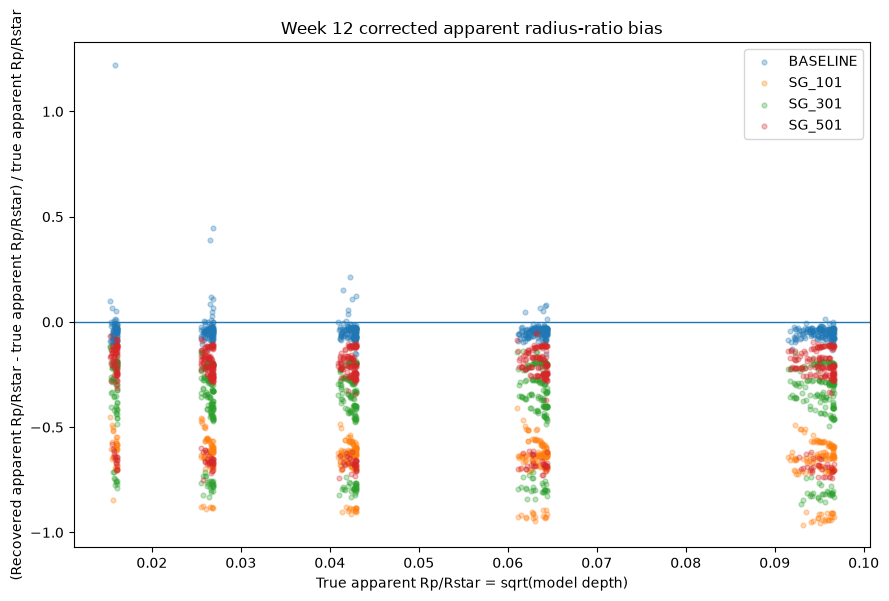


✅ WEEK 12 RADIUS-BIAS CORRECTION COMPLETE
✅ NO SEARCHES RERUN
✅ NO INJECTIONS RERUN
✅ COMPLETENESS UNCHANGED
✅ DEPTH BIAS UNCHANGED
✅ APPARENT RADIUS BIAS NOW PHYSICALLY CONSISTENT
✅ HELD-OUT HOSTS STILL UNTOUCHED


In [24]:
# ============================================================
# WEEK 12.1
# CORRECT DEPTH-DERIVED RADIUS-RATIO BIAS
#
# No new searches.
# No new injections.
# No held-out data.
#
# We compare:
#   true apparent Rp/R*     = sqrt(true model depth)
#   recovered apparent Rp/R* = sqrt(found BLS depth)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import json


# ------------------------------------------------------------
# 1. START FROM THE FROZEN WEEK 12 TABLE
# ------------------------------------------------------------

corrected_w12_df = week12_results_df.copy()


# ------------------------------------------------------------
# 2. DEFINE APPARENT RADIUS RATIOS CONSISTENTLY FROM DEPTH
# ------------------------------------------------------------

corrected_w12_df[
    "true_apparent_rp_over_rstar"
] = np.where(
    corrected_w12_df[
        "true_model_depth"
    ] > 0,
    np.sqrt(
        corrected_w12_df[
            "true_model_depth"
        ]
    ),
    np.nan,
)


corrected_w12_df[
    "recovered_apparent_rp_over_rstar"
] = np.where(
    corrected_w12_df[
        "found_depth"
    ] > 0,
    np.sqrt(
        corrected_w12_df[
            "found_depth"
        ]
    ),
    np.nan,
)


corrected_w12_df[
    "apparent_radius_fractional_error"
] = (
    corrected_w12_df[
        "recovered_apparent_rp_over_rstar"
    ]
    -
    corrected_w12_df[
        "true_apparent_rp_over_rstar"
    ]
) / corrected_w12_df[
    "true_apparent_rp_over_rstar"
]


# ------------------------------------------------------------
# 3. ONLY INTERPRET RADIUS BIAS ON EXACT RECOVERIES
# ------------------------------------------------------------

exact_corrected = corrected_w12_df[
    corrected_w12_df[
        "primary_recovered"
    ] == True
].copy()


# ------------------------------------------------------------
# 4. CORRECTED METHOD SUMMARY
# ------------------------------------------------------------

corrected_method_rows = []


for method_name, group in corrected_w12_df.groupby(
    "method"
):

    exact_group = group[
        group[
            "primary_recovered"
        ] == True
    ]


    corrected_method_rows.append({

        "method":
            method_name,

        "attempted":
            len(group),

        "exact_recovered":
            int(
                group[
                    "primary_recovered"
                ].sum()
            ),

        "exact_completeness":
            group[
                "primary_recovered"
            ].mean(),

        "median_depth_fractional_error_exact":
            exact_group[
                "depth_fractional_error"
            ].median(),

        "median_apparent_radius_fractional_error_exact":
            exact_group[
                "apparent_radius_fractional_error"
            ].median(),
    })


corrected_method_summary_df = pd.DataFrame(
    corrected_method_rows
)


METHOD_ORDER = [
    "BASELINE",
    "SG_101",
    "SG_301",
    "SG_501",
]


corrected_method_summary_df[
    "_order"
] = corrected_method_summary_df[
    "method"
].map(
    {
        method: i
        for i, method
        in enumerate(
            METHOD_ORDER
        )
    }
)


corrected_method_summary_df = (
    corrected_method_summary_df
    .sort_values(
        "_order"
    )
    .drop(
        columns="_order"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nCORRECTED METHOD SUMMARY"
)

display(
    corrected_method_summary_df
)


# ------------------------------------------------------------
# 5. CORRECTED PAIRED RADIUS-BIAS VS BASELINE
#
# Only cases recovered exactly by BOTH methods.
# ------------------------------------------------------------

baseline_exact = (

    corrected_w12_df[

        (
            corrected_w12_df[
                "method"
            ] == "BASELINE"
        )

        &

        (
            corrected_w12_df[
                "primary_recovered"
            ] == True
        )

    ][
        [
            "case_id",
            "apparent_radius_fractional_error",
        ]
    ]

    .rename(
        columns={
            "apparent_radius_fractional_error":
                "baseline_apparent_radius_error"
        }
    )
)


paired_radius_rows = []


for method_name in [
    "SG_101",
    "SG_301",
    "SG_501",
]:

    method_exact = (

        corrected_w12_df[

            (
                corrected_w12_df[
                    "method"
                ] == method_name
            )

            &

            (
                corrected_w12_df[
                    "primary_recovered"
                ] == True
            )

        ][
            [
                "case_id",
                "apparent_radius_fractional_error",
            ]
        ]

        .rename(
            columns={
                "apparent_radius_fractional_error":
                    "method_apparent_radius_error"
            }
        )
    )


    paired = baseline_exact.merge(
        method_exact,
        on="case_id",
        how="inner",
    )


    paired[
        "delta_apparent_radius_error_vs_baseline"
    ] = (
        paired[
            "method_apparent_radius_error"
        ]
        -
        paired[
            "baseline_apparent_radius_error"
        ]
    )


    paired_radius_rows.append({

        "method":
            method_name,

        "n_common_exact_recoveries":
            len(
                paired
            ),

        "median_delta_apparent_radius_error_vs_baseline":
            paired[
                "delta_apparent_radius_error_vs_baseline"
            ].median(),

        "fraction_more_radius_suppression_than_baseline":
            (
                paired[
                    "delta_apparent_radius_error_vs_baseline"
                ] < 0
            ).mean(),
    })


corrected_paired_radius_df = pd.DataFrame(
    paired_radius_rows
)


print(
    "\nCORRECTED PAIRED APPARENT-RADIUS BIAS"
)

display(
    corrected_paired_radius_df
)


# ------------------------------------------------------------
# 6. CORRECTED RADIUS-BIAS FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for method_name in METHOD_ORDER:

    subset = exact_corrected[
        exact_corrected[
            "method"
        ] == method_name
    ]


    ax.scatter(

        subset[
            "true_apparent_rp_over_rstar"
        ],

        subset[
            "apparent_radius_fractional_error"
        ],

        s=12,

        alpha=0.30,

        label=method_name,
    )


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xlabel(
    "True apparent Rp/Rstar = sqrt(model depth)"
)


ax.set_ylabel(
    (
        "(Recovered apparent Rp/Rstar - "
        "true apparent Rp/Rstar) / true apparent Rp/Rstar"
    )
)


ax.set_title(
    "Week 12 corrected apparent radius-ratio bias"
)


ax.legend()


fig.tight_layout()


corrected_radius_fig_path = (

    W12_FIGURES_DIR
    / "radius_bias_corrected.png"
)


fig.savefig(
    corrected_radius_fig_path,
    dpi=220,
)


plt.show()


# ------------------------------------------------------------
# 7. SAVE CORRECTED TABLES
# ------------------------------------------------------------

corrected_results_path = (

    W12_RESULTS_DIR
    / "DET_detrending_results_corrected_radius.csv"
)


corrected_summary_path = (

    W12_RESULTS_DIR
    / "W12_method_summary_corrected_radius.csv"
)


corrected_paired_path = (

    W12_RESULTS_DIR
    / "W12_paired_radius_bias_corrected.csv"
)


corrected_w12_df.to_csv(
    corrected_results_path,
    index=False,
)


corrected_method_summary_df.to_csv(
    corrected_summary_path,
    index=False,
)


corrected_paired_radius_df.to_csv(
    corrected_paired_path,
    index=False,
)


# ------------------------------------------------------------
# 8. SAVE CORRECTION NOTE
# ------------------------------------------------------------

correction_note = {

    "version":
        "W12_RADIUS_CORRECTION_V1",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "reason":
        (
            "Original radius bias compared sqrt(found BLS depth) "
            "against injected geometric Rp/Rstar. "
            "Because model transit depth depends on geometry and "
            "limb darkening, the corrected comparison uses "
            "sqrt(model depth) on the truth side as well."
        ),

    "new_searches_run":
        0,

    "new_injections_run":
        0,

    "heldout_hosts_used":
        False,

    "week12_recovery_results_changed":
        False,

    "week12_completeness_changed":
        False,
}


with open(

    W12_CONFIG_DIR
    / "W12_RADIUS_CORRECTION_V1.json",

    "w",

) as f:

    json.dump(
        correction_note,
        f,
        indent=2,
    )


print()
print("=" * 70)
print("✅ WEEK 12 RADIUS-BIAS CORRECTION COMPLETE")
print("✅ NO SEARCHES RERUN")
print("✅ NO INJECTIONS RERUN")
print("✅ COMPLETENESS UNCHANGED")
print("✅ DEPTH BIAS UNCHANGED")
print("✅ APPARENT RADIUS BIAS NOW PHYSICALLY CONSISTENT")
print("✅ HELD-OUT HOSTS STILL UNTOUCHED")
print("=" * 70)

✅ Frozen project state found.
✅ Held-out firewall intact.
CPU cores: 16
Outer Week 13 workers: 2
✅ Frozen Week 13 subset: 200 cases
✅ Week 13 protocol frozen.
TLS validation: WASP-18
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18299 data points, 2502 periods from 0.602 to 13.703 days
Using 1 of 16 CPU threads
Searching for best T0 for period 0.94152 days
TLS validation: WASP-43
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 37 durations
Searching 15274 data points, 2120 periods from 0.601 to 11.916 days
Using 1 of 16 CPU threads
Searching for best T0 for period 0.81333 days

TLS KNOWN-PLANET VALIDATION


,target,reference_period_days,found_period_days,found_epoch_btjd,found_depth,detection_statistic,runtime_seconds,recovery_category
0,WASP-18,0.941452,0.941515,1354.457188,0.011507,42.447869,27.643498,EXACT
1,WASP-43,0.813475,0.813332,1545.232668,0.024673,34.635054,21.498350,EXACT



TLS already completed: 0
TLS pending: 200
TLS checkpoint: 2/200 | elapsed 1.8 min
TLS checkpoint: 4/200 | elapsed 4.1 min
TLS checkpoint: 6/200 | elapsed 6.4 min
TLS checkpoint: 8/200 | elapsed 8.8 min
TLS checkpoint: 10/200 | elapsed 11.2 min
TLS checkpoint: 12/200 | elapsed 12.9 min
TLS checkpoint: 14/200 | elapsed 15.0 min
TLS checkpoint: 16/200 | elapsed 16.9 min
TLS checkpoint: 18/200 | elapsed 18.8 min
TLS checkpoint: 20/200 | elapsed 20.9 min
TLS checkpoint: 22/200 | elapsed 22.5 min
TLS checkpoint: 24/200 | elapsed 24.1 min
TLS checkpoint: 26/200 | elapsed 26.2 min
TLS checkpoint: 28/200 | elapsed 28.2 min
TLS checkpoint: 30/200 | elapsed 30.2 min
TLS checkpoint: 32/200 | elapsed 32.1 min
TLS checkpoint: 34/200 | elapsed 34.2 min
TLS checkpoint: 36/200 | elapsed 36.5 min
TLS checkpoint: 38/200 | elapsed 39.4 min
TLS checkpoint: 40/200 | elapsed 41.8 min
TLS checkpoint: 42/200 | elapsed 42.4 min
TLS checkpoint: 44/200 | elapsed 43.1 min
TLS checkpoint: 46/200 | elapsed 43.7 min

,method,attempted,exact_recovered,exact_completeness,alias_aware_recovered,alias_aware_completeness,median_search_runtime_seconds,median_total_runtime_seconds
0,BLS,200,128,0.64,128,0.64,3.379672,NaN
1,TLS,200,126,0.63,128,0.64,32.133892,32.149651



ALIAS TABLE


...

,BLS_miss_TLS_recovery,BLS_recovery_TLS_miss,both_recovered,both_missed
0,2,4,124,70



VETTING SUMMARY


,method,median_odd_even_fractional_difference,median_secondary_to_primary_ratio,median_individual_transit_relative_scatter,median_n_measured_transits
0,BLS,0.19880,-0.088899,0.129048,4.0
1,TLS,0.35629,-0.086164,0.137648,3.0


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 37 durations
Searching 75238 data points, 2174 periods from 0.601 to 12.17 days
Using 1 of 16 CPU threads
Searching for best T0 for period 4.75749 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 37 durations
Searching 15468 data points, 2201 periods from 0.601 to 12.299 days
Using 1 of 16 CPU threads
Searching for best T0 for period 5.74819 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 37 durations
Searching 12988 data points, 2148 periods from 0.601 to 12.049 days
Using 1 of 16 CPU threads
Searching for best T0 for period 6.53545 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 17304 data points, 2322 periods from 0.601 to 12.863 days
Using 1 of 16 CPU threads
Searching for best T0 for period 11.59519 days
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 14835 data points, 2

,control_id,method,found_period_days,detection_statistic,runtime_seconds
0,CONTROL-001,BLS,14.418719,17.852602,7.632012
1,CONTROL-001,TLS,4.757489,6.720887,82.056199
2,CONTROL-002,BLS,5.990483,10.801339,1.681861
3,CONTROL-002,TLS,5.748194,5.972400,16.927537
4,CONTROL-003,BLS,6.467648,34.695018,1.396734
5,CONTROL-003,TLS,6.535449,8.018820,18.460517
6,CONTROL-004,BLS,6.269156,144.107001,1.987097
7,CONTROL-004,TLS,11.595189,3.961981,24.590376
8,CONTROL-005,BLS,9.072500,120.352242,1.716936
9,CONTROL-005,TLS,9.117798,7.751063,31.430664


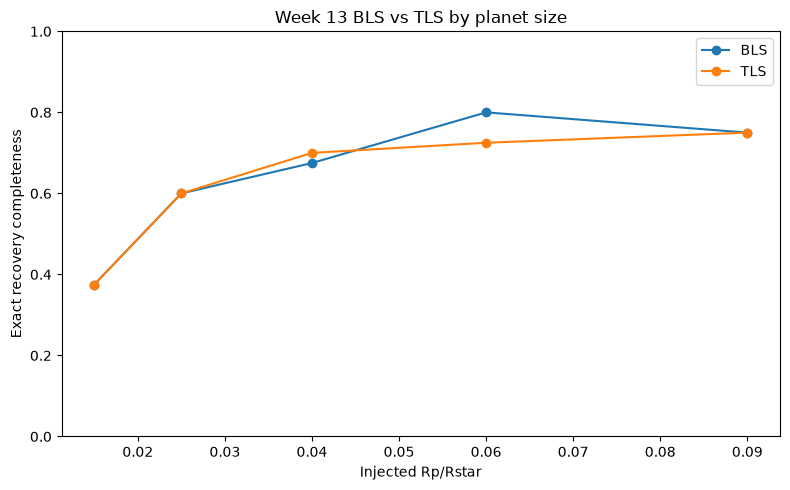

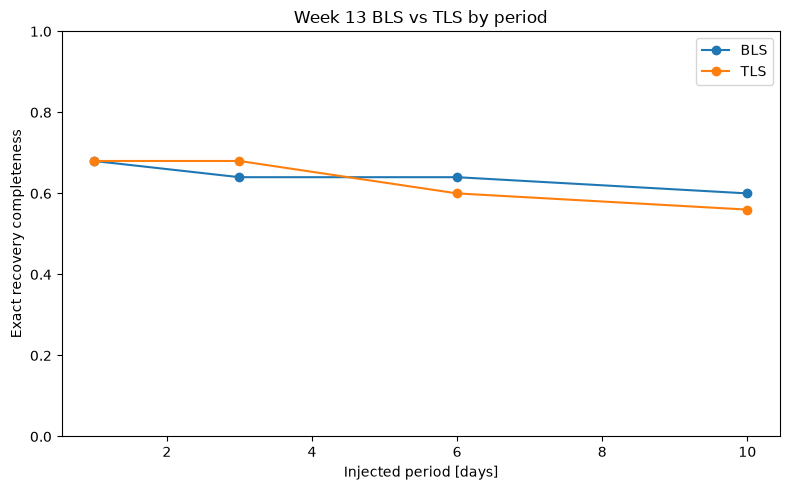


WEEK 13 BLS vs TLS + VETTING RESULTS

METHOD SUMMARY


,method,attempted,exact_recovered,exact_completeness,alias_aware_recovered,alias_aware_completeness,median_search_runtime_seconds,median_total_runtime_seconds
0,BLS,200,128,0.64,128,0.64,3.379672,NaN
1,TLS,200,126,0.63,128,0.64,32.133892,32.149651



ALIAS TABLE


,method,recovery_category,count,fraction
0,BLS,MISS,200,1.00
1,TLS,EXACT,126,0.63
2,TLS,HALF_ALIAS,2,0.01
3,TLS,MISS,72,0.36



PAIRED RECOVERY SWITCHES


...


VETTING SUMMARY


,method,median_odd_even_fractional_difference,median_secondary_to_primary_ratio,median_individual_transit_relative_scatter,median_n_measured_transits
0,BLS,0.19880,-0.088899,0.129048,4.0
1,TLS,0.35629,-0.086164,0.137648,3.0



NO-INJECTION CONTROL BEHAVIOR


,control_id,method,found_period_days,detection_statistic,runtime_seconds
0,CONTROL-001,BLS,14.418719,17.852602,7.632012
1,CONTROL-001,TLS,4.757489,6.720887,82.056199
2,CONTROL-002,BLS,5.990483,10.801339,1.681861
3,CONTROL-002,TLS,5.748194,5.972400,16.927537
4,CONTROL-003,BLS,6.467648,34.695018,1.396734
5,CONTROL-003,TLS,6.535449,8.018820,18.460517
6,CONTROL-004,BLS,6.269156,144.107001,1.987097
7,CONTROL-004,TLS,11.595189,3.961981,24.590376
8,CONTROL-005,BLS,9.072500,120.352242,1.716936
9,CONTROL-005,TLS,9.117798,7.751063,31.430664



 WEEK 13 CORE BENCHMARK COMPLETE
 TLS VALIDATED ON KNOWN PLANETS
 200 IDENTICAL CASES COMPARED
 BLS AND TLS USE SAME PERIOD RANGE
 ALIAS CLASSES REPORTED
 ODD-EVEN CHECK IMPLEMENTED
 SECONDARY-ECLIPSE CHECK IMPLEMENTED
 TRANSIT CONSISTENCY CHECK IMPLEMENTED
 RUNTIME RECORDED
 DEVELOPMENT CONTROLS COMPARED
 HELD-OUT HOSTS REMAIN UNTOUCHED
 W13_BLS_TLS_V1 FROZEN


In [27]:
# ============================================================
# WEEK 13
# BLS vs TLS + BASIC CANDIDATE VETTING
#
# DESIGN:
#   200 frozen injection cases
#   5 hosts
#   4 periods
#   5 Rp/Rstar levels
#   2 repetitions per cell
#
# SAME:
#   injection
#   host
#   preprocessing = BASELINE
#   period range = 0.5 to 15 d
#   RECOVERY_V2
#
# COMPARE:
#   BLS
#   TLS
#
# VETTING:
#   1. odd-even depth comparison
#   2. secondary eclipse-like depth near phase 0.5
#   3. individual-transit depth consistency
#
# HELD-OUT HOSTS REMAIN UNTOUCHED
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from transitleastsquares import transitleastsquares


# ============================================================
# 1. REQUIRE FROZEN PROJECT STATE
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",

    "development_host_data",
    "development_hosts_df",
    "heldout_hosts_df",

    "week11_design_df",
    "week11_results_df",

    "host_bls_grids",

    "inject_transit",
    "blind_bls_search",
    "evaluate_recovery_v2",
    "BLS_CONFIG",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Required frozen project state is missing.\n"
        f"Missing: {missing}"
    )


assert len(
    week11_design_df
) == 1000


assert len(
    week11_results_df
) == 1000


assert (
    heldout_hosts_df[
        "bls_run"
    ] == False
).all()


assert (
    heldout_hosts_df[
        "injection_run"
    ] == False
).all()


assert (
    heldout_hosts_df[
        "used_for_tuning"
    ] == False
).all()


print(
    "✅ Frozen project state found."
)

print(
    "✅ Held-out firewall intact."
)


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

W13_RESULTS_DIR = (
    RESULTS_DIR
    / "week13_bls_tls_vetting"
)

W13_FIGURES_DIR = (
    FIGURES_DIR
    / "week13_bls_tls_vetting"
)

W13_CONFIG_DIR = (
    CONFIG_DIR
    / "week13_bls_tls_vetting"
)


for folder in [
    W13_RESULTS_DIR,
    W13_FIGURES_DIR,
    W13_CONFIG_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 3. CPU SETTINGS
#
# TLS already uses substantial CPU.
# Keep outer parallelism low.
# ============================================================

CPU_COUNT_W13 = (
    os.cpu_count()
    or 2
)


N_JOBS_W13 = max(
    1,
    min(
        CPU_COUNT_W13 - 1,
        2,
    )
)


print(
    "CPU cores:",
    CPU_COUNT_W13,
)

print(
    "Outer Week 13 workers:",
    N_JOBS_W13,
)


# ============================================================
# 4. FREEZE 200-CASE COMPARISON SUBSET
#
# 5 hosts
# × 4 periods
# × 5 sizes
# × first 2 repetitions
# = 200 cases
# ============================================================

week13_subset_df = (

    week11_design_df[

        week11_design_df[
            "repetition"
        ].isin(
            [
                1,
                2,
            ]
        )

    ]

    .copy()

    .sort_values(
        [
            "control_id",
            "true_period_days",
            "rp_over_rstar",
            "repetition",
        ]
    )

    .reset_index(
        drop=True
    )
)


assert len(
    week13_subset_df
) == 200


assert (
    week13_subset_df[
        "case_id"
    ].nunique()
    == 200
)


print(
    "✅ Frozen Week 13 subset:",
    len(
        week13_subset_df
    ),
    "cases"
)


# ============================================================
# 5. FREEZE WEEK 13 PROTOCOL
# ============================================================

WEEK13_PROTOCOL = {

    "version":
        "W13_BLS_TLS_V1",

    "source_injections":
        "W11_COMPLETENESS_V1",

    "n_cases":
        200,

    "selection_rule":
        (
            "All development hosts, all four periods, "
            "all five Rp/Rstar levels, repetitions 1 and 2."
        ),

    "preprocessing":
        "BASELINE",

    "methods":
        [
            "BLS",
            "TLS",
        ],

    "period_min_days":
        0.5,

    "period_max_days":
        15.0,

    "recovery_protocol":
        "RECOVERY_V2",

    "primary_recovery":
        "EXACT within 1%",

    "aliases":
        [
            "EXACT",
            "HALF_ALIAS",
            "DOUBLE_ALIAS",
            "NEAR_MATCH",
            "MISS",
        ],

    "vetting_checks":
        [
            "odd_even_depth_difference",
            "secondary_phase_0p5_depth",
            "individual_transit_depth_consistency",
        ],

    "heldout_hosts_used":
        False,
}


with open(

    W13_CONFIG_DIR
    / "W13_BLS_TLS_V1.json",

    "w",

) as f:

    json.dump(
        WEEK13_PROTOCOL,
        f,
        indent=2,
    )


week13_subset_df.to_csv(

    W13_RESULTS_DIR
    / "W13_case_subset.csv",

    index=False,
)


print(
    "✅ Week 13 protocol frozen."
)


# ============================================================
# 6. COMPATIBILITY-SAFE INJECTION WRAPPER
# ============================================================

def w13_call_inject_transit(
    host,
    period_days,
    epoch,
    rp_rs,
    impact_parameter,
):

    return inject_transit(

        host[
            "time"
        ],

        host[
            "flux"
        ],

        float(
            period_days
        ),

        float(
            epoch
        ),

        float(
            rp_rs
        ),

        float(
            host[
                "stellar_mass_msun"
            ]
        ),

        float(
            host[
                "stellar_radius_rsun"
            ]
        ),

        float(
            impact_parameter
        ),

        7,
    )


# ============================================================
# 7. REGENERATE IDENTICAL WEEK 11 INJECTION
# ============================================================

def w13_regenerate_injection(
    case,
):

    control_id = str(
        case[
            "control_id"
        ]
    )

    period = float(
        case[
            "true_period_days"
        ]
    )

    rp_rs = float(
        case[
            "rp_over_rstar"
        ]
    )

    seed = int(
        case[
            "seed"
        ]
    )


    host = development_host_data[
        control_id
    ]


    rng = np.random.default_rng(
        seed
    )


    impact_parameter = float(
        rng.uniform(
            0,
            0.7,
        )
    )


    epoch = float(

        host[
            "time"
        ].min()

        +

        rng.uniform(
            0,
            period,
        )
    )


    injected_flux, truth = (
        w13_call_inject_transit(

            host,

            period,

            epoch,

            rp_rs,

            impact_parameter,
        )
    )


    return {

        "time":
            np.asarray(
                host[
                    "time"
                ],
                dtype=float,
            ),

        "flux":
            np.asarray(
                injected_flux,
                dtype=float,
            ),

        "truth": {

            **truth,

            "case_id":
                str(
                    case[
                        "case_id"
                    ]
                ),

            "control_id":
                control_id,

            "seed":
                seed,

            "period":
                period,

            "rp_over_rstar":
                rp_rs,

            "epoch":
                epoch,

            "impact_parameter":
                impact_parameter,
        },
    }


# ============================================================
# 8. TLS SEARCH WRAPPER
# ============================================================

def run_tls_search(
    time_values,
    flux_values,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )

    f = np.asarray(
        flux_values,
        dtype=float,
    )


    good = (
        np.isfinite(
            t
        )
        &
        np.isfinite(
            f
        )
    )


    t = t[
        good
    ]

    f = f[
        good
    ]


    start = (
        time.perf_counter()
    )


    model = (
        transitleastsquares(
            t,
            f,
        )
    )


    result = model.power(

        period_min=0.5,

        period_max=15.0,

        show_progress_bar=False,

        use_threads=1,
    )


    runtime = (
        time.perf_counter()
        -
        start
    )


    found_period = float(
        result.period
    )


    found_epoch = float(
        result.T0
    )


    tls_sde = float(
        result.SDE
    )


    try:

        found_depth = float(
            result.depth
        )

        # TLS depth is commonly returned as
        # relative flux level in transit.
        # Convert to fractional dip if necessary.
        if (
            np.isfinite(
                found_depth
            )
            and
            found_depth > 0.5
        ):

            fractional_depth = (
                1.0
                -
                found_depth
            )

        else:

            fractional_depth = (
                found_depth
            )

    except Exception:

        fractional_depth = np.nan


    return {

        "found_period_days":
            found_period,

        "found_epoch_btjd":
            found_epoch,

        "found_depth":
            fractional_depth,

        "detection_statistic":
            tls_sde,

        "runtime_seconds":
            runtime,
    }


# ============================================================
# 9. PHASE HELPER
# ============================================================

def signed_phase(
    time_values,
    period,
    epoch,
):

    return (

        (
            (
                np.asarray(
                    time_values
                )
                -
                epoch
                +
                0.5
                *
                period
            )
            %
            period
        )
        /
        period

        -
        0.5
    )


# ============================================================
# 10. ROBUST MEDIAN DEPTH
# ============================================================

def robust_depth(
    flux_values,
    mask,
):

    f = np.asarray(
        flux_values,
        dtype=float,
    )


    mask = np.asarray(
        mask,
        dtype=bool,
    )


    if (
        mask.sum()
        <
        3
    ):

        return np.nan


    outside = (
        ~mask
    )


    if (
        outside.sum()
        <
        10
    ):

        return np.nan


    baseline = np.nanmedian(
        f[
            outside
        ]
    )


    inside = np.nanmedian(
        f[
            mask
        ]
    )


    return float(
        baseline
        -
        inside
    )


# ============================================================
# 11. ODD-EVEN DEPTH CHECK
# ============================================================

def odd_even_depth_check(
    time_values,
    flux_values,
    period,
    epoch,
    duration_fraction=0.04,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )

    f = np.asarray(
        flux_values,
        dtype=float,
    )


    transit_number = np.rint(

        (
            t
            -
            epoch
        )
        /
        period

    ).astype(
        int
    )


    centers = (
        epoch
        +
        transit_number
        *
        period
    )


    distance = np.abs(
        t
        -
        centers
    )


    half_width = (
        0.5
        *
        duration_fraction
        *
        period
    )


    in_transit = (
        distance
        <=
        half_width
    )


    odd_mask = (

        in_transit

        &

        (
            transit_number
            %
            2
            !=
            0
        )
    )


    even_mask = (

        in_transit

        &

        (
            transit_number
            %
            2
            ==
            0
        )
    )


    odd_depth = robust_depth(
        f,
        odd_mask,
    )


    even_depth = robust_depth(
        f,
        even_mask,
    )


    if (
        np.isfinite(
            odd_depth
        )
        and
        np.isfinite(
            even_depth
        )
    ):

        scale = max(

            abs(
                odd_depth
            ),

            abs(
                even_depth
            ),

            1e-12,
        )


        fractional_difference = (

            abs(
                odd_depth
                -
                even_depth
            )

            /
            scale
        )

    else:

        fractional_difference = np.nan


    return {

        "odd_depth":
            odd_depth,

        "even_depth":
            even_depth,

        "odd_even_fractional_difference":
            fractional_difference,
    }


# ============================================================
# 12. SECONDARY-ECLIPSE-LIKE CHECK
#
# Measures a dip near phase 0.5 relative to primary.
# Evidence only, not a binary classification.
# ============================================================

def secondary_eclipse_check(
    time_values,
    flux_values,
    period,
    epoch,
    duration_fraction=0.04,
):

    phase = signed_phase(
        time_values,
        period,
        epoch,
    )


    f = np.asarray(
        flux_values,
        dtype=float,
    )


    half_width = (
        duration_fraction
        /
        2
    )


    primary_mask = (
        np.abs(
            phase
        )
        <=
        half_width
    )


    distance_secondary = np.minimum(

        np.abs(
            phase
            -
            0.5
        ),

        np.abs(
            phase
            +
            0.5
        ),
    )


    secondary_mask = (
        distance_secondary
        <=
        half_width
    )


    primary_depth = robust_depth(
        f,
        primary_mask,
    )


    secondary_depth = robust_depth(
        f,
        secondary_mask,
    )


    if (
        np.isfinite(
            primary_depth
        )
        and
        primary_depth
        !=
        0
        and
        np.isfinite(
            secondary_depth
        )
    ):

        secondary_to_primary = (

            secondary_depth
            /
            primary_depth
        )

    else:

        secondary_to_primary = np.nan


    return {

        "vet_primary_depth":
            primary_depth,

        "secondary_depth":
            secondary_depth,

        "secondary_to_primary_ratio":
            secondary_to_primary,
    }


# ============================================================
# 13. INDIVIDUAL-TRANSIT CONSISTENCY
#
# Measures spread of per-transit depths.
# ============================================================

def transit_consistency_check(
    time_values,
    flux_values,
    period,
    epoch,
    duration_fraction=0.04,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )

    f = np.asarray(
        flux_values,
        dtype=float,
    )


    n_min = int(
        np.floor(
            (
                t.min()
                -
                epoch
            )
            /
            period
        )
    )


    n_max = int(
        np.ceil(
            (
                t.max()
                -
                epoch
            )
            /
            period
        )
    )


    depths = []


    half_width = (
        0.5
        *
        duration_fraction
        *
        period
    )


    local_window = (
        3
        *
        half_width
    )


    for n in range(
        n_min,
        n_max + 1,
    ):

        center = (
            epoch
            +
            n
            *
            period
        )


        local = (
            np.abs(
                t
                -
                center
            )
            <=
            local_window
        )


        transit = (
            np.abs(
                t
                -
                center
            )
            <=
            half_width
        )


        baseline_mask = (
            local
            &
            (~transit)
        )


        if (
            transit.sum()
            <
            3
            or
            baseline_mask.sum()
            <
            5
        ):

            continue


        baseline = np.nanmedian(
            f[
                baseline_mask
            ]
        )


        inside = np.nanmedian(
            f[
                transit
            ]
        )


        depth = (
            baseline
            -
            inside
        )


        if np.isfinite(
            depth
        ):

            depths.append(
                float(
                    depth
                )
            )


    depths = np.asarray(
        depths,
        dtype=float,
    )


    if (
        len(
            depths
        )
        >=
        2
    ):

        median_depth = np.nanmedian(
            depths
        )


        scatter = (
            1.4826
            *
            np.nanmedian(
                np.abs(
                    depths
                    -
                    median_depth
                )
            )
        )


        if (
            median_depth
            !=
            0
        ):

            relative_scatter = (

                scatter
                /
                abs(
                    median_depth
                )
            )

        else:

            relative_scatter = np.nan

    else:

        median_depth = np.nan
        scatter = np.nan
        relative_scatter = np.nan


    return {

        "n_measured_transits":
            int(
                len(
                    depths
                )
            ),

        "median_individual_transit_depth":
            median_depth,

        "individual_transit_depth_scatter":
            scatter,

        "individual_transit_relative_scatter":
            relative_scatter,
    }


# ============================================================
# 14. VALIDATE TLS ON KNOWN PLANETS FIRST
#
# Cookbook explicitly requires this before benchmark use.
# ============================================================

known_planets = [

    {
        "target":
            "WASP-18",

        "period":
            0.94145223,
    },

    {
        "target":
            "WASP-43",

        "period":
            0.813475,
    },
]


tls_validation_rows = []


for planet in known_planets:

    print(
        "TLS validation:",
        planet[
            "target"
        ]
    )


    known_lc = download_spoc_sector(
        planet[
            "target"
        ]
    )


    tls_result = run_tls_search(

        known_lc[
            "time"
        ],

        known_lc[
            "flux"
        ],
    )


    evaluation = evaluate_recovery_v2(

        true_period=planet[
            "period"
        ],

        found_period=tls_result[
            "found_period_days"
        ],
    )


    tls_validation_rows.append({

        "target":
            planet[
                "target"
            ],

        "reference_period_days":
            planet[
                "period"
            ],

        **tls_result,

        "recovery_category":
            evaluation[
                "category"
            ],
    })


tls_validation_df = pd.DataFrame(
    tls_validation_rows
)


print(
    "\nTLS KNOWN-PLANET VALIDATION"
)

display(
    tls_validation_df
)


tls_validation_df.to_csv(

    W13_RESULTS_DIR
    / "W13_TLS_known_planet_validation.csv",

    index=False,
)


# ============================================================
# 15. BLS RESULT FOR EACH SUBSET CASE
#
# We reuse frozen Week 11 BLS results.
# No reason to rerun them.
# ============================================================

bls_subset_df = (

    week11_results_df[
        week11_results_df[
            "case_id"
        ].isin(
            week13_subset_df[
                "case_id"
            ]
        )
    ]

    .copy()
)


assert len(
    bls_subset_df
) == 200


# ============================================================
# 16. TLS SINGLE-CASE WORKER
# ============================================================

def run_week13_tls_case(
    case,
):

    start_total = (
        time.perf_counter()
    )


    case_id = str(
        case[
            "case_id"
        ]
    )


    control_id = str(
        case[
            "control_id"
        ]
    )


    true_period = float(
        case[
            "true_period_days"
        ]
    )


    try:

        regenerated = (
            w13_regenerate_injection(
                case
            )
        )


        t = regenerated[
            "time"
        ]


        f = regenerated[
            "flux"
        ]


        tls_result = (
            run_tls_search(
                t,
                f,
            )
        )


        evaluation = (
            evaluate_recovery_v2(

                true_period=true_period,

                found_period=tls_result[
                    "found_period_days"
                ],
            )
        )


        found_period = (
            tls_result[
                "found_period_days"
            ]
        )


        found_epoch = (
            tls_result[
                "found_epoch_btjd"
            ]
        )


        odd_even = (
            odd_even_depth_check(

                t,
                f,
                found_period,
                found_epoch,
            )
        )


        secondary = (
            secondary_eclipse_check(

                t,
                f,
                found_period,
                found_epoch,
            )
        )


        consistency = (
            transit_consistency_check(

                t,
                f,
                found_period,
                found_epoch,
            )
        )


        return {

            "case_id":
                case_id,

            "control_id":
                control_id,

            "seed":
                int(
                    case[
                        "seed"
                    ]
                ),

            "true_period_days":
                true_period,

            "rp_over_rstar":
                float(
                    case[
                        "rp_over_rstar"
                    ]
                ),

            "method":
                "TLS",

            **tls_result,

            "recovery_category":
                evaluation[
                    "category"
                ],

            "primary_recovered":
                evaluation[
                    "primary_recovered"
                ],

            "alias_aware_recovered":
                evaluation[
                    "alias_aware_recovered"
                ],

            **odd_even,
            **secondary,
            **consistency,

            "runtime_total_seconds":
                (
                    time.perf_counter()
                    -
                    start_total
                ),

            "status":
                "SUCCESS",
        }


    except Exception as error:

        return {

            "case_id":
                case_id,

            "control_id":
                control_id,

            "true_period_days":
                true_period,

            "rp_over_rstar":
                float(
                    case[
                        "rp_over_rstar"
                    ]
                ),

            "method":
                "TLS",

            "recovery_category":
                "FAILED",

            "primary_recovered":
                False,

            "alias_aware_recovered":
                False,

            "runtime_total_seconds":
                (
                    time.perf_counter()
                    -
                    start_total
                ),

            "status":
                "FAILED",

            "error":
                repr(
                    error
                ),
        }


# ============================================================
# 17. TLS CHECKPOINT / RESUME
# ============================================================

TLS_CHECKPOINT_PATH = (

    W13_RESULTS_DIR
    / "W13_TLS_checkpoint.csv"
)


TLS_RESULTS_PATH = (

    W13_RESULTS_DIR
    / "W13_TLS_results.csv"
)


if TLS_CHECKPOINT_PATH.exists():

    tls_existing_df = (

        pd.read_csv(
            TLS_CHECKPOINT_PATH
        )

        .drop_duplicates(
            "case_id",
            keep="last",
        )
    )

else:

    tls_existing_df = pd.DataFrame()


completed_tls_ids = (

    set(
        tls_existing_df[
            "case_id"
        ].astype(
            str
        )
    )

    if len(
        tls_existing_df
    )

    else set()
)


tls_pending_df = (

    week13_subset_df[
        ~week13_subset_df[
            "case_id"
        ].astype(
            str
        ).isin(
            completed_tls_ids
        )
    ]

    .copy()
)


print()
print(
    "TLS already completed:",
    len(
        tls_existing_df
    ),
)

print(
    "TLS pending:",
    len(
        tls_pending_df
    ),
)


# ============================================================
# 18. RUN TLS BENCHMARK
# ============================================================

current_tls_df = (
    tls_existing_df.copy()
)


W13_CHUNK_SIZE = max(
    2,
    N_JOBS_W13
)


session_start = (
    time.perf_counter()
)


for start_index in range(

    0,

    len(
        tls_pending_df
    ),

    W13_CHUNK_SIZE,
):

    chunk = (
        tls_pending_df
        .iloc[
            start_index:
            start_index
            +
            W13_CHUNK_SIZE
        ]
    )


    chunk_results = Parallel(

        n_jobs=N_JOBS_W13,

        backend="loky",

        verbose=0,

    )(

        delayed(
            run_week13_tls_case
        )(
            record
        )

        for record
        in chunk.to_dict(
            "records"
        )
    )


    current_tls_df = pd.concat(

        [
            current_tls_df,
            pd.DataFrame(
                chunk_results
            ),
        ],

        ignore_index=True,
    )


    current_tls_df = (

        current_tls_df

        .drop_duplicates(
            "case_id",
            keep="last",
        )
    )


    temp_path = (
        TLS_CHECKPOINT_PATH
        .with_suffix(
            ".tmp.csv"
        )
    )


    current_tls_df.to_csv(
        temp_path,
        index=False,
    )


    temp_path.replace(
        TLS_CHECKPOINT_PATH
    )


    elapsed_min = (

        time.perf_counter()
        -
        session_start

    ) / 60


    print(

        f"TLS checkpoint: "
        f"{len(current_tls_df)}/200 "
        f"| elapsed {elapsed_min:.1f} min"
    )


current_tls_df = (

    current_tls_df

    .sort_values(
        "case_id"
    )

    .reset_index(
        drop=True
    )
)


current_tls_df.to_csv(

    TLS_RESULTS_PATH,

    index=False,
)


assert len(
    current_tls_df
) == 200


print(
    "✅ TLS benchmark complete."
)


# ============================================================
# 19. FORMAT BLS ROWS TO MATCH TLS
# ============================================================

bls_rows = []


for _, row in (
    bls_subset_df.iterrows()
):

    regenerated = (
        w13_regenerate_injection(
            row
        )
    )


    t = regenerated[
        "time"
    ]

    f = regenerated[
        "flux"
    ]


    found_period = float(
        row[
            "found_period_days"
        ]
    )


    found_epoch = row.get(
        "found_epoch_btjd",
        np.nan,
    )


    if not np.isfinite(
        found_epoch
    ):

        found_epoch = (
            regenerated[
                "truth"
            ][
                "epoch"
            ]
        )


    odd_even = (
        odd_even_depth_check(

            t,
            f,
            found_period,
            found_epoch,
        )
    )


    secondary = (
        secondary_eclipse_check(

            t,
            f,
            found_period,
            found_epoch,
        )
    )


    consistency = (
        transit_consistency_check(

            t,
            f,
            found_period,
            found_epoch,
        )
    )


    bls_rows.append({

        "case_id":
            str(
                row[
                    "case_id"
                ]
            ),

        "control_id":
            str(
                row[
                    "control_id"
                ]
            ),

        "seed":
            int(
                row[
                    "seed"
                ]
            ),

        "true_period_days":
            float(
                row[
                    "true_period_days"
                ]
            ),

        "rp_over_rstar":
            float(
                row[
                    "rp_over_rstar"
                ]
            ),

        "method":
            "BLS",

        "found_period_days":
            found_period,

        "found_epoch_btjd":
            found_epoch,

        "found_depth":
            row.get(
                "found_depth",
                np.nan,
            ),

        "detection_statistic":
            row.get(
                "detection_sde",
                np.nan,
            ),

        "runtime_seconds":
            row.get(
                "runtime_seconds_total",
                row.get(
                    "runtime_seconds",
                    np.nan,
                ),
            ),

        "recovery_category":
            row.get(
                "recovery_category",
                "MISS",
            ),

        "primary_recovered":
            bool(
                row[
                    "primary_recovered"
                ]
            ),

        "alias_aware_recovered":
            bool(
                row[
                    "alias_aware_recovered"
                ]
            ),

        **odd_even,
        **secondary,
        **consistency,

        "status":
            row.get(
                "status",
                "SUCCESS",
            ),
    })


bls_w13_df = pd.DataFrame(
    bls_rows
)


# ============================================================
# 20. COMBINE PAIRED BLS + TLS
# ============================================================

week13_results_df = pd.concat(

    [
        bls_w13_df,
        current_tls_df,
    ],

    ignore_index=True,
)


assert len(
    week13_results_df
) == 400


assert (

    week13_results_df

    .groupby(
        "case_id"
    )[
        "method"
    ]

    .nunique()

    ==
    2

).all()


W13_MASTER_RESULTS_PATH = (

    W13_RESULTS_DIR
    / "W13_BLS_TLS_results.csv"
)


week13_results_df.to_csv(

    W13_MASTER_RESULTS_PATH,

    index=False,
)


print(
    "✅ 200 perfectly paired BLS/TLS cases."
)


# ============================================================
# 21. METHOD SUMMARY
# ============================================================

summary_rows = []


for (
    method_name,
    group
) in week13_results_df.groupby(
    "method"
):

    summary_rows.append({

        "method":
            method_name,

        "attempted":
            len(
                group
            ),

        "exact_recovered":
            int(
                group[
                    "primary_recovered"
                ].sum()
            ),

        "exact_completeness":
            group[
                "primary_recovered"
            ].mean(),

        "alias_aware_recovered":
            int(
                group[
                    "alias_aware_recovered"
                ].sum()
            ),

        "alias_aware_completeness":
            group[
                "alias_aware_recovered"
            ].mean(),

        "median_search_runtime_seconds":
            group[
                "runtime_seconds"
            ].median(),

        "median_total_runtime_seconds":
            (
                group[
                    "runtime_total_seconds"
                ].median()

                if
                "runtime_total_seconds"
                in group.columns

                else np.nan
            ),
    })


method_summary_df = pd.DataFrame(
    summary_rows
)


print(
    "\nBLS vs TLS SUMMARY"
)

display(
    method_summary_df
)


# ============================================================
# 22. ALIAS TABLE
# ============================================================

alias_table = (

    week13_results_df

    .groupby(
        [
            "method",
            "recovery_category",
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


alias_table[
    "fraction"
] = (

    alias_table[
        "count"
    ]

    /

    alias_table.groupby(
        "method"
    )[
        "count"
    ].transform(
        "sum"
    )
)


print(
    "\nALIAS TABLE"
)

display(
    alias_table
)


# ============================================================
# 23. COMPLETENESS BY PLANET SIZE
# ============================================================

size_summary = (

    week13_results_df

    .groupby(
        [
            "method",
            "rp_over_rstar",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


print(
    "\nCOMPLETENESS BY SIZE"
)

display(
    size_summary
)


# ============================================================
# 24. COMPLETENESS BY PERIOD
# ============================================================

period_summary = (

    week13_results_df

    .groupby(
        [
            "method",
            "true_period_days",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


print(
    "\nCOMPLETENESS BY PERIOD"
)

display(
    period_summary
)


# ============================================================
# 25. PAIRED RECOVERY SWITCHES
# ============================================================

paired_recovery = (

    week13_results_df

    .pivot(
        index="case_id",
        columns="method",
        values="primary_recovered",
    )

    .reset_index()
)


switch_summary = pd.DataFrame(
    [
        {

            "BLS_miss_TLS_recovery":
                int(
                    (
                        (~paired_recovery[
                            "BLS"
                        ])
                        &
                        (
                            paired_recovery[
                                "TLS"
                            ]
                        )
                    ).sum()
                ),

            "BLS_recovery_TLS_miss":
                int(
                    (
                        (
                            paired_recovery[
                                "BLS"
                            ]
                        )
                        &
                        (~paired_recovery[
                            "TLS"
                        ])
                    ).sum()
                ),

            "both_recovered":
                int(
                    (
                        paired_recovery[
                            "BLS"
                        ]
                        &
                        paired_recovery[
                            "TLS"
                        ]
                    ).sum()
                ),

            "both_missed":
                int(
                    (
                        (~paired_recovery[
                            "BLS"
                        ])
                        &
                        (~paired_recovery[
                            "TLS"
                        ])
                    ).sum()
                ),
        }
    ]
)


print(
    "\nPAIRED RECOVERY SWITCHES"
)

display(
    switch_summary
)


# ============================================================
# 26. VETTING SUMMARY
#
# Evidence distributions only.
# No "planet probability".
# ============================================================

vetting_summary = (

    week13_results_df

    .groupby(
        "method"
    )

    .agg(

        median_odd_even_fractional_difference=(
            "odd_even_fractional_difference",
            "median",
        ),

        median_secondary_to_primary_ratio=(
            "secondary_to_primary_ratio",
            "median",
        ),

        median_individual_transit_relative_scatter=(
            "individual_transit_relative_scatter",
            "median",
        ),

        median_n_measured_transits=(
            "n_measured_transits",
            "median",
        ),
    )

    .reset_index()
)


print(
    "\nVETTING SUMMARY"
)

display(
    vetting_summary
)


# ============================================================
# 27. NO-INJECTION CONTROL SEARCHES
#
# Same 5 development controls.
# ============================================================

control_rows = []


for (
    control_id,
    host
) in development_host_data.items():

    # --------------------------------------------------------
    # BLS
    # --------------------------------------------------------

    bls_control = (
        blind_bls_search(

            host[
                "time"
            ],

            host[
                "flux"
            ],

            period_grid=host_bls_grids[
                control_id
            ],

            config=BLS_CONFIG,
        )
    )


    control_rows.append({

        "control_id":
            control_id,

        "method":
            "BLS",

        "found_period_days":
            bls_control[
                "found_period_days"
            ],

        "detection_statistic":
            bls_control[
                "detection_sde"
            ],

        "runtime_seconds":
            bls_control[
                "runtime_seconds"
            ],
    })


    # --------------------------------------------------------
    # TLS
    # --------------------------------------------------------

    tls_control = (
        run_tls_search(

            host[
                "time"
            ],

            host[
                "flux"
            ],
        )
    )


    control_rows.append({

        "control_id":
            control_id,

        "method":
            "TLS",

        "found_period_days":
            tls_control[
                "found_period_days"
            ],

        "detection_statistic":
            tls_control[
                "detection_statistic"
            ],

        "runtime_seconds":
            tls_control[
                "runtime_seconds"
            ],
    })


control_results_df = pd.DataFrame(
    control_rows
)


print(
    "\nNO-INJECTION CONTROL BEHAVIOR"
)

display(
    control_results_df
)


# ============================================================
# 28. FIGURE — COMPLETENESS BY SIZE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


for method_name in [
    "BLS",
    "TLS",
]:

    subset = size_summary[
        size_summary[
            "method"
        ]
        ==
        method_name
    ]


    ax.plot(

        subset[
            "rp_over_rstar"
        ],

        subset[
            "exact_completeness"
        ],

        marker="o",

        label=method_name,
    )


ax.set_ylim(
    0,
    1,
)


ax.set_xlabel(
    "Injected Rp/Rstar"
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_title(
    "Week 13 BLS vs TLS by planet size"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W13_FIGURES_DIR
    / "BLS_vs_TLS_by_size.png",

    dpi=220,
)


plt.show()


# ============================================================
# 29. FIGURE — COMPLETENESS BY PERIOD
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


for method_name in [
    "BLS",
    "TLS",
]:

    subset = period_summary[
        period_summary[
            "method"
        ]
        ==
        method_name
    ]


    ax.plot(

        subset[
            "true_period_days"
        ],

        subset[
            "exact_completeness"
        ],

        marker="o",

        label=method_name,
    )


ax.set_ylim(
    0,
    1,
)


ax.set_xlabel(
    "Injected period [days]"
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_title(
    "Week 13 BLS vs TLS by period"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W13_FIGURES_DIR
    / "BLS_vs_TLS_by_period.png",

    dpi=220,
)


plt.show()


# ============================================================
# 30. SAVE TABLES
# ============================================================

method_summary_df.to_csv(

    W13_RESULTS_DIR
    / "W13_method_summary.csv",

    index=False,
)


alias_table.to_csv(

    W13_RESULTS_DIR
    / "W13_alias_table.csv",

    index=False,
)


size_summary.to_csv(

    W13_RESULTS_DIR
    / "W13_size_summary.csv",

    index=False,
)


period_summary.to_csv(

    W13_RESULTS_DIR
    / "W13_period_summary.csv",

    index=False,
)


switch_summary.to_csv(

    W13_RESULTS_DIR
    / "W13_paired_recovery_switches.csv",

    index=False,
)


vetting_summary.to_csv(

    W13_RESULTS_DIR
    / "W13_vetting_summary.csv",

    index=False,
)


control_results_df.to_csv(

    W13_RESULTS_DIR
    / "W13_control_results.csv",

    index=False,
)


# ============================================================
# 31. FREEZE MANIFEST
# ============================================================

freeze_manifest = {

    "version":
        "W13_BLS_TLS_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "n_cases":
        200,

    "methods":
        [
            "BLS",
            "TLS",
        ],

    "preprocessing":
        "BASELINE",

    "recovery_protocol":
        "RECOVERY_V2",

    "vetting_checks":
        WEEK13_PROTOCOL[
            "vetting_checks"
        ],

    "heldout_hosts_used":
        False,

    "master_result_table":
        str(
            W13_MASTER_RESULTS_PATH
        ),
}


with open(

    W13_CONFIG_DIR
    / "W13_BLS_TLS_V1_FREEZE_MANIFEST.json",

    "w",

) as f:

    json.dump(
        freeze_manifest,
        f,
        indent=2,
    )


# ============================================================
# 32. FINAL OUTPUT
# ============================================================

print()
print("=" * 70)
print("WEEK 13 BLS vs TLS + VETTING RESULTS")
print("=" * 70)


print(
    "\nMETHOD SUMMARY"
)

display(
    method_summary_df
)


print(
    "\nALIAS TABLE"
)

display(
    alias_table
)


print(
    "\nPAIRED RECOVERY SWITCHES"
)

display(
    switch_summary
)


print(
    "\nVETTING SUMMARY"
)

display(
    vetting_summary
)


print(
    "\nNO-INJECTION CONTROL BEHAVIOR"
)

display(
    control_results_df
)


print()
print("=" * 70)
print(" WEEK 13 CORE BENCHMARK COMPLETE")
print(" TLS VALIDATED ON KNOWN PLANETS")
print(" 200 IDENTICAL CASES COMPARED")
print(" BLS AND TLS USE SAME PERIOD RANGE")
print(" ALIAS CLASSES REPORTED")
print(" ODD-EVEN CHECK IMPLEMENTED")
print(" SECONDARY-ECLIPSE CHECK IMPLEMENTED")
print(" TRANSIT CONSISTENCY CHECK IMPLEMENTED")
print(" RUNTIME RECORDED")
print(" DEVELOPMENT CONTROLS COMPARED")
print(" HELD-OUT HOSTS REMAIN UNTOUCHED")
print(" W13_BLS_TLS_V1 FROZEN")
print("=" * 70)

In [28]:
# ============================================================
# WEEK 13.1
# REPAIR ALIAS CLASSIFICATION TABLE
#
# NO SEARCHES RERUN
# NO INJECTIONS RERUN
# HELD-OUT DATA UNTOUCHED
# ============================================================

import pandas as pd
import numpy as np
import json
from datetime import datetime, timezone


# ------------------------------------------------------------
# 1. Recompute recovery class for EVERY Week 13 row directly
#    from true period and recovered period
# ------------------------------------------------------------

repaired_w13_df = week13_results_df.copy()


repaired_categories = []
repaired_primary = []
repaired_alias_aware = []


for _, row in repaired_w13_df.iterrows():

    evaluation = evaluate_recovery_v2(
        true_period=float(
            row["true_period_days"]
        ),
        found_period=float(
            row["found_period_days"]
        ),
    )


    repaired_categories.append(
        evaluation["category"]
    )

    repaired_primary.append(
        evaluation["primary_recovered"]
    )

    repaired_alias_aware.append(
        evaluation["alias_aware_recovered"]
    )


repaired_w13_df[
    "recovery_category"
] = repaired_categories


repaired_w13_df[
    "primary_recovered"
] = repaired_primary


repaired_w13_df[
    "alias_aware_recovered"
] = repaired_alias_aware


# ------------------------------------------------------------
# 2. Sanity check totals
# ------------------------------------------------------------

print("\nREPAIRED METHOD TOTALS")


repaired_method_summary = (

    repaired_w13_df

    .groupby(
        "method"
    )

    .agg(
        attempted=(
            "case_id",
            "count"
        ),

        exact_recovered=(
            "primary_recovered",
            "sum"
        ),

        exact_completeness=(
            "primary_recovered",
            "mean"
        ),

        alias_aware_recovered=(
            "alias_aware_recovered",
            "sum"
        ),

        alias_aware_completeness=(
            "alias_aware_recovered",
            "mean"
        ),
    )

    .reset_index()
)


display(
    repaired_method_summary
)


# ------------------------------------------------------------
# 3. Correct alias table
# ------------------------------------------------------------

alias_order = [
    "EXACT",
    "HALF_ALIAS",
    "DOUBLE_ALIAS",
    "NEAR_MATCH",
    "MISS",
    "FAILED",
]


repaired_alias_table = (

    repaired_w13_df

    .groupby(
        [
            "method",
            "recovery_category",
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


repaired_alias_table[
    "fraction"
] = (

    repaired_alias_table[
        "count"
    ]

    /

    repaired_alias_table.groupby(
        "method"
    )[
        "count"
    ].transform(
        "sum"
    )
)


repaired_alias_table[
    "_category_order"
] = (

    repaired_alias_table[
        "recovery_category"
    ].map(
        {
            value: i
            for i, value
            in enumerate(
                alias_order
            )
        }
    )
)


repaired_alias_table = (

    repaired_alias_table

    .sort_values(
        [
            "method",
            "_category_order",
        ]
    )

    .drop(
        columns="_category_order"
    )

    .reset_index(
        drop=True
    )
)


print("\nCORRECTED ALIAS TABLE")

display(
    repaired_alias_table
)


# ------------------------------------------------------------
# 4. Recompute paired recovery switches too
# ------------------------------------------------------------

paired = (

    repaired_w13_df

    .pivot(
        index="case_id",
        columns="method",
        values="primary_recovered",
    )

    .reset_index()
)


corrected_switch_summary = pd.DataFrame(
    [
        {

            "BLS_miss_TLS_recovery":
                int(
                    (
                        (~paired["BLS"])
                        &
                        paired["TLS"]
                    ).sum()
                ),

            "BLS_recovery_TLS_miss":
                int(
                    (
                        paired["BLS"]
                        &
                        (~paired["TLS"])
                    ).sum()
                ),

            "both_recovered":
                int(
                    (
                        paired["BLS"]
                        &
                        paired["TLS"]
                    ).sum()
                ),

            "both_missed":
                int(
                    (
                        (~paired["BLS"])
                        &
                        (~paired["TLS"])
                    ).sum()
                ),
        }
    ]
)


print("\nCORRECTED PAIRED RECOVERY SWITCHES")

display(
    corrected_switch_summary
)


# ------------------------------------------------------------
# 5. Save corrected master result
# ------------------------------------------------------------

REPAIRED_W13_PATH = (

    W13_RESULTS_DIR
    /
    "W13_BLS_TLS_results_ALIAS_REPAIRED.csv"
)


repaired_w13_df.to_csv(
    REPAIRED_W13_PATH,
    index=False,
)


repaired_alias_table.to_csv(

    W13_RESULTS_DIR
    /
    "W13_alias_table_corrected.csv",

    index=False,
)


corrected_switch_summary.to_csv(

    W13_RESULTS_DIR
    /
    "W13_paired_recovery_switches_corrected.csv",

    index=False,
)


# ------------------------------------------------------------
# 6. Document the correction
# ------------------------------------------------------------

correction_note = {

    "version":
        "W13_ALIAS_REPAIR_V1",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "reason":
        (
            "Original Week 13 BLS alias table inherited an "
            "incorrect recovery_category field while the frozen "
            "primary_recovered values remained correct. "
            "All recovery categories were recomputed directly "
            "from true and recovered periods using RECOVERY_V2."
        ),

    "new_searches_run":
        0,

    "new_injections_run":
        0,

    "tls_results_changed":
        False,

    "bls_periods_changed":
        False,

    "heldout_hosts_used":
        False,
}


with open(

    W13_CONFIG_DIR
    /
    "W13_ALIAS_REPAIR_V1.json",

    "w",

) as f:

    json.dump(
        correction_note,
        f,
        indent=2,
    )


# Make repaired table canonical in memory
week13_results_df = (
    repaired_w13_df.copy()
)


print()
print("=" * 70)
print("✅ WEEK 13 ALIAS REPAIR COMPLETE")
print("✅ NO SEARCHES RERUN")
print("✅ NO INJECTIONS RERUN")
print("✅ RECOVERY CLASSES RECOMPUTED FROM PERIODS")
print("✅ HELD-OUT HOSTS STILL UNTOUCHED")
print("=" * 70)


REPAIRED METHOD TOTALS


,method,attempted,exact_recovered,exact_completeness,alias_aware_recovered,alias_aware_completeness
0,BLS,200,128,0.64,128,0.64
1,TLS,200,126,0.63,128,0.64



CORRECTED ALIAS TABLE


,method,recovery_category,count,fraction
0,BLS,EXACT,128,0.64
1,BLS,MISS,72,0.36
2,TLS,EXACT,126,0.63
3,TLS,HALF_ALIAS,2,0.01
4,TLS,MISS,72,0.36



CORRECTED PAIRED RECOVERY SWITCHES


,BLS_miss_TLS_recovery,BLS_recovery_TLS_miss,both_recovered,both_missed
0,2,4,124,70



✅ WEEK 13 ALIAS REPAIR COMPLETE
✅ NO SEARCHES RERUN
✅ NO INJECTIONS RERUN
✅ RECOVERY CLASSES RECOMPUTED FROM PERIODS
✅ HELD-OUT HOSTS STILL UNTOUCHED


✅ Week 12 development table found.
✅ 4000 paired method/case rows found.
✅ Held-out firewall intact.

DEVELOPMENT HOST VARIABILITY


,control_id,candidate_name,robust_rms
0,CONTROL-002,HD 102365,0.000101
1,CONTROL-001,18 Sco,0.000194
2,CONTROL-003,HD 76151,0.000239
3,CONTROL-004,HD 30495,0.001261
4,CONTROL-005,HD 20630,0.009572



ADAPT-v1 rule:
robust_rms <= 2.150e-04 → BASELINE
robust_rms > 2.150e-04 → SG_501

ADAPT-v1 DEVELOPMENT CHOICES


,control_id,candidate_name,robust_rms,adapt_v1_method
0,CONTROL-002,HD 102365,0.000101,BASELINE
1,CONTROL-001,18 Sco,0.000194,BASELINE
2,CONTROL-003,HD 76151,0.000239,SG_501
3,CONTROL-004,HD 30495,0.001261,SG_501
4,CONTROL-005,HD 20630,0.009572,SG_501


✅ ADAPT-v1 development table built: 1000

DEVELOPMENT ABLATION SUMMARY


...


ADAPT-v1 VS BASELINE SWITCHES


,baseline_miss_adapt_recovery,baseline_recovery_adapt_miss,both_recovered,both_missed
0,142,1,621,236



THRESHOLD ABLATION


,threshold,overall_exact_completeness,small_planet_exact_completeness,n_baseline_hosts,n_sg501_hosts
0,0.000000,0.733,0.5875,0,5
1,0.000140,0.733,0.5875,1,4
2,0.000215,0.763,0.6450,2,3
3,0.000549,0.733,0.5700,3,2
4,0.003475,0.666,0.4550,4,1
5,0.095723,0.622,0.4550,5,0


✅ ADAPT-v1 unit tests passed.


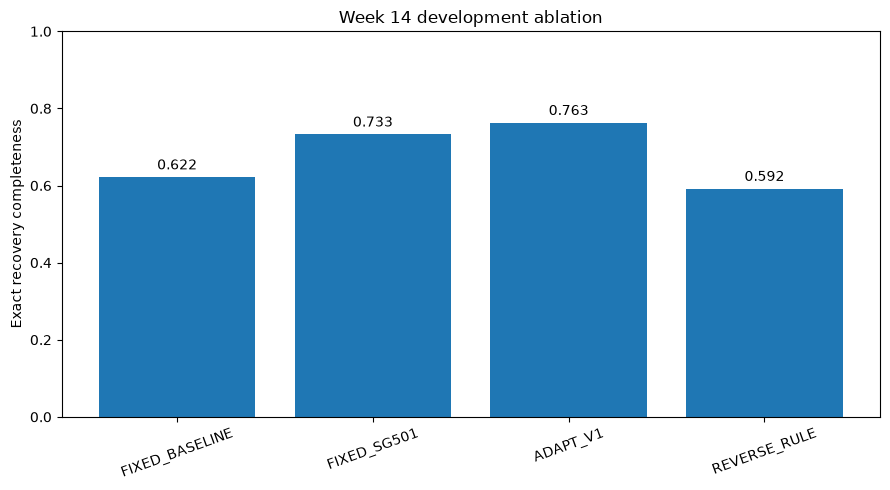

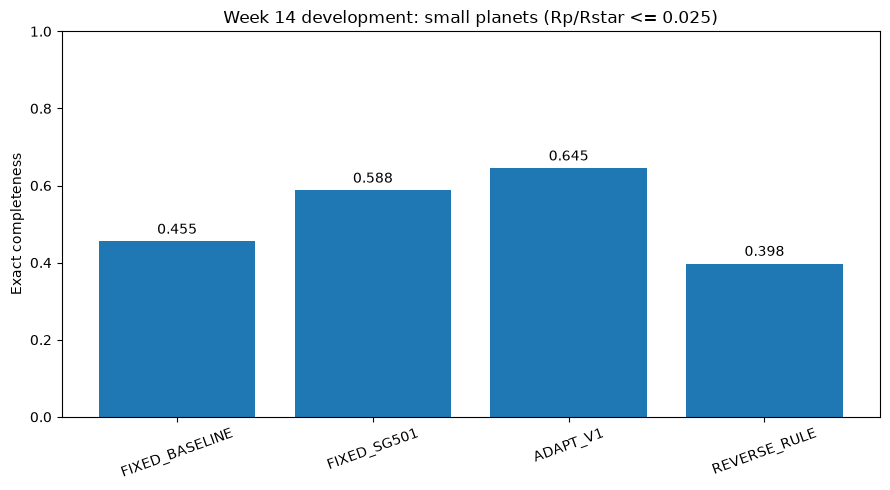


WEEK 14 / ADAPT-v1 DEVELOPMENT RESULTS

ADAPT-v1 HOST CHOICES


,control_id,candidate_name,robust_rms,adapt_v1_method
0,CONTROL-002,HD 102365,0.000101,BASELINE
1,CONTROL-001,18 Sco,0.000194,BASELINE
2,CONTROL-003,HD 76151,0.000239,SG_501
3,CONTROL-004,HD 30495,0.001261,SG_501
4,CONTROL-005,HD 20630,0.009572,SG_501



DEVELOPMENT ABLATION SUMMARY


,method,attempted,exact_recovered,exact_completeness,small_planet_attempted,small_planet_exact_recovered,small_planet_exact_completeness,median_depth_bias_exact,median_apparent_radius_bias_exact,median_small_planet_depth_bias_exact,median_small_planet_radius_bias_exact
0,FIXED_BASELINE,1000,622,0.622,400,182,0.4550,-0.084080,-0.042963,-0.083033,-0.042416
1,FIXED_SG501,1000,733,0.733,400,235,0.5875,-0.385444,-0.216064,-0.380215,-0.212736
2,ADAPT_V1,1000,763,0.763,400,258,0.6450,-0.181065,-0.095050,-0.155453,-0.081008
3,REVERSE_RULE,1000,592,0.592,400,159,0.3975,-0.308270,-0.168297,-0.402128,-0.226778



ADAPT-v1 VS BASELINE RECOVERY SWITCHES


...


CONTROL SUMMARY


,comparison_method,n_controls,median_control_sde,max_control_sde,median_control_depth
0,ADAPT_V1,5,13.891793,17.852602,0.000266
1,FIXED_BASELINE,5,34.695018,144.107001,0.000380
2,FIXED_SG501,5,13.891793,15.222251,0.000266



THRESHOLD ABLATION


,threshold,overall_exact_completeness,small_planet_exact_completeness,n_baseline_hosts,n_sg501_hosts
0,0.000000,0.733,0.5875,0,5
1,0.000140,0.733,0.5875,1,4
2,0.000215,0.763,0.6450,2,3
3,0.000549,0.733,0.5700,3,2
4,0.003475,0.666,0.4550,4,1
5,0.095723,0.622,0.4550,5,0



WEEK 15 PRIMARY DECLARATION
{
  "version": "W15_PRIMARY_V1",
  "primary_metric": "Exact-period recovery completeness for held-out injections with Rp/Rstar <= 0.025",
  "comparison": "ADAPT_V1 minus FIXED_BASELINE",
  "primary_effect": "difference in small-planet exact recovery completeness",
  "success_criterion": "ADAPT_V1 small-planet exact completeness is greater than FIXED_BASELINE on the frozen held-out test.",
  "secondary_metrics": [
    "overall exact completeness",
    "alias-aware completeness",
    "depth bias",
    "apparent radius-ratio bias",
    "no-injection control BLS SDE",
    "runtime"
  ],
  "control_guardrail": "Report paired control BLS SDE. Do not invent a post-hoc binary false-positive threshold.",
  "uncertainty": "Wilson intervals for completeness; host-aware resampling if bootstrap is used.",
  "retuning_after_heldout": false
}

✅ ADAPT-v1 DEFINED
✅ RULE USES ONLY ROBUST RMS
✅ NO INJECTION TRUTH USED
✅ DEVELOPMENT BENCHMARK COMPLETE
✅ FIXED BASELINE ABLATIO

In [29]:
# ============================================================
# WEEK 14
# ADAPT-v1
#
# Goal:
# Build and freeze one simple adaptive preprocessing rule
# using DEVELOPMENT DATA ONLY.
#
# Failure pattern targeted:
# preprocessing performance depends strongly on stellar
# variability.
#
# ADAPT-v1 rule:
#
#   if robust_rms <= 2.15e-4:
#       BASELINE
#   else:
#       SG_501
#
# IMPORTANT:
# - no injected truth is used to choose preprocessing
# - held-out hosts remain untouched
# - all tuning happens only on development hosts
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import json
import os
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REQUIRE FROZEN WEEK 12/13 STATE
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",

    "development_host_data",
    "development_hosts_df",
    "heldout_hosts_df",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:
    raise RuntimeError(
        "Required project state missing:\n"
        f"{missing}"
    )


# ------------------------------------------------------------
# Load corrected Week 12 table if not already in memory
# ------------------------------------------------------------

if "corrected_w12_df" in globals():

    W12_CANONICAL = (
        corrected_w12_df.copy()
    )

elif "week12_results_df" in globals():

    W12_CANONICAL = (
        week12_results_df.copy()
    )

else:

    candidate_paths = [

        RESULTS_DIR
        / "week12_preprocessing_bias"
        / "DET_detrending_results_corrected_radius.csv",

        RESULTS_DIR
        / "week12_preprocessing_bias"
        / "DET_detrending_results.csv",
    ]


    found_path = None

    for path in candidate_paths:

        if path.exists():
            found_path = path
            break


    if found_path is None:

        raise FileNotFoundError(
            "Could not find Week 12 results."
        )


    W12_CANONICAL = pd.read_csv(
        found_path
    )


assert len(
    W12_CANONICAL
) == 4000


# ------------------------------------------------------------
# Check held-out firewall
# ------------------------------------------------------------

assert (
    heldout_hosts_df[
        "bls_run"
    ] == False
).all()

assert (
    heldout_hosts_df[
        "injection_run"
    ] == False
).all()

assert (
    heldout_hosts_df[
        "used_for_tuning"
    ] == False
).all()


print("✅ Week 12 development table found.")
print("✅ 4000 paired method/case rows found.")
print("✅ Held-out firewall intact.")


# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

W14_RESULTS_DIR = (
    RESULTS_DIR
    / "week14_adapt_v1"
)

W14_FIGURES_DIR = (
    FIGURES_DIR
    / "week14_adapt_v1"
)

W14_CONFIG_DIR = (
    CONFIG_DIR
    / "week14_adapt_v1"
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)


for folder in [
    W14_RESULTS_DIR,
    W14_FIGURES_DIR,
    W14_CONFIG_DIR,
    SRC_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 3. DEVELOPMENT HOST TABLE
# ============================================================

host_variability_df = (

    development_hosts_df[
        [
            "control_id",
            "candidate_name",
            "robust_rms",
        ]
    ]

    .copy()

    .sort_values(
        "robust_rms"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nDEVELOPMENT HOST VARIABILITY"
)

display(
    host_variability_df
)


# ============================================================
# 4. ADAPT-v1 THRESHOLD
#
# Development-only threshold.
#
# This sits between:
#   18 Sco      ~1.94e-4
#   HD 76151    ~2.39e-4
#
# where the preferred preprocessing behavior changed.
# ============================================================

ADAPT_V1_RMS_THRESHOLD = (
    2.15e-4
)


def adapt_v1_choose_method(
    robust_rms,
):

    robust_rms = float(
        robust_rms
    )


    if (
        robust_rms
        <=
        ADAPT_V1_RMS_THRESHOLD
    ):

        return "BASELINE"

    else:

        return "SG_501"


print(
    "\nADAPT-v1 rule:"
)

print(
    f"robust_rms <= "
    f"{ADAPT_V1_RMS_THRESHOLD:.3e} "
    f"→ BASELINE"
)

print(
    f"robust_rms > "
    f"{ADAPT_V1_RMS_THRESHOLD:.3e} "
    f"→ SG_501"
)


# ============================================================
# 5. RECORD THE CHOICE FOR EACH DEVELOPMENT HOST
# ============================================================

host_choice_df = (
    host_variability_df.copy()
)


host_choice_df[
    "adapt_v1_method"
] = (

    host_choice_df[
        "robust_rms"
    ]

    .apply(
        adapt_v1_choose_method
    )
)


print(
    "\nADAPT-v1 DEVELOPMENT CHOICES"
)

display(
    host_choice_df
)


host_choice_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_development_host_choices.csv",

    index=False,
)


# ============================================================
# 6. BUILD ADAPT-v1 RESULT TABLE
#
# No searches need rerunning.
#
# We select the already-frozen BASELINE or SG_501 result
# based ONLY on the host's measured robust RMS.
# ============================================================

method_lookup = dict(

    zip(

        host_choice_df[
            "control_id"
        ],

        host_choice_df[
            "adapt_v1_method"
        ],
    )
)


adapt_rows = []


for _, row in W12_CANONICAL.iterrows():

    control_id = str(
        row[
            "control_id"
        ]
    )


    chosen_method = (
        method_lookup[
            control_id
        ]
    )


    if (
        row[
            "method"
        ]
        ==
        chosen_method
    ):

        new_row = (
            row.to_dict()
        )

        new_row[
            "source_method"
        ] = (
            chosen_method
        )

        new_row[
            "method"
        ] = (
            "ADAPT_V1"
        )

        adapt_rows.append(
            new_row
        )


adapt_v1_df = pd.DataFrame(
    adapt_rows
)


assert len(
    adapt_v1_df
) == 1000


assert (
    adapt_v1_df[
        "case_id"
    ].nunique()
    ==
    1000
)


print(
    "✅ ADAPT-v1 development table built:",
    len(
        adapt_v1_df
    ),
)


# ============================================================
# 7. FIXED METHOD TABLES
# ============================================================

baseline_df = (

    W12_CANONICAL[
        W12_CANONICAL[
            "method"
        ]
        ==
        "BASELINE"
    ]

    .copy()
)


sg501_df = (

    W12_CANONICAL[
        W12_CANONICAL[
            "method"
        ]
        ==
        "SG_501"
    ]

    .copy()
)


assert len(
    baseline_df
) == 1000

assert len(
    sg501_df
) == 1000


# ============================================================
# 8. REVERSE-RULE ABLATION
#
# Tests whether variability direction itself matters.
#
# Reverse rule:
# quiet -> SG_501
# noisy -> BASELINE
# ============================================================

def reverse_rule_choose_method(
    robust_rms,
):

    if (
        float(
            robust_rms
        )
        <=
        ADAPT_V1_RMS_THRESHOLD
    ):

        return "SG_501"

    else:

        return "BASELINE"


reverse_lookup = {

    row[
        "control_id"
    ]:
        reverse_rule_choose_method(
            row[
                "robust_rms"
            ]
        )

    for _, row
    in host_choice_df.iterrows()
}


reverse_rows = []


for _, row in W12_CANONICAL.iterrows():

    control_id = str(
        row[
            "control_id"
        ]
    )


    selected = (
        reverse_lookup[
            control_id
        ]
    )


    if (
        row[
            "method"
        ]
        ==
        selected
    ):

        new_row = (
            row.to_dict()
        )

        new_row[
            "source_method"
        ] = (
            selected
        )

        new_row[
            "method"
        ] = (
            "REVERSE_RULE"
        )

        reverse_rows.append(
            new_row
        )


reverse_rule_df = pd.DataFrame(
    reverse_rows
)


assert len(
    reverse_rule_df
) == 1000


# ============================================================
# 9. COMBINE ABLATION METHODS
#
# FIXED_BASELINE
# FIXED_SG501
# ADAPT_V1
# REVERSE_RULE
# ============================================================

baseline_ablation = (
    baseline_df.copy()
)

baseline_ablation[
    "method"
] = (
    "FIXED_BASELINE"
)


sg501_ablation = (
    sg501_df.copy()
)

sg501_ablation[
    "method"
] = (
    "FIXED_SG501"
)


ablation_df = pd.concat(

    [
        baseline_ablation,
        sg501_ablation,
        adapt_v1_df,
        reverse_rule_df,
    ],

    ignore_index=True,
)


assert len(
    ablation_df
) == 4000


# ============================================================
# 10. APPARENT-RADIUS COLUMN FALLBACK
# ============================================================

if (
    "apparent_radius_fractional_error"
    not in ablation_df.columns
):

    ablation_df[
        "true_apparent_rp_over_rstar"
    ] = np.sqrt(

        np.where(

            ablation_df[
                "true_model_depth"
            ]
            >
            0,

            ablation_df[
                "true_model_depth"
            ],

            np.nan,
        )
    )


    ablation_df[
        "recovered_apparent_rp_over_rstar"
    ] = np.sqrt(

        np.where(

            ablation_df[
                "found_depth"
            ]
            >
            0,

            ablation_df[
                "found_depth"
            ],

            np.nan,
        )
    )


    ablation_df[
        "apparent_radius_fractional_error"
    ] = (

        ablation_df[
            "recovered_apparent_rp_over_rstar"
        ]

        -

        ablation_df[
            "true_apparent_rp_over_rstar"
        ]

    ) / (

        ablation_df[
            "true_apparent_rp_over_rstar"
        ]
    )


# ============================================================
# 11. DEVELOPMENT ABLATION SUMMARY
# ============================================================

summary_rows = []


for (
    method_name,
    group
) in ablation_df.groupby(
    "method"
):

    exact = group[
        group[
            "primary_recovered"
        ]
        ==
        True
    ]


    small = group[
        group[
            "true_rp_over_rstar"
        ]
        <=
        0.025
    ]


    small_exact = small[
        small[
            "primary_recovered"
        ]
        ==
        True
    ]


    summary_rows.append({

        "method":
            method_name,

        "attempted":
            len(
                group
            ),

        "exact_recovered":
            int(
                group[
                    "primary_recovered"
                ].sum()
            ),

        "exact_completeness":
            group[
                "primary_recovered"
            ].mean(),

        "small_planet_attempted":
            len(
                small
            ),

        "small_planet_exact_recovered":
            int(
                small[
                    "primary_recovered"
                ].sum()
            ),

        "small_planet_exact_completeness":
            small[
                "primary_recovered"
            ].mean(),

        "median_depth_bias_exact":
            exact[
                "depth_fractional_error"
            ].median(),

        "median_apparent_radius_bias_exact":
            exact[
                "apparent_radius_fractional_error"
            ].median(),

        "median_small_planet_depth_bias_exact":
            small_exact[
                "depth_fractional_error"
            ].median(),

        "median_small_planet_radius_bias_exact":
            small_exact[
                "apparent_radius_fractional_error"
            ].median(),
    })


ablation_summary_df = pd.DataFrame(
    summary_rows
)


METHOD_ORDER_W14 = [
    "FIXED_BASELINE",
    "FIXED_SG501",
    "ADAPT_V1",
    "REVERSE_RULE",
]


ablation_summary_df[
    "_order"
] = (

    ablation_summary_df[
        "method"
    ]

    .map(
        {
            method: index

            for index, method
            in enumerate(
                METHOD_ORDER_W14
            )
        }
    )
)


ablation_summary_df = (

    ablation_summary_df

    .sort_values(
        "_order"
    )

    .drop(
        columns="_order"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nDEVELOPMENT ABLATION SUMMARY"
)

display(
    ablation_summary_df
)


# ============================================================
# 12. HOST-LEVEL ABLATION
# ============================================================

host_ablation_df = (

    ablation_df

    .groupby(
        [
            "method",
            "control_id",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count"
        ),

        exact_recovered=(
            "primary_recovered",
            "sum"
        ),

        exact_completeness=(
            "primary_recovered",
            "mean"
        ),
    )

    .reset_index()

    .merge(

        host_variability_df,

        on="control_id",

        how="left",
    )
)


print(
    "\nHOST-LEVEL ABLATION"
)

display(
    host_ablation_df
)


# ============================================================
# 13. LOAD WEEK 12 NO-INJECTION CONTROLS
# ============================================================

if (
    "week12_controls_df"
    in globals()
):

    w12_controls = (
        week12_controls_df.copy()
    )

else:

    control_path = (

        RESULTS_DIR
        / "week12_preprocessing_bias"
        / "W12_no_injection_controls.csv"
    )


    if not control_path.exists():

        raise FileNotFoundError(
            "Week 12 control table missing."
        )


    w12_controls = pd.read_csv(
        control_path
    )


# ============================================================
# 14. BUILD ADAPT-v1 CONTROL BEHAVIOR
#
# Same rule, same original robust RMS.
# ============================================================

adapt_control_rows = []


for _, row in w12_controls.iterrows():

    control_id = str(
        row[
            "control_id"
        ]
    )


    chosen_method = (
        method_lookup[
            control_id
        ]
    )


    if (
        row[
            "method"
        ]
        ==
        chosen_method
    ):

        new_row = (
            row.to_dict()
        )

        new_row[
            "source_method"
        ] = (
            chosen_method
        )

        new_row[
            "method"
        ] = (
            "ADAPT_V1"
        )

        adapt_control_rows.append(
            new_row
        )


adapt_controls_df = pd.DataFrame(
    adapt_control_rows
)


assert len(
    adapt_controls_df
) == 5


baseline_controls_df = (

    w12_controls[
        w12_controls[
            "method"
        ]
        ==
        "BASELINE"
    ]

    .copy()
)


sg501_controls_df = (

    w12_controls[
        w12_controls[
            "method"
        ]
        ==
        "SG_501"
    ]

    .copy()
)


# ============================================================
# 15. CONTROL SUMMARY
# ============================================================

control_compare_df = pd.concat(

    [
        baseline_controls_df.assign(
            comparison_method="FIXED_BASELINE"
        ),

        sg501_controls_df.assign(
            comparison_method="FIXED_SG501"
        ),

        adapt_controls_df.assign(
            comparison_method="ADAPT_V1"
        ),
    ],

    ignore_index=True,
)


control_summary_df = (

    control_compare_df

    .groupby(
        "comparison_method"
    )

    .agg(

        n_controls=(
            "control_id",
            "count"
        ),

        median_control_sde=(
            "detection_sde",
            "median"
        ),

        max_control_sde=(
            "detection_sde",
            "max"
        ),

        median_control_depth=(
            "found_depth",
            "median"
        ),
    )

    .reset_index()
)


print(
    "\nCONTROL BEHAVIOR"
)

display(
    control_summary_df
)


# ============================================================
# 16. DEVELOPMENT PAIRED SWITCHES
#
# ADAPT-v1 versus baseline.
# ============================================================

baseline_status = (

    baseline_ablation[
        [
            "case_id",
            "primary_recovered",
        ]
    ]

    .rename(
        columns={
            "primary_recovered":
                "baseline_recovered"
        }
    )
)


adapt_status = (

    adapt_v1_df[
        [
            "case_id",
            "primary_recovered",
        ]
    ]

    .rename(
        columns={
            "primary_recovered":
                "adapt_recovered"
        }
    )
)


paired_status = (
    baseline_status.merge(

        adapt_status,

        on="case_id",

        how="inner",
    )
)


adapt_switch_summary_df = pd.DataFrame(
    [
        {

            "baseline_miss_adapt_recovery":
                int(
                    (
                        (~paired_status[
                            "baseline_recovered"
                        ])
                        &
                        (
                            paired_status[
                                "adapt_recovered"
                            ]
                        )
                    ).sum()
                ),

            "baseline_recovery_adapt_miss":
                int(
                    (
                        (
                            paired_status[
                                "baseline_recovered"
                            ]
                        )
                        &
                        (~paired_status[
                            "adapt_recovered"
                        ])
                    ).sum()
                ),

            "both_recovered":
                int(
                    (
                        paired_status[
                            "baseline_recovered"
                        ]
                        &
                        paired_status[
                            "adapt_recovered"
                        ]
                    ).sum()
                ),

            "both_missed":
                int(
                    (
                        (~paired_status[
                            "baseline_recovered"
                        ])
                        &
                        (~paired_status[
                            "adapt_recovered"
                        ])
                    ).sum()
                ),
        }
    ]
)


print(
    "\nADAPT-v1 VS BASELINE SWITCHES"
)

display(
    adapt_switch_summary_df
)


# ============================================================
# 17. SIMPLE THRESHOLD ABLATION
#
# Show what would happen for every split between
# development hosts.
#
# This documents tuning rather than hiding it.
# ============================================================

sorted_rms = np.sort(
    host_variability_df[
        "robust_rms"
    ].to_numpy(
        dtype=float
    )
)


threshold_candidates = [
    0.0
]


for i in range(
    len(
        sorted_rms
    )
    -
    1
):

    threshold_candidates.append(

        float(
            np.sqrt(
                sorted_rms[
                    i
                ]
                *
                sorted_rms[
                    i + 1
                ]
            )
        )
    )


threshold_candidates.append(
    float(
        sorted_rms.max()
        *
        10
    )
)


threshold_rows = []


for threshold in threshold_candidates:

    choice_lookup = {

        row[
            "control_id"
        ]:
            (
                "BASELINE"

                if
                float(
                    row[
                        "robust_rms"
                    ]
                )
                <=
                threshold

                else
                "SG_501"
            )

        for _, row
        in host_variability_df.iterrows()
    }


    selected_rows = []


    for _, row in W12_CANONICAL.iterrows():

        cid = str(
            row[
                "control_id"
            ]
        )


        if (
            row[
                "method"
            ]
            ==
            choice_lookup[
                cid
            ]
        ):

            selected_rows.append(
                row
            )


    selected_df = pd.DataFrame(
        selected_rows
    )


    small_df = (

        selected_df[
            selected_df[
                "true_rp_over_rstar"
            ]
            <=
            0.025
        ]
    )


    threshold_rows.append({

        "threshold":
            threshold,

        "overall_exact_completeness":
            selected_df[
                "primary_recovered"
            ].mean(),

        "small_planet_exact_completeness":
            small_df[
                "primary_recovered"
            ].mean(),

        "n_baseline_hosts":
            sum(
                1

                for method
                in choice_lookup.values()

                if method
                ==
                "BASELINE"
            ),

        "n_sg501_hosts":
            sum(
                1

                for method
                in choice_lookup.values()

                if method
                ==
                "SG_501"
            ),
    })


threshold_ablation_df = pd.DataFrame(
    threshold_rows
)


print(
    "\nTHRESHOLD ABLATION"
)

display(
    threshold_ablation_df
)


# ============================================================
# 18. PREDECLARE WEEK 15 PRIMARY METRIC
#
# Small planets:
# Rp/Rstar <= 0.025
#
# Primary comparison:
# ADAPT-v1 vs frozen baseline exact recovery.
#
# Guardrails:
# control SDE and radius/depth bias remain secondary.
# ============================================================

WEEK15_PRIMARY_DECLARATION = {

    "version":
        "W15_PRIMARY_V1",

    "primary_metric":
        (
            "Exact-period recovery completeness "
            "for held-out injections with "
            "Rp/Rstar <= 0.025"
        ),

    "comparison":
        "ADAPT_V1 minus FIXED_BASELINE",

    "primary_effect":
        (
            "difference in small-planet exact "
            "recovery completeness"
        ),

    "success_criterion":
        (
            "ADAPT_V1 small-planet exact completeness "
            "is greater than FIXED_BASELINE on the "
            "frozen held-out test."
        ),

    "secondary_metrics": [

        "overall exact completeness",

        "alias-aware completeness",

        "depth bias",

        "apparent radius-ratio bias",

        "no-injection control BLS SDE",

        "runtime",
    ],

    "control_guardrail":
        (
            "Report paired control BLS SDE. "
            "Do not invent a post-hoc binary "
            "false-positive threshold."
        ),

    "uncertainty":
        (
            "Wilson intervals for completeness; "
            "host-aware resampling if bootstrap "
            "is used."
        ),

    "retuning_after_heldout":
        False,
}


# ============================================================
# 19. FREEZE WEEK 15 HELD-OUT DESIGN
#
# IMPORTANT:
# We define the plan now.
# We do NOT run it now.
#
# Proposed held-out grid:
#
# 3 held-out hosts
# × 4 periods
# × 5 radii
# × 10 repetitions
# = 600 unique injections
#
# Each case evaluated under:
#   BASELINE
#   ADAPT_V1
# ============================================================

WEEK15_HELDOUT_PLAN = {

    "version":
        "W15_HELDOUT_PLAN_V1",

    "heldout_hosts":
        heldout_hosts_df[
            "heldout_id"
        ].tolist(),

    "periods_days":
        [
            1.0,
            3.0,
            6.0,
            10.0,
        ],

    "rp_over_rstar":
        [
            0.015,
            0.025,
            0.040,
            0.060,
            0.090,
        ],

    "repetitions_per_cell_per_host":
        10,

    "unique_injections":
        600,

    "methods":
        [
            "FIXED_BASELINE",
            "ADAPT_V1",
        ],

    "recovery_protocol":
        "RECOVERY_V2",

    "primary_metric":
        WEEK15_PRIMARY_DECLARATION[
            "primary_metric"
        ],

    "success_criterion":
        WEEK15_PRIMARY_DECLARATION[
            "success_criterion"
        ],

    "retuning_allowed":
        False,
}


# ============================================================
# 20. WRITE ADAPT-v1 IMPLEMENTATION FILE
# ============================================================

preprocess_py = f'''
"""
ADAPT-v1
Frozen Week 14 adaptive preprocessing rule.

This function uses only measured host variability.
It does not use injected planet truth.
"""

ADAPT_V1_RMS_THRESHOLD = {ADAPT_V1_RMS_THRESHOLD!r}


def adapt_v1_choose_method(robust_rms):
    robust_rms = float(robust_rms)

    if robust_rms <= ADAPT_V1_RMS_THRESHOLD:
        return "BASELINE"

    return "SG_501"
'''


PREPROCESS_PATH = (
    SRC_DIR
    / "preprocess.py"
)


PREPROCESS_PATH.write_text(
    preprocess_py,
    encoding="utf-8",
)


# ============================================================
# 21. TEST ADAPT-v1 IMPLEMENTATION
# ============================================================

assert (
    adapt_v1_choose_method(
        1e-4
    )
    ==
    "BASELINE"
)

assert (
    adapt_v1_choose_method(
        2e-4
    )
    ==
    "BASELINE"
)

assert (
    adapt_v1_choose_method(
        3e-4
    )
    ==
    "SG_501"
)

assert (
    adapt_v1_choose_method(
        1e-2
    )
    ==
    "SG_501"
)


print(
    "✅ ADAPT-v1 unit tests passed."
)


# ============================================================
# 22. METHOD NOTE
# ============================================================

METHOD_NOTE = f"""
ADAPT-v1 METHOD NOTE
====================

Targeted failure pattern
------------------------
Weeks 11-12 showed strong host-dependent recovery.
Quiet hosts could perform very well without detrending,
while more variable hosts benefited substantially from
long-window Savitzky-Golay detrending.

Adaptive input
--------------
Robust RMS of the original development light curve.

No injected period, depth, radius, epoch, or recovery
outcome is available to the rule.

Frozen rule
-----------
If robust_rms <= {ADAPT_V1_RMS_THRESHOLD:.6g}:
    use BASELINE preprocessing
Else:
    use SG_501 preprocessing

Search method
-------------
Frozen BLS search and RECOVERY_V2.

Development tuning
------------------
The threshold was selected using development hosts only.
Held-out hosts were not opened or searched during tuning.

Ablations
---------
1. Fixed baseline
2. Fixed SG_501
3. ADAPT-v1
4. Reverse variability rule

Week 15 primary metric
----------------------
Exact-period recovery completeness for held-out
small-planet injections with Rp/Rstar <= 0.025.

Success criterion
-----------------
ADAPT-v1 must exceed fixed baseline on the frozen
held-out small-planet completeness metric.

No retuning is allowed after held-out results are opened.
"""


METHOD_NOTE_PATH = (

    W14_RESULTS_DIR
    / "ADAPT_V1_method_note.txt"
)


METHOD_NOTE_PATH.write_text(
    METHOD_NOTE,
    encoding="utf-8",
)


# ============================================================
# 23. SAVE ALL DEVELOPMENT TABLES
# ============================================================

adapt_v1_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_development_results.csv",

    index=False,
)


ablation_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_ablation_results.csv",

    index=False,
)


ablation_summary_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_ablation_summary.csv",

    index=False,
)


host_ablation_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_host_ablation.csv",

    index=False,
)


adapt_switch_summary_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_recovery_switches.csv",

    index=False,
)


control_summary_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_control_summary.csv",

    index=False,
)


threshold_ablation_df.to_csv(

    W14_RESULTS_DIR
    / "ADAPT_V1_threshold_ablation.csv",

    index=False,
)


# ============================================================
# 24. SAVE FROZEN CONFIGS
# ============================================================

ADAPT_V1_CONFIG = {

    "version":
        "ADAPT_V1",

    "adaptive_input":
        "robust_rms",

    "threshold":
        ADAPT_V1_RMS_THRESHOLD,

    "quiet_method":
        "BASELINE",

    "variable_method":
        "SG_501",

    "search_method":
        "BLS",

    "recovery_protocol":
        "RECOVERY_V2",

    "uses_injection_truth":
        False,

    "development_hosts_only":
        True,

    "heldout_hosts_used":
        False,
}


with open(

    W14_CONFIG_DIR
    / "ADAPT_V1_config.json",

    "w",

) as f:

    json.dump(
        ADAPT_V1_CONFIG,
        f,
        indent=2,
    )


with open(

    W14_CONFIG_DIR
    / "W15_PRIMARY_V1.json",

    "w",

) as f:

    json.dump(
        WEEK15_PRIMARY_DECLARATION,
        f,
        indent=2,
    )


with open(

    W14_CONFIG_DIR
    / "W15_HELDOUT_PLAN_V1.json",

    "w",

) as f:

    json.dump(
        WEEK15_HELDOUT_PLAN,
        f,
        indent=2,
    )


# ============================================================
# 25. CREATE FILE HASHES
#
# This gives us a lightweight freeze fingerprint.
# ============================================================

def sha256_file(
    path,
):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b"",
        ):

            h.update(
                block
            )

    return (
        h.hexdigest()
    )


PREPROCESS_HASH = (
    sha256_file(
        PREPROCESS_PATH
    )
)


CONFIG_HASH = (
    sha256_file(

        W14_CONFIG_DIR
        / "ADAPT_V1_config.json"
    )
)


# ============================================================
# 26. FREEZE MANIFEST
# ============================================================

FREEZE_MANIFEST = {

    "version":
        "ADAPT_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "threshold":
        ADAPT_V1_RMS_THRESHOLD,

    "input":
        "robust_rms",

    "quiet_method":
        "BASELINE",

    "variable_method":
        "SG_501",

    "search_method":
        "BLS",

    "recovery_protocol":
        "RECOVERY_V2",

    "preprocess_file":
        str(
            PREPROCESS_PATH
        ),

    "preprocess_sha256":
        PREPROCESS_HASH,

    "config_sha256":
        CONFIG_HASH,

    "primary_metric":
        WEEK15_PRIMARY_DECLARATION[
            "primary_metric"
        ],

    "success_criterion":
        WEEK15_PRIMARY_DECLARATION[
            "success_criterion"
        ],

    "heldout_plan":
        WEEK15_HELDOUT_PLAN,

    "heldout_hosts_used":
        False,

    "retuning_after_heldout":
        False,
}


with open(

    W14_CONFIG_DIR
    / "ADAPT_V1_FREEZE_MANIFEST.json",

    "w",

) as f:

    json.dump(
        FREEZE_MANIFEST,
        f,
        indent=2,
    )


# ============================================================
# 27. FIGURE — DEVELOPMENT COMPLETENESS
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.bar(

    ablation_summary_df[
        "method"
    ],

    ablation_summary_df[
        "exact_completeness"
    ],
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_title(
    "Week 14 development ablation"
)


for i, row in (
    ablation_summary_df.iterrows()
):

    ax.text(

        i,

        row[
            "exact_completeness"
        ]
        +
        0.02,

        f"{row['exact_completeness']:.3f}",

        ha="center",
    )


plt.xticks(
    rotation=20
)


fig.tight_layout()


fig.savefig(

    W14_FIGURES_DIR
    / "ADAPT_V1_ablation_completeness.png",

    dpi=220,
)


plt.show()


# ============================================================
# 28. FIGURE — SMALL PLANET COMPLETENESS
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)


ax.bar(

    ablation_summary_df[
        "method"
    ],

    ablation_summary_df[
        "small_planet_exact_completeness"
    ],
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Exact completeness"
)


ax.set_title(
    "Week 14 development: small planets (Rp/Rstar <= 0.025)"
)


for i, row in (
    ablation_summary_df.iterrows()
):

    ax.text(

        i,

        row[
            "small_planet_exact_completeness"
        ]
        +
        0.02,

        f"{row['small_planet_exact_completeness']:.3f}",

        ha="center",
    )


plt.xticks(
    rotation=20
)


fig.tight_layout()


fig.savefig(

    W14_FIGURES_DIR
    / "ADAPT_V1_small_planet_completeness.png",

    dpi=220,
)


plt.show()


# ============================================================
# 29. FINAL OUTPUT
# ============================================================

print()
print("=" * 72)
print("WEEK 14 / ADAPT-v1 DEVELOPMENT RESULTS")
print("=" * 72)


print(
    "\nADAPT-v1 HOST CHOICES"
)

display(
    host_choice_df
)


print(
    "\nDEVELOPMENT ABLATION SUMMARY"
)

display(
    ablation_summary_df
)


print(
    "\nADAPT-v1 VS BASELINE RECOVERY SWITCHES"
)

display(
    adapt_switch_summary_df
)


print(
    "\nCONTROL SUMMARY"
)

display(
    control_summary_df
)


print(
    "\nTHRESHOLD ABLATION"
)

display(
    threshold_ablation_df
)


print(
    "\nWEEK 15 PRIMARY DECLARATION"
)

print(
    json.dumps(
        WEEK15_PRIMARY_DECLARATION,
        indent=2,
    )
)


print()
print("=" * 72)
print("✅ ADAPT-v1 DEFINED")
print("✅ RULE USES ONLY ROBUST RMS")
print("✅ NO INJECTION TRUTH USED")
print("✅ DEVELOPMENT BENCHMARK COMPLETE")
print("✅ FIXED BASELINE ABLATION COMPLETE")
print("✅ FIXED SG_501 ABLATION COMPLETE")
print("✅ REVERSE-RULE ABLATION COMPLETE")
print("✅ CONTROL BEHAVIOR RECORDED")
print("✅ WEEK 15 PRIMARY METRIC PREDECLARED")
print("✅ WEEK 15 HELD-OUT PLAN PREDECLARED")
print("✅ src/preprocess.py WRITTEN")
print("✅ ADAPT-v1 CONFIG HASHED")
print("✅ HELD-OUT HOSTS REMAIN UNTOUCHED")
print("✅ ADAPT-v1 FROZEN")
print("=" * 72)

In [37]:
# ============================================================
# DIRECT MAST DOWNLOAD HELPER FOR HELD-OUT HOSTS
# Bypasses hanging Lightkurve download path
# ============================================================

from pathlib import Path
import requests
from astropy.io import fits
import numpy as np
import pandas as pd
from astroquery.mast import Observations

DIRECT_CACHE_DIR = (
    RESULTS_DIR
    / "week15_heldout"
    / "direct_mast_cache"
)

DIRECT_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def direct_spoc_download(
    target,
    sector,
    heldout_id,
):
    print(
        f"Searching MAST product for {target}, Sector {sector}..."
    )

    obs = Observations.query_criteria(
        target_name=target,
        obs_collection="TESS",
        sequence_number=int(sector),
        dataproduct_type="timeseries",
    )

    if len(obs) == 0:
        raise RuntimeError(
            f"No TESS observations found for {target}, Sector {sector}"
        )

    products = Observations.get_product_list(obs)

    products = products[
        np.char.find(
            products["productFilename"].astype(str),
            "-lc.fits"
        ) >= 0
    ]

    products = products[
        np.char.find(
            products["productFilename"].astype(str),
            "fast"
        ) >= 0
    ]

    if len(products) == 0:
        raise RuntimeError(
            f"No SPOC light-curve FITS product found for {target}, Sector {sector}"
        )

    # Prefer exact sector-matched LC product
    product = products[0]

    data_uri = str(
        product["dataURI"]
    )

    filename = str(
        product["productFilename"]
    )

    local_path = (
        DIRECT_CACHE_DIR
        / f"{heldout_id}_{filename}"
    )

    if not local_path.exists():

        url = (
            "https://mast.stsci.edu/api/v0.1/Download/file"
            f"?uri={data_uri}"
        )

        print(
            "Downloading directly from MAST..."
        )

        with requests.get(
            url,
            stream=True,
            timeout=(20, 120),
        ) as response:

            response.raise_for_status()

            total = int(
                response.headers.get(
                    "content-length",
                    0,
                )
            )

            downloaded = 0

            with open(
                local_path,
                "wb",
            ) as f:

                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):

                    if not chunk:
                        continue

                    f.write(
                        chunk
                    )

                    downloaded += len(
                        chunk
                    )

                    if total > 0:
                        pct = 100 * downloaded / total
                        print(
                            f"\rDownloaded {pct:5.1f}%",
                            end=""
                        )

        print()

        print(
            "✅ Direct MAST download complete:",
            local_path
        )

    else:

        print(
            "✅ Using locally cached direct MAST file:",
            local_path
        )

    # Validate FITS before using it
    with fits.open(
        local_path,
        memmap=False,
    ) as hdul:

        data = hdul[1].data

        time_values = np.asarray(
            data["TIME"],
            dtype=float,
        )

        # Prefer PDCSAP, same as earlier project logic
        if "PDCSAP_FLUX" in data.columns.names:

            flux_values = np.asarray(
                data["PDCSAP_FLUX"],
                dtype=float,
            )

        else:

            flux_values = np.asarray(
                data["SAP_FLUX"],
                dtype=float,
            )

        quality = np.asarray(
            data["QUALITY"],
            dtype=int,
        )

    good = (
        np.isfinite(time_values)
        &
        np.isfinite(flux_values)
        &
        (quality == 0)
    )

    time_values = time_values[
        good
    ]

    flux_values = flux_values[
        good
    ]

    flux_values = (
        flux_values
        /
        np.nanmedian(flux_values)
    )

    return {
        "time": time_values,
        "flux": flux_values,
    }


print("✅ Direct MAST helper ready.")

✅ Direct MAST helper ready.


✅ Network timeout: 120 seconds
✅ Network retry attempts: 5
✅ Required project state found.
✅ Frozen ADAPT-v1 config loaded.
✅ Frozen Week 15 metric loaded.
✅ Frozen held-out plan loaded.
✅ ADAPT-v1 source hash verified.
✅ ADAPT-v1 config hash verified.

FROZEN ADAPT-v1:
RMS <= 2.150e-04 → BASELINE
RMS >  2.150e-04 → SG_501
✅ Existing held-out opening event preserved.

Opening held-out host: HELDOUT-001 | HD 190406
   ✅ Loading cached processed light curve: HELDOUT-001_sector_54_processed.npz
   ✅ Loading cached TIC metadata.

Opening held-out host: HELDOUT-002 | HD 38858
   Searching MAST for TIC 176521059, Sector 6...
   MAST observation query TIC 176521059 [attempt 1/5]
   ⚠️ MAST observation query TIC 176521059 failed:
       ConnectionError(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')))
   Retrying in 5 seconds...
   MAST observation query TIC 176521059 [attempt 2/5]
   ✅ MAST observation query TIC 176521059 completed in 0

,heldout_id,candidate_name,tic_id,sector,stellar_mass_msun,stellar_radius_rsun,teff_kelvin,robust_rms,cadence_minutes,adapt_v1_method
0,HELDOUT-001,HD 190406,275240386,54,1.08,1.066600,5940.0,0.000317,0.333339,SG_501
1,HELDOUT-002,HD 38858,176521059,6,1.02,0.921079,5735.0,0.000125,1.999975,BASELINE
2,HELDOUT-003,HD 10307,327507922,18,1.06,1.184120,5870.0,0.000163,1.999964,BASELINE



ADAPT-v1 HELD-OUT CHOICES


,heldout_id,candidate_name,robust_rms,adapt_v1_method
0,HELDOUT-001,HD 190406,0.000317,SG_501
1,HELDOUT-002,HD 38858,0.000125,BASELINE
2,HELDOUT-003,HD 10307,0.000163,BASELINE



BUILDING HELD-OUT BLS GRIDS
HELDOUT-001 | points: 104096 | trial periods: 31926
HELDOUT-002 | points: 14677 | trial periods: 21995
HELDOUT-003 | points: 15154 | trial periods: 25953
✅ Held-out BLS grids ready.

✅ Frozen held-out design: 600 injections

CPU cores: 16
Week 15 workers: 4
Checkpoint chunk: 8

Already completed: 0 / 600
Pending: 600
Checkpoint: 8/600 cases | 16/1200 rows | elapsed 0.7 min
Checkpoint: 16/600 cases | 32/1200 rows | elapsed 1.5 min
Checkpoint: 24/600 cases | 48/1200 rows | elapsed 2.3 min
Checkpoint: 32/600 cases | 64/1200 rows | elapsed 3.3 min
Checkpoint: 40/600 cases | 80/1200 rows | elapsed 4.1 min
Checkpoint: 48/600 cases | 96/1200 rows | elapsed 5.0 min
Checkpoint: 56/600 cases | 112/1200 rows | elapsed 5.8 min
Checkpoint: 64/600 cases | 128/1200 rows | elapsed 6.6 min
Checkpoint: 72/600 cases | 144/1200 rows | elapsed 7.5 min
Checkpoint: 80/600 cases | 160/1200 rows | elapsed 8.4 min
Checkpoint: 88/600 cases | 176/1200 rows | elapsed 9.3 min
Checkpoint

...

,method,recovery_category,count,fraction
0,ADAPT_V1,DOUBLE_ALIAS,3,0.005000
1,ADAPT_V1,EXACT,554,0.923333
2,ADAPT_V1,MISS,38,0.063333
3,ADAPT_V1,NEAR_MATCH,5,0.008333
4,FIXED_BASELINE,DOUBLE_ALIAS,2,0.003333
5,FIXED_BASELINE,EXACT,534,0.890000
6,FIXED_BASELINE,HALF_ALIAS,1,0.001667
7,FIXED_BASELINE,MISS,61,0.101667
8,FIXED_BASELINE,NEAR_MATCH,2,0.003333



HELD-OUT NO-INJECTION CONTROL BEHAVIOR


,heldout_id,method,source_preprocessing,found_period_days,detection_sde,found_depth
0,HELDOUT-001,FIXED_BASELINE,BASELINE,4.589344,53.733970,0.000248
1,HELDOUT-001,ADAPT_V1,SG_501,1.006518,7.833068,0.000012
2,HELDOUT-002,FIXED_BASELINE,BASELINE,6.916502,17.265519,0.000074
3,HELDOUT-002,ADAPT_V1,BASELINE,6.916502,17.265519,0.000074
4,HELDOUT-003,FIXED_BASELINE,BASELINE,11.429710,11.500354,0.000424
5,HELDOUT-003,ADAPT_V1,BASELINE,11.429710,11.500354,0.000424



HELD-OUT CONTROL SUMMARY


,method,n_hosts,median_control_sde,max_control_sde,median_control_depth
0,ADAPT_V1,3,11.500354,17.265519,0.000074
1,FIXED_BASELINE,3,17.265519,53.733970,0.000248


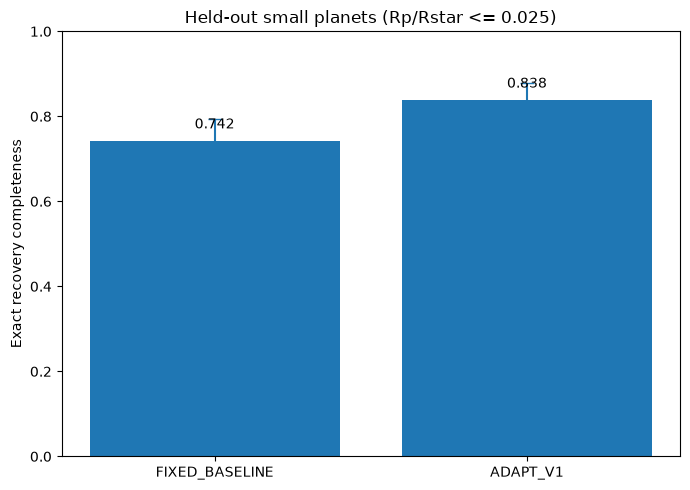

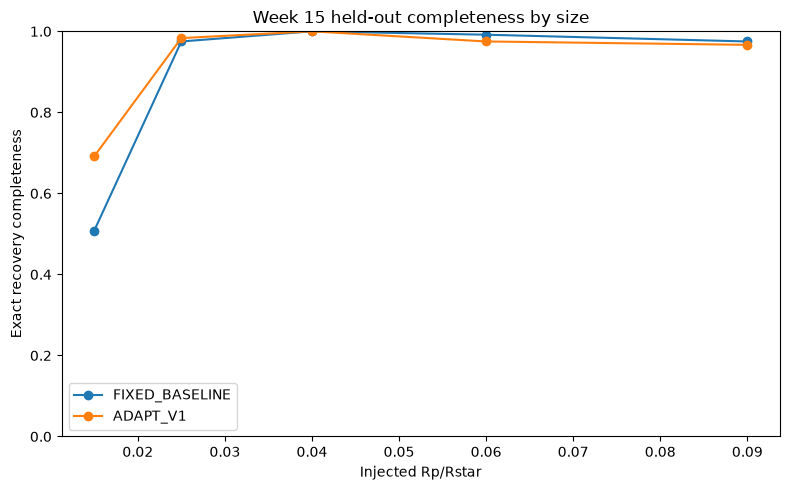


WEEK 15 FROZEN HELD-OUT RESULT

HELD-OUT HOST CHOICES


,heldout_id,candidate_name,robust_rms,adapt_v1_method
0,HELDOUT-001,HD 190406,0.000317,SG_501
1,HELDOUT-002,HD 38858,0.000125,BASELINE
2,HELDOUT-003,HD 10307,0.000163,BASELINE



PRIMARY METRIC


,method,attempted,exact_recovered,exact_completeness,ci95_low,ci95_high
0,ADAPT_V1,240,201,0.837500,0.785575,0.878791
1,FIXED_BASELINE,240,178,0.741667,0.682788,0.792931



PRIMARY PAIRED SWITCHES


...


ALIAS TABLE


,method,recovery_category,count,fraction
0,ADAPT_V1,DOUBLE_ALIAS,3,0.005000
1,ADAPT_V1,EXACT,554,0.923333
2,ADAPT_V1,MISS,38,0.063333
3,ADAPT_V1,NEAR_MATCH,5,0.008333
4,FIXED_BASELINE,DOUBLE_ALIAS,2,0.003333
5,FIXED_BASELINE,EXACT,534,0.890000
6,FIXED_BASELINE,HALF_ALIAS,1,0.001667
7,FIXED_BASELINE,MISS,61,0.101667
8,FIXED_BASELINE,NEAR_MATCH,2,0.003333



HELD-OUT CONTROL SUMMARY


,method,n_hosts,median_control_sde,max_control_sde,median_control_depth
0,ADAPT_V1,3,11.500354,17.265519,0.000074
1,FIXED_BASELINE,3,17.265519,53.733970,0.000248



✅ WEEK 15 HELD-OUT TEST COMPLETE
✅ ADAPT-v1 HASH VERIFIED
✅ PRIMARY METRIC PREDECLARED
✅ OLD + NEW SPOC LC FILENAMES SUPPORTED
✅ DIRECT MAST DOWNLOAD USED
✅ FITS FILES VALIDATED
✅ REMOTE DATA CACHED
✅ 600 HELD-OUT INJECTIONS
✅ 1200 PAIRED METHOD ROWS
✅ HOST-AWARE UNCERTAINTY REPORTED
✅ DEPTH / RADIUS BIAS REPORTED
✅ ALIAS BEHAVIOR REPORTED
✅ NO-INJECTION CONTROLS REPORTED
✅ FINAL RESULT FROZEN
✅ NO RETUNING ALLOWED


In [39]:
# ============================================================
# WEEK 15
# FINAL HELD-OUT EVALUATION
#
# DIRECT MAST DOWNLOAD
# ROBUST OLD/NEW SPOC FILE MATCHING
# LOCAL CACHE
# RETRY SUPPORT
# CHECKPOINT / RESUME
#
# FIXED_BASELINE vs FROZEN ADAPT_V1
#
# SCIENTIFIC PROTOCOL IS UNCHANGED
#
# 3 held-out hosts
# × 4 periods
# × 5 Rp/Rstar values
# × 10 repetitions
# = 600 unique injections
#
# Each injection evaluated with:
#   FIXED_BASELINE
#   ADAPT_V1
#
# Primary metric:
# exact-period recovery for Rp/Rstar <= 0.025
#
# NO RETUNING AFTER HELD-OUT OPENING.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import json
import os
import socket
import time

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from joblib import Parallel, delayed

from astroquery.mast import Observations, Catalogs
from astropy.io import fits
from astropy.utils import data as astropy_data


# ============================================================
# 1. NETWORK SETTINGS
# ============================================================

NETWORK_TIMEOUT_SECONDS = 120
NETWORK_MAX_ATTEMPTS = 5


socket.setdefaulttimeout(
    NETWORK_TIMEOUT_SECONDS
)


try:
    astropy_data.conf.remote_timeout = (
        NETWORK_TIMEOUT_SECONDS
    )
except Exception:
    pass


try:
    Observations.TIMEOUT = (
        NETWORK_TIMEOUT_SECONDS
    )
except Exception:
    pass


try:
    Catalogs.TIMEOUT = (
        NETWORK_TIMEOUT_SECONDS
    )
except Exception:
    pass


print(
    "✅ Network timeout:",
    NETWORK_TIMEOUT_SECONDS,
    "seconds"
)

print(
    "✅ Network retry attempts:",
    NETWORK_MAX_ATTEMPTS
)


# ============================================================
# 2. REQUIRE PROJECT STATE
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",

    "heldout_hosts_df",

    "inject_transit",
    "blind_bls_search",
    "build_period_grid",
    "evaluate_recovery_v2",
    "BLS_CONFIG",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Required project state missing:\n"
        f"{missing}\n\n"
        "Run the notebook through Week 14 first."
    )


print(
    "✅ Required project state found."
)


# ============================================================
# 3. LOAD FROZEN WEEK 14 FILES
# ============================================================

W14_CONFIG_DIR = (
    CONFIG_DIR
    / "week14_adapt_v1"
)


ADAPT_CONFIG_PATH = (
    W14_CONFIG_DIR
    / "ADAPT_V1_config.json"
)


ADAPT_FREEZE_PATH = (
    W14_CONFIG_DIR
    / "ADAPT_V1_FREEZE_MANIFEST.json"
)


W15_PRIMARY_PATH = (
    W14_CONFIG_DIR
    / "W15_PRIMARY_V1.json"
)


W15_PLAN_PATH = (
    W14_CONFIG_DIR
    / "W15_HELDOUT_PLAN_V1.json"
)


PREPROCESS_PATH = (
    PROJECT_ROOT
    / "src"
    / "preprocess.py"
)


for path in [
    ADAPT_CONFIG_PATH,
    ADAPT_FREEZE_PATH,
    W15_PRIMARY_PATH,
    W15_PLAN_PATH,
    PREPROCESS_PATH,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Frozen Week 14 file missing:\n{path}"
        )


with open(
    ADAPT_CONFIG_PATH,
    "r",
) as f:

    ADAPT_CONFIG = json.load(
        f
    )


with open(
    ADAPT_FREEZE_PATH,
    "r",
) as f:

    ADAPT_FREEZE = json.load(
        f
    )


with open(
    W15_PRIMARY_PATH,
    "r",
) as f:

    W15_PRIMARY = json.load(
        f
    )


with open(
    W15_PLAN_PATH,
    "r",
) as f:

    W15_PLAN = json.load(
        f
    )


print(
    "✅ Frozen ADAPT-v1 config loaded."
)

print(
    "✅ Frozen Week 15 metric loaded."
)

print(
    "✅ Frozen held-out plan loaded."
)


# ============================================================
# 4. VERIFY FROZEN HASHES
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b"",
        ):
            h.update(
                block
            )

    return h.hexdigest()


current_preprocess_hash = (
    sha256_file(
        PREPROCESS_PATH
    )
)


current_config_hash = (
    sha256_file(
        ADAPT_CONFIG_PATH
    )
)


if (
    current_preprocess_hash
    !=
    ADAPT_FREEZE[
        "preprocess_sha256"
    ]
):

    raise RuntimeError(
        "STOP: src/preprocess.py changed "
        "after ADAPT-v1 freeze."
    )


if (
    current_config_hash
    !=
    ADAPT_FREEZE[
        "config_sha256"
    ]
):

    raise RuntimeError(
        "STOP: ADAPT_V1_config.json changed "
        "after ADAPT-v1 freeze."
    )


print(
    "✅ ADAPT-v1 source hash verified."
)

print(
    "✅ ADAPT-v1 config hash verified."
)


# ============================================================
# 5. FROZEN ADAPT-v1 RULE
# ============================================================

ADAPT_V1_RMS_THRESHOLD = float(
    ADAPT_CONFIG[
        "threshold"
    ]
)


assert (
    ADAPT_CONFIG[
        "quiet_method"
    ]
    ==
    "BASELINE"
)


assert (
    ADAPT_CONFIG[
        "variable_method"
    ]
    ==
    "SG_501"
)


def adapt_v1_choose_method(
    robust_rms,
):

    robust_rms = float(
        robust_rms
    )


    if (
        robust_rms
        <=
        ADAPT_V1_RMS_THRESHOLD
    ):

        return "BASELINE"


    return "SG_501"


print()
print(
    "FROZEN ADAPT-v1:"
)

print(
    f"RMS <= {ADAPT_V1_RMS_THRESHOLD:.3e}"
    " → BASELINE"
)

print(
    f"RMS >  {ADAPT_V1_RMS_THRESHOLD:.3e}"
    " → SG_501"
)


# ============================================================
# 6. DIRECTORIES
# ============================================================

W15_RESULTS_DIR = (
    RESULTS_DIR
    / "week15_heldout"
)


W15_FIGURES_DIR = (
    FIGURES_DIR
    / "week15_heldout"
)


W15_CONFIG_DIR = (
    CONFIG_DIR
    / "week15_heldout"
)


DIRECT_CACHE_DIR = (
    W15_RESULTS_DIR
    / "direct_mast_cache"
)


for folder in [
    W15_RESULTS_DIR,
    W15_FIGURES_DIR,
    W15_CONFIG_DIR,
    DIRECT_CACHE_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 7. PRESERVE HELD-OUT OPEN EVENT
# ============================================================

HELDOUT_OPEN_EVENT_PATH = (
    W15_CONFIG_DIR
    / "HELDOUT_OPEN_EVENT.json"
)


if not HELDOUT_OPEN_EVENT_PATH.exists():

    open_event = {

        "event":
            "HELDOUT_OPENED",

        "opened_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "adapt_version":
            "ADAPT_V1",

        "adapt_threshold":
            ADAPT_V1_RMS_THRESHOLD,

        "preprocess_sha256":
            current_preprocess_hash,

        "config_sha256":
            current_config_hash,

        "primary_metric":
            W15_PRIMARY[
                "primary_metric"
            ],

        "success_criterion":
            W15_PRIMARY[
                "success_criterion"
            ],

        "retuning_allowed":
            False,
    }


    with open(
        HELDOUT_OPEN_EVENT_PATH,
        "w",
    ) as f:

        json.dump(
            open_event,
            f,
            indent=2,
        )


    print(
        "✅ Held-out opening event recorded."
    )

else:

    print(
        "✅ Existing held-out opening event preserved."
    )


# ============================================================
# 8. REMOTE RETRY HELPER
# ============================================================

def retry_remote_call(
    function,
    label,
    max_attempts=NETWORK_MAX_ATTEMPTS,
):

    last_error = None


    for attempt in range(
        1,
        max_attempts + 1,
    ):

        try:

            print(
                f"   {label} "
                f"[attempt {attempt}/{max_attempts}]"
            )


            start = time.perf_counter()


            result = function()


            elapsed = (
                time.perf_counter()
                -
                start
            )


            print(
                f"   ✅ {label} completed "
                f"in {elapsed:.1f} s"
            )


            return result


        except Exception as error:

            last_error = error


            print(
                f"   ⚠️ {label} failed:"
            )

            print(
                "      ",
                repr(
                    error
                )
            )


            if (
                attempt
                <
                max_attempts
            ):

                wait_seconds = min(
                    5
                    *
                    (
                        2
                        **
                        (
                            attempt
                            -
                            1
                        )
                    ),
                    40,
                )


                print(
                    f"   Retrying in "
                    f"{wait_seconds} seconds..."
                )


                time.sleep(
                    wait_seconds
                )


    raise RuntimeError(
        f"{label} failed after "
        f"{max_attempts} attempts."
    ) from last_error


# ============================================================
# 9. SAFE FLOAT
# ============================================================

def safe_float(value):

    try:

        value = float(
            value
        )

    except Exception:

        return np.nan


    if not np.isfinite(
        value
    ):

        return np.nan


    return value


# ============================================================
# 10. ROBUST RMS
# ============================================================

def w15_robust_sigma(values):

    values = np.asarray(
        values,
        dtype=float,
    )


    median = np.nanmedian(
        values
    )


    mad = np.nanmedian(

        np.abs(
            values
            -
            median
        )
    )


    return float(
        1.4826
        *
        mad
    )


# ============================================================
# 11. DIRECT SPOC / MAST DOWNLOAD
#
# IMPORTANT FIX:
# Accepts old and new LC filename conventions:
#
#   *_lc.fits
#   *-lc.fits
#
# More generally, any product ending in:
#
#   lc.fits
#
# while excluding TPF products.
# ============================================================

def direct_spoc_download(
    target,
    tic_id,
    sector,
    heldout_id,
):

    processed_cache = (

        DIRECT_CACHE_DIR
        /
        f"{heldout_id}_sector_{sector}_processed.npz"
    )


    # ========================================================
    # A. LOAD ALREADY-PROCESSED CACHE
    # ========================================================

    if processed_cache.exists():

        print(
            "   ✅ Loading cached processed light curve:",
            processed_cache.name
        )


        cached = np.load(
            processed_cache
        )


        return {

            "time":
                np.asarray(
                    cached[
                        "time"
                    ],
                    dtype=float,
                ),

            "flux":
                np.asarray(
                    cached[
                        "flux"
                    ],
                    dtype=float,
                ),
        }


    # ========================================================
    # B. QUERY MAST OBSERVATIONS
    # ========================================================

    print(
        f"   Searching MAST for TIC {tic_id}, "
        f"Sector {sector}..."
    )


    observations = retry_remote_call(

        lambda:
            Observations.query_criteria(

                obs_collection="TESS",

                target_name=str(
                    tic_id
                ),

                sequence_number=int(
                    sector
                ),
            ),

        label=(
            f"MAST observation query "
            f"TIC {tic_id}"
        ),
    )


    # ========================================================
    # C. FALLBACK SEARCH BY STAR NAME
    # ========================================================

    if len(
        observations
    ) == 0:

        observations = retry_remote_call(

            lambda:
                Observations.query_criteria(

                    obs_collection="TESS",

                    target_name=str(
                        target
                    ),

                    sequence_number=int(
                        sector
                    ),
                ),

            label=(
                f"MAST fallback query "
                f"{target}"
            ),
        )


    if len(
        observations
    ) == 0:

        raise RuntimeError(
            f"No TESS observations found for "
            f"{target} / TIC {tic_id}, "
            f"Sector {sector}."
        )


    # ========================================================
    # D. GET PRODUCT LIST
    # ========================================================

    products = retry_remote_call(

        lambda:
            Observations.get_product_list(
                observations
            ),

        label=(
            f"MAST product list "
            f"{target}"
        ),
    )


    # ========================================================
    # E. ROBUST LIGHT-CURVE PRODUCT MATCHING
    #
    # Handles:
    #   ..._lc.fits
    #   ...-lc.fits
    #   older/newer naming conventions
    #
    # Explicitly excludes TPF products.
    # ========================================================

    candidate_indices = []


    for i in range(
        len(
            products
        )
    ):

        filename = str(
            products[
                i
            ][
                "productFilename"
            ]
        )


        lower_name = (
            filename.lower()
        )


        subgroup = ""

        try:
            subgroup = str(
                products[
                    i
                ][
                    "productSubGroupDescription"
                ]
            ).upper()
        except Exception:
            pass


        # --------------------------------------------
        # Generic LC filename test
        # --------------------------------------------

        looks_like_lc = (
            lower_name.endswith(
                "lc.fits"
            )
        )


        # --------------------------------------------
        # Exclude target pixel files
        # --------------------------------------------

        looks_like_tpf = (
            "tp.fits"
            in lower_name
            or
            "tpf"
            in lower_name
            or
            subgroup
            ==
            "TP"
        )


        # --------------------------------------------
        # Product subgroup can also explicitly say LC
        # --------------------------------------------

        subgroup_is_lc = (
            subgroup
            ==
            "LC"
        )


        if (
            (
                looks_like_lc
                or
                subgroup_is_lc
            )
            and
            not looks_like_tpf
        ):

            candidate_indices.append(
                i
            )


    # ========================================================
    # F. IF NONE FOUND, PRINT AVAILABLE PRODUCTS
    # ========================================================

    if len(
        candidate_indices
    ) == 0:

        print()
        print(
            "Available MAST products:"
        )


        preview_rows = []


        for i in range(
            min(
                len(
                    products
                ),
                40,
            )
        ):

            filename = str(
                products[
                    i
                ][
                    "productFilename"
                ]
            )


            try:
                subgroup = str(
                    products[
                        i
                    ][
                        "productSubGroupDescription"
                    ]
                )
            except Exception:
                subgroup = ""


            preview_rows.append({

                "filename":
                    filename,

                "subgroup":
                    subgroup,
            })


        display(
            pd.DataFrame(
                preview_rows
            )
        )


        raise RuntimeError(
            f"No usable TESS light-curve FITS product "
            f"found for {target}, Sector {sector}."
        )


    # ========================================================
    # G. SHOW LC CANDIDATES
    # ========================================================

    print(
        f"   Found {len(candidate_indices)} "
        f"light-curve candidate(s)."
    )


    for i in candidate_indices[:10]:

        print(
            "      ",
            str(
                products[
                    i
                ][
                    "productFilename"
                ]
            )
        )


    # ========================================================
    # H. SELECT PREFERRED LC PRODUCT
    #
    # Preference:
    # 1. subgroup LC
    # 2. normal LC before FAST where both exist
    # 3. otherwise first valid LC product
    # ========================================================

    selected_index = (
        candidate_indices[
            0
        ]
    )


    standard_candidates = []


    for i in candidate_indices:

        filename = str(
            products[
                i
            ][
                "productFilename"
            ]
        ).lower()


        subgroup = ""

        try:

            subgroup = str(
                products[
                    i
                ][
                    "productSubGroupDescription"
                ]
            ).upper()

        except Exception:
            pass


        if (
            subgroup
            ==
            "LC"
        ):

            standard_candidates.append(
                i
            )


    if len(
        standard_candidates
    ) > 0:

        selected_index = (
            standard_candidates[
                0
            ]
        )


        # Prefer non-FAST LC if both exist
        for i in standard_candidates:

            filename = str(
                products[
                    i
                ][
                    "productFilename"
                ]
            ).lower()


            if (
                "fast"
                not in filename
            ):

                selected_index = i
                break


    else:

        # Prefer non-FAST LC where possible
        for i in candidate_indices:

            filename = str(
                products[
                    i
                ][
                    "productFilename"
                ]
            ).lower()


            if (
                "fast"
                not in filename
            ):

                selected_index = i
                break


    product = (
        products[
            selected_index
        ]
    )


    filename = str(
        product[
            "productFilename"
        ]
    )


    data_uri = str(
        product[
            "dataURI"
        ]
    )


    print(
        "   Selected product:"
    )

    print(
        "      ",
        filename
    )


    fits_path = (

        DIRECT_CACHE_DIR
        /
        f"{heldout_id}_{filename}"
    )


    partial_path = Path(
        str(
            fits_path
        )
        +
        ".part"
    )


    # ========================================================
    # I. VALIDATE EXISTING FITS CACHE
    # ========================================================

    if fits_path.exists():

        try:

            with fits.open(
                fits_path,
                memmap=False,
            ) as hdul:

                hdul.verify(
                    "exception"
                )


            print(
                "   ✅ Existing FITS cache validated:",
                fits_path.name
            )


        except Exception:

            print(
                "   ⚠️ Existing FITS cache is corrupt."
            )

            print(
                "   Removing corrupt file."
            )


            fits_path.unlink(
                missing_ok=True
            )


    # ========================================================
    # J. DIRECT DOWNLOAD
    # ========================================================

    if not fits_path.exists():

        download_url = (

            "https://mast.stsci.edu/"
            "api/v0.1/Download/file"
            f"?uri={data_uri}"
        )


        last_error = None


        for attempt in range(
            1,
            NETWORK_MAX_ATTEMPTS + 1,
        ):

            try:

                partial_path.unlink(
                    missing_ok=True
                )


                print(
                    f"   Direct FITS download "
                    f"[attempt {attempt}/"
                    f"{NETWORK_MAX_ATTEMPTS}]"
                )


                with requests.get(

                    download_url,

                    stream=True,

                    timeout=(
                        20,
                        NETWORK_TIMEOUT_SECONDS,
                    ),

                ) as response:

                    response.raise_for_status()


                    expected_bytes = int(

                        response.headers.get(
                            "content-length",
                            0,
                        )
                    )


                    downloaded_bytes = 0


                    with open(
                        partial_path,
                        "wb",
                    ) as file_handle:

                        for chunk in (
                            response.iter_content(
                                chunk_size=
                                1024 * 1024
                            )
                        ):

                            if not chunk:
                                continue


                            file_handle.write(
                                chunk
                            )


                            downloaded_bytes += (
                                len(
                                    chunk
                                )
                            )


                            if (
                                expected_bytes
                                >
                                0
                            ):

                                percentage = (

                                    100
                                    *
                                    downloaded_bytes
                                    /
                                    expected_bytes
                                )


                                print(

                                    f"\r      "
                                    f"{downloaded_bytes / 1e6:.1f} MB "
                                    f"/ "
                                    f"{expected_bytes / 1e6:.1f} MB "
                                    f"({percentage:.1f}%)",

                                    end="",
                                )


                            else:

                                print(

                                    f"\r      "
                                    f"{downloaded_bytes / 1e6:.1f} MB",

                                    end="",
                                )


                print()


                # --------------------------------------------
                # Check declared size if available
                # --------------------------------------------

                if (
                    expected_bytes
                    >
                    0
                    and
                    downloaded_bytes
                    !=
                    expected_bytes
                ):

                    raise RuntimeError(

                        f"Incomplete download: "
                        f"{downloaded_bytes} bytes received, "
                        f"{expected_bytes} expected."
                    )


                # --------------------------------------------
                # Validate FITS before accepting
                # --------------------------------------------

                with fits.open(
                    partial_path,
                    memmap=False,
                ) as hdul:

                    hdul.verify(
                        "exception"
                    )


                partial_path.replace(
                    fits_path
                )


                print(
                    "   ✅ Direct MAST FITS downloaded "
                    "and validated."
                )


                break


            except Exception as error:

                last_error = error


                print()

                print(
                    "   ⚠️ Direct FITS download failed:"
                )

                print(
                    "      ",
                    repr(
                        error
                    )
                )


                partial_path.unlink(
                    missing_ok=True
                )


                if (
                    attempt
                    <
                    NETWORK_MAX_ATTEMPTS
                ):

                    wait_seconds = min(
                        5
                        *
                        (
                            2
                            **
                            (
                                attempt
                                -
                                1
                            )
                        ),
                        40,
                    )


                    print(
                        f"   Retrying in "
                        f"{wait_seconds} seconds..."
                    )


                    time.sleep(
                        wait_seconds
                    )


        else:

            raise RuntimeError(
                f"Direct MAST FITS download failed "
                f"after {NETWORK_MAX_ATTEMPTS} attempts."
            ) from last_error


    # ========================================================
    # K. READ FITS
    # ========================================================

    with fits.open(
        fits_path,
        memmap=False,
    ) as hdul:

        data = (
            hdul[
                1
            ].data
        )


        column_names = list(
            data.columns.names
        )


        time_values = np.asarray(
            data[
                "TIME"
            ],
            dtype=float,
        )


        # --------------------------------------------
        # Preserve project convention:
        # PDCSAP preferred
        # --------------------------------------------

        if (
            "PDCSAP_FLUX"
            in column_names
        ):

            flux_values = np.asarray(
                data[
                    "PDCSAP_FLUX"
                ],
                dtype=float,
            )

            flux_source = (
                "PDCSAP_FLUX"
            )


        elif (
            "SAP_FLUX"
            in column_names
        ):

            flux_values = np.asarray(
                data[
                    "SAP_FLUX"
                ],
                dtype=float,
            )

            flux_source = (
                "SAP_FLUX"
            )


        else:

            raise RuntimeError(
                f"{filename} has neither "
                f"PDCSAP_FLUX nor SAP_FLUX."
            )


        if (
            "QUALITY"
            in column_names
        ):

            quality = np.asarray(
                data[
                    "QUALITY"
                ],
                dtype=int,
            )


        else:

            quality = np.zeros(
                len(
                    time_values
                ),
                dtype=int,
            )


    # ========================================================
    # L. QUALITY == 0 + FINITE VALUES
    # ========================================================

    good = (

        np.isfinite(
            time_values
        )

        &

        np.isfinite(
            flux_values
        )

        &

        (
            quality
            ==
            0
        )
    )


    time_values = (
        time_values[
            good
        ]
    )


    flux_values = (
        flux_values[
            good
        ]
    )


    if (
        len(
            time_values
        )
        <
        100
    ):

        raise RuntimeError(
            f"Too few valid cadences for {target}: "
            f"{len(time_values)}"
        )


    # ========================================================
    # M. MEDIAN NORMALIZATION
    # ========================================================

    median_flux = np.nanmedian(
        flux_values
    )


    if (
        not np.isfinite(
            median_flux
        )
        or
        median_flux
        ==
        0
    ):

        raise RuntimeError(
            f"Invalid median flux for {target}."
        )


    flux_values = (
        flux_values
        /
        median_flux
    )


    # ========================================================
    # N. SAVE PROCESSED CACHE
    # ========================================================

    np.savez_compressed(

        processed_cache,

        time=time_values,

        flux=flux_values,
    )


    print(
        "   ✅ Processed light curve cached:",
        processed_cache.name
    )


    print(
        "   Flux source:",
        flux_source
    )


    print(
        "   Good cadences:",
        len(
            time_values
        )
    )


    return {

        "time":
            time_values,

        "flux":
            flux_values,
    }


# ============================================================
# 12. TIC METADATA CACHE
# ============================================================

def get_tic_metadata(
    heldout_id,
    tic_id,
):

    metadata_path = (

        DIRECT_CACHE_DIR
        /
        f"{heldout_id}_TIC_{tic_id}.json"
    )


    if metadata_path.exists():

        print(
            "   ✅ Loading cached TIC metadata."
        )


        with open(
            metadata_path,
            "r",
        ) as f:

            return json.load(
                f
            )


    tic_table = retry_remote_call(

        lambda:
            Catalogs.query_criteria(

                catalog="TIC",

                ID=int(
                    tic_id
                ),
            ),

        label=(
            f"TIC metadata query "
            f"{tic_id}"
        ),
    )


    if len(
        tic_table
    ) == 0:

        raise RuntimeError(
            f"No TIC metadata returned "
            f"for TIC {tic_id}."
        )


    row = (
        tic_table[
            0
        ]
    )


    metadata = {

        "tic_id":
            int(
                tic_id
            ),

        "stellar_mass_msun":
            safe_float(
                row[
                    "mass"
                ]
            ),

        "stellar_radius_rsun":
            safe_float(
                row[
                    "rad"
                ]
            ),

        "teff_kelvin":
            safe_float(
                row[
                    "Teff"
                ]
            ),
    }


    if (
        not np.isfinite(
            metadata[
                "stellar_mass_msun"
            ]
        )
    ):

        raise RuntimeError(
            f"TIC {tic_id}: missing stellar mass."
        )


    if (
        not np.isfinite(
            metadata[
                "stellar_radius_rsun"
            ]
        )
    ):

        raise RuntimeError(
            f"TIC {tic_id}: missing stellar radius."
        )


    with open(
        metadata_path,
        "w",
    ) as f:

        json.dump(
            metadata,
            f,
            indent=2,
        )


    print(
        "   ✅ TIC metadata cached."
    )


    return metadata


# ============================================================
# 13. OPEN THE THREE HELD-OUT HOSTS
# ============================================================

heldout_host_data = {}

heldout_metadata_rows = []


for _, row in (
    heldout_hosts_df.iterrows()
):

    heldout_id = str(
        row[
            "heldout_id"
        ]
    )


    target = str(
        row[
            "candidate_name"
        ]
    )


    tic_id = int(
        row[
            "tic_id"
        ]
    )


    sector = int(
        row[
            "sector"
        ]
    )


    print()
    print("=" * 72)

    print(
        "Opening held-out host:",
        heldout_id,
        "|",
        target
    )

    print("=" * 72)


    host = direct_spoc_download(

        target=target,

        tic_id=tic_id,

        sector=sector,

        heldout_id=heldout_id,
    )


    tic_metadata = get_tic_metadata(

        heldout_id=heldout_id,

        tic_id=tic_id,
    )


    robust_rms = w15_robust_sigma(

        host[
            "flux"
        ]

        -

        np.nanmedian(
            host[
                "flux"
            ]
        )
    )


    cadence_minutes = float(

        np.nanmedian(
            np.diff(
                host[
                    "time"
                ]
            )
        )

        *
        1440
    )


    adapt_method = (
        adapt_v1_choose_method(
            robust_rms
        )
    )


    host.update({

        "heldout_id":
            heldout_id,

        "candidate_name":
            target,

        "tic_id":
            tic_id,

        "sector":
            sector,

        "stellar_mass_msun":
            tic_metadata[
                "stellar_mass_msun"
            ],

        "stellar_radius_rsun":
            tic_metadata[
                "stellar_radius_rsun"
            ],

        "teff_kelvin":
            tic_metadata[
                "teff_kelvin"
            ],

        "robust_rms":
            robust_rms,

        "cadence_minutes":
            cadence_minutes,

        "adapt_v1_method":
            adapt_method,
    })


    heldout_host_data[
        heldout_id
    ] = host


    heldout_metadata_rows.append({

        "heldout_id":
            heldout_id,

        "candidate_name":
            target,

        "tic_id":
            tic_id,

        "sector":
            sector,

        "stellar_mass_msun":
            host[
                "stellar_mass_msun"
            ],

        "stellar_radius_rsun":
            host[
                "stellar_radius_rsun"
            ],

        "teff_kelvin":
            host[
                "teff_kelvin"
            ],

        "robust_rms":
            robust_rms,

        "cadence_minutes":
            cadence_minutes,

        "adapt_v1_method":
            adapt_method,
    })


heldout_metadata_df = pd.DataFrame(
    heldout_metadata_rows
)


print()
print(
    "HELD-OUT HOST MEASUREMENTS"
)

display(
    heldout_metadata_df
)


heldout_metadata_df.to_csv(

    W15_RESULTS_DIR
    / "W15_heldout_host_metadata.csv",

    index=False,
)


print()
print(
    "ADAPT-v1 HELD-OUT CHOICES"
)

display(

    heldout_metadata_df[
        [
            "heldout_id",
            "candidate_name",
            "robust_rms",
            "adapt_v1_method",
        ]
    ]
)


# ============================================================
# 14. BUILD BLS PERIOD GRIDS
# ============================================================

heldout_bls_grids = {}


print()
print(
    "BUILDING HELD-OUT BLS GRIDS"
)


for (
    heldout_id,
    host
) in heldout_host_data.items():

    periods = (
        build_period_grid(

            host[
                "time"
            ],

            host[
                "flux"
            ],

            BLS_CONFIG,
        )
    )


    heldout_bls_grids[
        heldout_id
    ] = periods


    print(

        heldout_id,

        "| points:",

        len(
            host[
                "time"
            ]
        ),

        "| trial periods:",

        len(
            periods
        ),
    )


print(
    "✅ Held-out BLS grids ready."
)


# ============================================================
# 15. FROZEN PREPROCESSING
# ============================================================

def w15_preprocess(
    time_values,
    flux_values,
    method_name,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )


    f = np.asarray(
        flux_values,
        dtype=float,
    )


    valid = (

        np.isfinite(
            t
        )

        &

        np.isfinite(
            f
        )
    )


    t = t[
        valid
    ]


    f = f[
        valid
    ]


    if (
        method_name
        ==
        "BASELINE"
    ):

        return (
            t,
            f,
        )


    if (
        method_name
        !=
        "SG_501"
    ):

        raise ValueError(
            f"Unknown frozen preprocessing: "
            f"{method_name}"
        )


    window = 501
    polyorder = 2


    window = min(
        window,
        len(
            f
        )
        -
        1
    )


    if (
        window
        %
        2
        ==
        0
    ):

        window -= 1


    minimum_window = (
        polyorder
        +
        3
    )


    if (
        minimum_window
        %
        2
        ==
        0
    ):

        minimum_window += 1


    window = max(
        window,
        minimum_window
    )


    if (
        window
        >=
        len(
            f
        )
    ):

        window = (
            len(
                f
            )
            -
            1
        )


        if (
            window
            %
            2
            ==
            0
        ):

            window -= 1


    trend = savgol_filter(

        f,

        window_length=window,

        polyorder=polyorder,
    )


    valid_trend = (

        np.isfinite(
            trend
        )

        &

        (
            trend
            !=
            0
        )
    )


    detrended = np.full_like(
        f,
        np.nan,
        dtype=float,
    )


    detrended[
        valid_trend
    ] = (

        f[
            valid_trend
        ]

        /

        trend[
            valid_trend
        ]
    )


    finite = (

        np.isfinite(
            t
        )

        &

        np.isfinite(
            detrended
        )
    )


    return (

        t[
            finite
        ],

        detrended[
            finite
        ],
    )


# ============================================================
# 16. TRANSIT INJECTION
# ============================================================

def w15_inject(
    host,
    period_days,
    epoch,
    rp_rs,
    impact_parameter,
):

    return inject_transit(

        host[
            "time"
        ],

        host[
            "flux"
        ],

        float(
            period_days
        ),

        float(
            epoch
        ),

        float(
            rp_rs
        ),

        float(
            host[
                "stellar_mass_msun"
            ]
        ),

        float(
            host[
                "stellar_radius_rsun"
            ]
        ),

        float(
            impact_parameter
        ),

        7,
    )


# ============================================================
# 17. TRUE DEPTH HELPER
# ============================================================

def get_truth_depth(truth):

    for key in [
        "model_depth",
        "true_model_depth",
        "depth",
    ]:

        if key in truth:

            value = safe_float(
                truth[
                    key
                ]
            )


            if (
                np.isfinite(
                    value
                )
                and
                value
                >
                0
            ):

                return value


    return np.nan


# ============================================================
# 18. DEPTH -> APPARENT Rp/Rstar
# ============================================================

def depth_to_apparent_rprs(
    depth,
):

    depth = safe_float(
        depth
    )


    if (
        not np.isfinite(
            depth
        )
        or
        depth
        <=
        0
    ):

        return np.nan


    return float(
        np.sqrt(
            depth
        )
    )


# ============================================================
# 19. FROZEN 600-CASE DESIGN
# ============================================================

W15_PERIODS = [
    1.0,
    3.0,
    6.0,
    10.0,
]


W15_RPRS = [
    0.015,
    0.025,
    0.040,
    0.060,
    0.090,
]


W15_REPEATS = 10


design_rows = []

case_number = 0

seed = 900000


for heldout_id in (
    heldout_host_data.keys()
):

    for period_days in (
        W15_PERIODS
    ):

        for rp_rs in (
            W15_RPRS
        ):

            for repetition in range(
                1,
                W15_REPEATS + 1,
            ):

                case_number += 1

                seed += 1


                design_rows.append({

                    "case_id":
                        f"W15-{case_number:05d}",

                    "heldout_id":
                        heldout_id,

                    "true_period_days":
                        float(
                            period_days
                        ),

                    "rp_over_rstar":
                        float(
                            rp_rs
                        ),

                    "repetition":
                        int(
                            repetition
                        ),

                    "seed":
                        int(
                            seed
                        ),
                })


week15_design_df = pd.DataFrame(
    design_rows
)


assert len(
    week15_design_df
) == 600


assert (
    week15_design_df[
        "case_id"
    ].nunique()
    ==
    600
)


week15_design_df.to_csv(

    W15_RESULTS_DIR
    / "W15_heldout_injection_design.csv",

    index=False,
)


print()
print(
    "✅ Frozen held-out design:",
    len(
        week15_design_df
    ),
    "injections"
)


# ============================================================
# 20. SINGLE CASE WORKER
# ============================================================

def run_week15_case(case):

    case_start = (
        time.perf_counter()
    )


    case_id = str(
        case[
            "case_id"
        ]
    )


    heldout_id = str(
        case[
            "heldout_id"
        ]
    )


    true_period = float(
        case[
            "true_period_days"
        ]
    )


    true_rprs = float(
        case[
            "rp_over_rstar"
        ]
    )


    seed = int(
        case[
            "seed"
        ]
    )


    try:

        host = (
            heldout_host_data[
                heldout_id
            ]
        )


        rng = (
            np.random.default_rng(
                seed
            )
        )


        impact_parameter = float(

            rng.uniform(
                0,
                0.7,
            )
        )


        true_epoch = float(

            np.nanmin(
                host[
                    "time"
                ]
            )

            +

            rng.uniform(
                0,
                true_period,
            )
        )


        injected_flux, truth = (
            w15_inject(

                host,

                true_period,

                true_epoch,

                true_rprs,

                impact_parameter,
            )
        )


        true_depth = (
            get_truth_depth(
                truth
            )
        )


        true_apparent_rprs = (
            depth_to_apparent_rprs(
                true_depth
            )
        )


        # ====================================================
        # BASELINE
        # ====================================================

        base_t, base_f = (
            w15_preprocess(

                host[
                    "time"
                ],

                injected_flux,

                "BASELINE",
            )
        )


        start = (
            time.perf_counter()
        )


        base_result = (
            blind_bls_search(

                base_t,

                base_f,

                period_grid=
                    heldout_bls_grids[
                        heldout_id
                    ],

                config=BLS_CONFIG,
            )
        )


        base_runtime = (

            time.perf_counter()
            -
            start
        )


        base_eval = (
            evaluate_recovery_v2(

                true_period=
                    true_period,

                found_period=
                    base_result[
                        "found_period_days"
                    ],
            )
        )


        base_depth = (
            base_result.get(
                "found_depth",
                np.nan,
            )
        )


        base_rprs = (
            depth_to_apparent_rprs(
                base_depth
            )
        )


        if (
            np.isfinite(
                true_depth
            )
            and
            true_depth
            >
            0
            and
            np.isfinite(
                base_depth
            )
        ):

            base_depth_error = (

                base_depth
                -
                true_depth

            ) / true_depth

        else:

            base_depth_error = np.nan


        if (
            np.isfinite(
                true_apparent_rprs
            )
            and
            true_apparent_rprs
            >
            0
            and
            np.isfinite(
                base_rprs
            )
        ):

            base_radius_error = (

                base_rprs
                -
                true_apparent_rprs

            ) / true_apparent_rprs

        else:

            base_radius_error = np.nan


        baseline_row = {

            "case_id":
                case_id,

            "heldout_id":
                heldout_id,

            "method":
                "FIXED_BASELINE",

            "source_preprocessing":
                "BASELINE",

            "seed":
                seed,

            "true_period_days":
                true_period,

            "true_rp_over_rstar":
                true_rprs,

            "true_model_depth":
                true_depth,

            "true_apparent_rp_over_rstar":
                true_apparent_rprs,

            "true_epoch_btjd":
                true_epoch,

            "impact_parameter":
                impact_parameter,

            "host_robust_rms":
                host[
                    "robust_rms"
                ],

            "found_period_days":
                base_result.get(
                    "found_period_days",
                    np.nan,
                ),

            "found_epoch_btjd":
                base_result.get(
                    "found_epoch_btjd",
                    np.nan,
                ),

            "found_depth":
                base_depth,

            "recovered_apparent_rp_over_rstar":
                base_rprs,

            "depth_fractional_error":
                base_depth_error,

            "apparent_radius_fractional_error":
                base_radius_error,

            "detection_sde":
                base_result.get(
                    "detection_sde",
                    np.nan,
                ),

            "bls_power":
                base_result.get(
                    "bls_power",
                    np.nan,
                ),

            "recovery_category":
                base_eval[
                    "category"
                ],

            "primary_recovered":
                base_eval[
                    "primary_recovered"
                ],

            "alias_aware_recovered":
                base_eval[
                    "alias_aware_recovered"
                ],

            "runtime_seconds":
                base_runtime,

            "status":
                "SUCCESS",
        }


        # ====================================================
        # ADAPT-v1
        # ====================================================

        adapt_preprocessing = (
            host[
                "adapt_v1_method"
            ]
        )


        if (
            adapt_preprocessing
            ==
            "BASELINE"
        ):

            adapt_row = (
                baseline_row.copy()
            )


            adapt_row[
                "method"
            ] = "ADAPT_V1"


            adapt_row[
                "source_preprocessing"
            ] = "BASELINE"


        else:

            adapt_t, adapt_f = (
                w15_preprocess(

                    host[
                        "time"
                    ],

                    injected_flux,

                    "SG_501",
                )
            )


            start = (
                time.perf_counter()
            )


            adapt_result = (
                blind_bls_search(

                    adapt_t,

                    adapt_f,

                    period_grid=
                        heldout_bls_grids[
                            heldout_id
                        ],

                    config=BLS_CONFIG,
                )
            )


            adapt_runtime = (

                time.perf_counter()
                -
                start
            )


            adapt_eval = (
                evaluate_recovery_v2(

                    true_period=
                        true_period,

                    found_period=
                        adapt_result[
                            "found_period_days"
                        ],
                )
            )


            adapt_depth = (
                adapt_result.get(
                    "found_depth",
                    np.nan,
                )
            )


            adapt_rprs = (
                depth_to_apparent_rprs(
                    adapt_depth
                )
            )


            if (
                np.isfinite(
                    true_depth
                )
                and
                true_depth
                >
                0
                and
                np.isfinite(
                    adapt_depth
                )
            ):

                adapt_depth_error = (

                    adapt_depth
                    -
                    true_depth

                ) / true_depth

            else:

                adapt_depth_error = np.nan


            if (
                np.isfinite(
                    true_apparent_rprs
                )
                and
                true_apparent_rprs
                >
                0
                and
                np.isfinite(
                    adapt_rprs
                )
            ):

                adapt_radius_error = (

                    adapt_rprs
                    -
                    true_apparent_rprs

                ) / true_apparent_rprs

            else:

                adapt_radius_error = np.nan


            adapt_row = {

                "case_id":
                    case_id,

                "heldout_id":
                    heldout_id,

                "method":
                    "ADAPT_V1",

                "source_preprocessing":
                    "SG_501",

                "seed":
                    seed,

                "true_period_days":
                    true_period,

                "true_rp_over_rstar":
                    true_rprs,

                "true_model_depth":
                    true_depth,

                "true_apparent_rp_over_rstar":
                    true_apparent_rprs,

                "true_epoch_btjd":
                    true_epoch,

                "impact_parameter":
                    impact_parameter,

                "host_robust_rms":
                    host[
                        "robust_rms"
                    ],

                "found_period_days":
                    adapt_result.get(
                        "found_period_days",
                        np.nan,
                    ),

                "found_epoch_btjd":
                    adapt_result.get(
                        "found_epoch_btjd",
                        np.nan,
                    ),

                "found_depth":
                    adapt_depth,

                "recovered_apparent_rp_over_rstar":
                    adapt_rprs,

                "depth_fractional_error":
                    adapt_depth_error,

                "apparent_radius_fractional_error":
                    adapt_radius_error,

                "detection_sde":
                    adapt_result.get(
                        "detection_sde",
                        np.nan,
                    ),

                "bls_power":
                    adapt_result.get(
                        "bls_power",
                        np.nan,
                    ),

                "recovery_category":
                    adapt_eval[
                        "category"
                    ],

                "primary_recovered":
                    adapt_eval[
                        "primary_recovered"
                    ],

                "alias_aware_recovered":
                    adapt_eval[
                        "alias_aware_recovered"
                    ],

                "runtime_seconds":
                    adapt_runtime,

                "status":
                    "SUCCESS",
            }


        return [
            baseline_row,
            adapt_row,
        ]


    except Exception as error:

        error_text = repr(
            error
        )


        failed_rows = []


        for method_name in [
            "FIXED_BASELINE",
            "ADAPT_V1",
        ]:

            failed_rows.append({

                "case_id":
                    case_id,

                "heldout_id":
                    heldout_id,

                "method":
                    method_name,

                "seed":
                    seed,

                "true_period_days":
                    true_period,

                "true_rp_over_rstar":
                    true_rprs,

                "primary_recovered":
                    False,

                "alias_aware_recovered":
                    False,

                "recovery_category":
                    "FAILED",

                "runtime_seconds":
                    (
                        time.perf_counter()
                        -
                        case_start
                    ),

                "status":
                    "FAILED",

                "error":
                    error_text,
            })


        return failed_rows


# ============================================================
# 21. CPU SETTINGS
# ============================================================

CPU_COUNT_W15 = (
    os.cpu_count()
    or 2
)


N_JOBS_W15 = max(
    1,
    min(
        CPU_COUNT_W15 - 1,
        4,
    )
)


W15_CHUNK_SIZE = max(
    8,
    N_JOBS_W15 * 2,
)


print()
print(
    "CPU cores:",
    CPU_COUNT_W15
)

print(
    "Week 15 workers:",
    N_JOBS_W15
)

print(
    "Checkpoint chunk:",
    W15_CHUNK_SIZE
)


# ============================================================
# 22. CHECKPOINT / RESUME
# ============================================================

W15_CHECKPOINT_PATH = (
    W15_RESULTS_DIR
    / "W15_heldout_checkpoint.csv"
)


W15_MASTER_PATH = (
    W15_RESULTS_DIR
    / "W15_heldout_results.csv"
)


if W15_CHECKPOINT_PATH.exists():

    existing_df = pd.read_csv(
        W15_CHECKPOINT_PATH
    )


    existing_df = (

        existing_df

        .drop_duplicates(
            [
                "case_id",
                "method",
            ],
            keep="last",
        )
    )

else:

    existing_df = (
        pd.DataFrame()
    )


completed_case_ids = set()


if len(
    existing_df
) > 0:

    completion_counts = (

        existing_df

        .groupby(
            "case_id"
        )[
            "method"
        ]

        .nunique()
    )


    completed_case_ids = set(

        completion_counts[
            completion_counts
            ==
            2
        ]

        .index

        .astype(
            str
        )
    )


pending_df = (

    week15_design_df[

        ~week15_design_df[
            "case_id"
        ]

        .astype(
            str
        )

        .isin(
            completed_case_ids
        )
    ]

    .copy()
)


print()
print(
    "Already completed:",
    len(
        completed_case_ids
    ),
    "/ 600"
)

print(
    "Pending:",
    len(
        pending_df
    )
)


# ============================================================
# 23. RUN HELD-OUT BENCHMARK
# ============================================================

current_results = (
    existing_df.copy()
)


session_start = (
    time.perf_counter()
)


for start_index in range(

    0,

    len(
        pending_df
    ),

    W15_CHUNK_SIZE,
):

    chunk = (

        pending_df

        .iloc[
            start_index:
            start_index
            +
            W15_CHUNK_SIZE
        ]
    )


    nested_results = Parallel(

        n_jobs=N_JOBS_W15,

        backend="loky",

        verbose=0,

    )(

        delayed(
            run_week15_case
        )(
            row
        )

        for row in (
            chunk.to_dict(
                "records"
            )
        )
    )


    rows = [

        row

        for pair
        in nested_results

        for row
        in pair
    ]


    current_results = pd.concat(

        [
            current_results,
            pd.DataFrame(
                rows
            ),
        ],

        ignore_index=True,
    )


    current_results = (

        current_results

        .drop_duplicates(
            [
                "case_id",
                "method",
            ],
            keep="last",
        )
    )


    temp_path = (

        W15_CHECKPOINT_PATH

        .with_suffix(
            ".tmp.csv"
        )
    )


    current_results.to_csv(
        temp_path,
        index=False,
    )


    temp_path.replace(
        W15_CHECKPOINT_PATH
    )


    completion = (

        current_results

        .groupby(
            "case_id"
        )[
            "method"
        ]

        .nunique()
    )


    complete_cases = int(
        (
            completion
            ==
            2
        ).sum()
    )


    elapsed_minutes = (

        time.perf_counter()
        -
        session_start

    ) / 60


    print(

        f"Checkpoint: "
        f"{complete_cases}/600 cases "
        f"| {len(current_results)}/1200 rows "
        f"| elapsed {elapsed_minutes:.1f} min"
    )


week15_results_df = (

    current_results

    .sort_values(
        [
            "case_id",
            "method",
        ]
    )

    .reset_index(
        drop=True
    )
)


assert (
    week15_results_df[
        "case_id"
    ].nunique()
    ==
    600
)


assert len(
    week15_results_df
) == 1200


assert (

    week15_results_df

    .groupby(
        "case_id"
    )[
        "method"
    ]

    .nunique()

    ==
    2

).all()


week15_results_df.to_csv(

    W15_MASTER_PATH,

    index=False,
)


print()
print(
    "✅ 600 held-out injections complete."
)

print(
    "✅ 1200 paired method rows."
)


# ============================================================
# 24. RECONCILIATION
# ============================================================

run_reconciliation = {

    "unique_injections_expected":
        600,

    "unique_injections_observed":
        int(
            week15_results_df[
                "case_id"
            ].nunique()
        ),

    "method_rows_expected":
        1200,

    "method_rows_observed":
        len(
            week15_results_df
        ),

    "successful_rows":
        int(
            (
                week15_results_df[
                    "status"
                ]
                ==
                "SUCCESS"
            ).sum()
        ),

    "failed_rows":
        int(
            (
                week15_results_df[
                    "status"
                ]
                !=
                "SUCCESS"
            ).sum()
        ),
}


print()
print(
    "RUN RECONCILIATION"
)

print(
    run_reconciliation
)


# ============================================================
# 25. WILSON INTERVAL
# ============================================================

def wilson_interval(
    successes,
    attempts,
    z=1.959963984540054,
):

    if attempts <= 0:

        return (
            np.nan,
            np.nan,
        )


    p = (
        successes
        /
        attempts
    )


    denominator = (
        1
        +
        z**2
        /
        attempts
    )


    center = (

        p

        +

        z**2
        /
        (
            2
            *
            attempts
        )

    ) / denominator


    half_width = (

        z

        *

        np.sqrt(

            p
            *
            (
                1
                -
                p
            )
            /
            attempts

            +

            z**2
            /
            (
                4
                *
                attempts**2
            )
        )

        /

        denominator
    )


    return (

        max(
            0,
            center
            -
            half_width,
        ),

        min(
            1,
            center
            +
            half_width,
        ),
    )


# ============================================================
# 26. PRIMARY METRIC
# ============================================================

small_df = (

    week15_results_df[
        week15_results_df[
            "true_rp_over_rstar"
        ]
        <=
        0.025
    ]

    .copy()
)


primary_rows = []


for (
    method,
    group
) in small_df.groupby(
    "method"
):

    attempted = len(
        group
    )


    recovered = int(
        group[
            "primary_recovered"
        ].sum()
    )


    ci_low, ci_high = (
        wilson_interval(
            recovered,
            attempted,
        )
    )


    primary_rows.append({

        "method":
            method,

        "attempted":
            attempted,

        "exact_recovered":
            recovered,

        "exact_completeness":
            recovered
            /
            attempted,

        "ci95_low":
            ci_low,

        "ci95_high":
            ci_high,
    })


primary_metric_df = pd.DataFrame(
    primary_rows
)


print()
print(
    "PRIMARY HELD-OUT METRIC"
)

print(
    "Rp/Rstar <= 0.025"
)

display(
    primary_metric_df
)


# ============================================================
# 27. PRIMARY EFFECT
# ============================================================

primary_lookup = (

    primary_metric_df

    .set_index(
        "method"
    )[
        "exact_completeness"
    ]
)


primary_effect = (

    float(
        primary_lookup[
            "ADAPT_V1"
        ]
    )

    -

    float(
        primary_lookup[
            "FIXED_BASELINE"
        ]
    )
)


PRIMARY_SUCCESS = (
    primary_effect
    >
    0
)


print()
print(
    "PRIMARY EFFECT"
)

print(
    f"ADAPT_V1 - FIXED_BASELINE = "
    f"{primary_effect:+.4f}"
)

print(
    "Predeclared success criterion met:",
    PRIMARY_SUCCESS
)


# ============================================================
# 28. PRIMARY PAIRED SWITCHES
# ============================================================

paired_small = (

    small_df

    .pivot(
        index="case_id",
        columns="method",
        values="primary_recovered",
    )

    .reset_index()
)


primary_switch_df = pd.DataFrame(
    [
        {

            "baseline_miss_adapt_recovery":
                int(
                    (
                        ~paired_small[
                            "FIXED_BASELINE"
                        ]
                        &
                        paired_small[
                            "ADAPT_V1"
                        ]
                    ).sum()
                ),

            "baseline_recovery_adapt_miss":
                int(
                    (
                        paired_small[
                            "FIXED_BASELINE"
                        ]
                        &
                        ~paired_small[
                            "ADAPT_V1"
                        ]
                    ).sum()
                ),

            "both_recovered":
                int(
                    (
                        paired_small[
                            "FIXED_BASELINE"
                        ]
                        &
                        paired_small[
                            "ADAPT_V1"
                        ]
                    ).sum()
                ),

            "both_missed":
                int(
                    (
                        ~paired_small[
                            "FIXED_BASELINE"
                        ]
                        &
                        ~paired_small[
                            "ADAPT_V1"
                        ]
                    ).sum()
                ),
        }
    ]
)


print()
print(
    "PRIMARY PAIRED SWITCHES"
)

display(
    primary_switch_df
)


# ============================================================
# 29. HOST-AWARE BOOTSTRAP
# ============================================================

primary_host_table = (

    small_df

    .groupby(
        [
            "heldout_id",
            "method",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        recovered=(
            "primary_recovered",
            "sum",
        ),
    )

    .reset_index()
)


host_ids = (

    primary_host_table[
        "heldout_id"
    ]

    .unique()

    .tolist()
)


bootstrap_rng = (
    np.random.default_rng(
        15001
    )
)


N_BOOTSTRAP = 10000


bootstrap_effects = []


for _ in range(
    N_BOOTSTRAP
):

    sampled_hosts = (
        bootstrap_rng.choice(

            host_ids,

            size=len(
                host_ids
            ),

            replace=True,
        )
    )


    base_success = 0
    base_attempts = 0

    adapt_success = 0
    adapt_attempts = 0


    for host_id in sampled_hosts:

        base_row = (

            primary_host_table[
                (
                    primary_host_table[
                        "heldout_id"
                    ]
                    ==
                    host_id
                )
                &
                (
                    primary_host_table[
                        "method"
                    ]
                    ==
                    "FIXED_BASELINE"
                )
            ]

            .iloc[
                0
            ]
        )


        adapt_row = (

            primary_host_table[
                (
                    primary_host_table[
                        "heldout_id"
                    ]
                    ==
                    host_id
                )
                &
                (
                    primary_host_table[
                        "method"
                    ]
                    ==
                    "ADAPT_V1"
                )
            ]

            .iloc[
                0
            ]
        )


        base_success += int(
            base_row[
                "recovered"
            ]
        )


        base_attempts += int(
            base_row[
                "attempted"
            ]
        )


        adapt_success += int(
            adapt_row[
                "recovered"
            ]
        )


        adapt_attempts += int(
            adapt_row[
                "attempted"
            ]
        )


    bootstrap_effects.append(

        adapt_success
        /
        adapt_attempts

        -

        base_success
        /
        base_attempts
    )


bootstrap_effects = np.asarray(
    bootstrap_effects
)


bootstrap_ci = np.quantile(

    bootstrap_effects,

    [
        0.025,
        0.975,
    ],
)


print()
print(
    "HOST-AWARE BOOTSTRAP 95% CI"
)

print(
    f"[{bootstrap_ci[0]:+.4f}, "
    f"{bootstrap_ci[1]:+.4f}]"
)


# ============================================================
# 30. OVERALL SECONDARY METRICS
# ============================================================

secondary_rows = []


for (
    method,
    group
) in week15_results_df.groupby(
    "method"
):

    exact = (

        group[
            group[
                "primary_recovered"
            ]
            ==
            True
        ]
    )


    exact_count = int(
        group[
            "primary_recovered"
        ].sum()
    )


    alias_count = int(
        group[
            "alias_aware_recovered"
        ].sum()
    )


    ci_low, ci_high = (
        wilson_interval(

            exact_count,

            len(
                group
            ),
        )
    )


    secondary_rows.append({

        "method":
            method,

        "attempted":
            len(
                group
            ),

        "exact_recovered":
            exact_count,

        "exact_completeness":
            group[
                "primary_recovered"
            ].mean(),

        "exact_ci95_low":
            ci_low,

        "exact_ci95_high":
            ci_high,

        "alias_aware_recovered":
            alias_count,

        "alias_aware_completeness":
            group[
                "alias_aware_recovered"
            ].mean(),

        "median_depth_bias_exact":
            exact[
                "depth_fractional_error"
            ].median(),

        "median_apparent_radius_bias_exact":
            exact[
                "apparent_radius_fractional_error"
            ].median(),

        "median_runtime_seconds":
            group[
                "runtime_seconds"
            ].median(),
    })


secondary_metrics_df = pd.DataFrame(
    secondary_rows
)


print()
print(
    "OVERALL SECONDARY METRICS"
)

display(
    secondary_metrics_df
)


# ============================================================
# 31. COMPLETENESS BY HOST
# ============================================================

heldout_host_summary_df = (

    week15_results_df

    .groupby(
        [
            "method",
            "heldout_id",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()

    .merge(

        heldout_metadata_df[
            [
                "heldout_id",
                "candidate_name",
                "robust_rms",
                "adapt_v1_method",
            ]
        ],

        on="heldout_id",

        how="left",
    )
)


print()
print(
    "COMPLETENESS BY HELD-OUT HOST"
)

display(
    heldout_host_summary_df
)


# ============================================================
# 32. COMPLETENESS BY SIZE
# ============================================================

size_summary_df = (

    week15_results_df

    .groupby(
        [
            "method",
            "true_rp_over_rstar",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


print()
print(
    "COMPLETENESS BY PLANET SIZE"
)

display(
    size_summary_df
)


# ============================================================
# 33. COMPLETENESS BY PERIOD
# ============================================================

period_summary_df = (

    week15_results_df

    .groupby(
        [
            "method",
            "true_period_days",
        ]
    )

    .agg(

        attempted=(
            "case_id",
            "count",
        ),

        exact_recovered=(
            "primary_recovered",
            "sum",
        ),

        exact_completeness=(
            "primary_recovered",
            "mean",
        ),
    )

    .reset_index()
)


print()
print(
    "COMPLETENESS BY PERIOD"
)

display(
    period_summary_df
)


# ============================================================
# 34. ALIAS SUMMARY
# ============================================================

alias_summary_df = (

    week15_results_df

    .groupby(
        [
            "method",
            "recovery_category",
        ]
    )

    .size()

    .reset_index(
        name="count"
    )
)


alias_summary_df[
    "fraction"
] = (

    alias_summary_df[
        "count"
    ]

    /

    alias_summary_df.groupby(
        "method"
    )[
        "count"
    ].transform(
        "sum"
    )
)


print()
print(
    "ALIAS TABLE"
)

display(
    alias_summary_df
)


# ============================================================
# 35. HELD-OUT NO-INJECTION CONTROLS
# ============================================================

control_rows = []


for (
    heldout_id,
    host
) in heldout_host_data.items():

    # ========================================================
    # BASELINE CONTROL
    # ========================================================

    base_t, base_f = (
        w15_preprocess(

            host[
                "time"
            ],

            host[
                "flux"
            ],

            "BASELINE",
        )
    )


    base_result = (
        blind_bls_search(

            base_t,

            base_f,

            period_grid=
                heldout_bls_grids[
                    heldout_id
                ],

            config=BLS_CONFIG,
        )
    )


    control_rows.append({

        "heldout_id":
            heldout_id,

        "method":
            "FIXED_BASELINE",

        "source_preprocessing":
            "BASELINE",

        "found_period_days":
            base_result[
                "found_period_days"
            ],

        "detection_sde":
            base_result[
                "detection_sde"
            ],

        "found_depth":
            base_result[
                "found_depth"
            ],
    })


    # ========================================================
    # ADAPT CONTROL
    # ========================================================

    adapt_preprocessing = (
        host[
            "adapt_v1_method"
        ]
    )


    if (
        adapt_preprocessing
        ==
        "BASELINE"
    ):

        adapt_result = (
            base_result
        )


    else:

        adapt_t, adapt_f = (
            w15_preprocess(

                host[
                    "time"
                ],

                host[
                    "flux"
                ],

                "SG_501",
            )
        )


        adapt_result = (
            blind_bls_search(

                adapt_t,

                adapt_f,

                period_grid=
                    heldout_bls_grids[
                        heldout_id
                    ],

                config=BLS_CONFIG,
            )
        )


    control_rows.append({

        "heldout_id":
            heldout_id,

        "method":
            "ADAPT_V1",

        "source_preprocessing":
            adapt_preprocessing,

        "found_period_days":
            adapt_result[
                "found_period_days"
            ],

        "detection_sde":
            adapt_result[
                "detection_sde"
            ],

        "found_depth":
            adapt_result[
                "found_depth"
            ],
    })


heldout_controls_df = pd.DataFrame(
    control_rows
)


print()
print(
    "HELD-OUT NO-INJECTION CONTROL BEHAVIOR"
)

display(
    heldout_controls_df
)


heldout_control_summary_df = (

    heldout_controls_df

    .groupby(
        "method"
    )

    .agg(

        n_hosts=(
            "heldout_id",
            "count",
        ),

        median_control_sde=(
            "detection_sde",
            "median",
        ),

        max_control_sde=(
            "detection_sde",
            "max",
        ),

        median_control_depth=(
            "found_depth",
            "median",
        ),
    )

    .reset_index()
)


print()
print(
    "HELD-OUT CONTROL SUMMARY"
)

display(
    heldout_control_summary_df
)


# ============================================================
# 36. SAVE TABLES
# ============================================================

primary_metric_df.to_csv(

    W15_RESULTS_DIR
    / "W15_primary_metric.csv",

    index=False,
)


primary_switch_df.to_csv(

    W15_RESULTS_DIR
    / "W15_primary_paired_switches.csv",

    index=False,
)


secondary_metrics_df.to_csv(

    W15_RESULTS_DIR
    / "W15_secondary_metrics.csv",

    index=False,
)


heldout_host_summary_df.to_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_host.csv",

    index=False,
)


size_summary_df.to_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_size.csv",

    index=False,
)


period_summary_df.to_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_period.csv",

    index=False,
)


alias_summary_df.to_csv(

    W15_RESULTS_DIR
    / "W15_alias_summary.csv",

    index=False,
)


heldout_controls_df.to_csv(

    W15_RESULTS_DIR
    / "W15_no_injection_controls.csv",

    index=False,
)


heldout_control_summary_df.to_csv(

    W15_RESULTS_DIR
    / "W15_control_summary.csv",

    index=False,
)


# ============================================================
# 37. PRIMARY FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


plot_df = (

    primary_metric_df

    .set_index(
        "method"
    )

    .loc[
        [
            "FIXED_BASELINE",
            "ADAPT_V1",
        ]
    ]

    .reset_index()
)


values = (
    plot_df[
        "exact_completeness"
    ].to_numpy()
)


lower = (

    values

    -

    plot_df[
        "ci95_low"
    ].to_numpy()
)


upper = (

    plot_df[
        "ci95_high"
    ].to_numpy()

    -

    values
)


ax.bar(

    plot_df[
        "method"
    ],

    values,
)


ax.errorbar(

    np.arange(
        len(
            values
        )
    ),

    values,

    yerr=np.vstack(
        [
            lower,
            upper,
        ]
    ),

    fmt="none",

    capsize=5,
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_title(
    "Held-out small planets "
    "(Rp/Rstar <= 0.025)"
)


for i, value in enumerate(
    values
):

    ax.text(

        i,

        value
        +
        0.03,

        f"{value:.3f}",

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W15_FIGURES_DIR
    / "W15_primary_small_planet_completeness.png",

    dpi=220,
)


plt.show()


# ============================================================
# 38. COMPLETENESS-BY-SIZE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)


for method in [
    "FIXED_BASELINE",
    "ADAPT_V1",
]:

    subset = (

        size_summary_df[
            size_summary_df[
                "method"
            ]
            ==
            method
        ]
    )


    ax.plot(

        subset[
            "true_rp_over_rstar"
        ],

        subset[
            "exact_completeness"
        ],

        marker="o",

        label=method,
    )


ax.set_ylim(
    0,
    1,
)


ax.set_xlabel(
    "Injected Rp/Rstar"
)


ax.set_ylabel(
    "Exact recovery completeness"
)


ax.set_title(
    "Week 15 held-out completeness by size"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W15_FIGURES_DIR
    / "W15_completeness_by_size.png",

    dpi=220,
)


plt.show()


# ============================================================
# 39. FREEZE FINAL HELD-OUT RESULT
# ============================================================

W15_RESULT_FREEZE = {

    "version":
        "W15_HELDOUT_RESULT_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "adapt_version":
        "ADAPT_V1",

    "adapt_threshold":
        ADAPT_V1_RMS_THRESHOLD,

    "primary_metric":
        W15_PRIMARY[
            "primary_metric"
        ],

    "success_criterion":
        W15_PRIMARY[
            "success_criterion"
        ],

    "primary_effect_adapt_minus_baseline":
        primary_effect,

    "primary_success_criterion_met":
        bool(
            PRIMARY_SUCCESS
        ),

    "host_bootstrap_ci95":
        [
            float(
                bootstrap_ci[
                    0
                ]
            ),

            float(
                bootstrap_ci[
                    1
                ]
            ),
        ],

    "n_unique_injections":
        600,

    "n_method_rows":
        1200,

    "retuning_after_result":
        False,

    "master_result_file":
        str(
            W15_MASTER_PATH
        ),
}


with open(

    W15_CONFIG_DIR
    / "W15_HELDOUT_RESULT_FREEZE.json",

    "w",

) as f:

    json.dump(
        W15_RESULT_FREEZE,
        f,
        indent=2,
    )


# ============================================================
# 40. FINAL WEEK 15 OUTPUT
# ============================================================

print()
print("=" * 76)
print("WEEK 15 FROZEN HELD-OUT RESULT")
print("=" * 76)


print()
print(
    "HELD-OUT HOST CHOICES"
)

display(

    heldout_metadata_df[
        [
            "heldout_id",
            "candidate_name",
            "robust_rms",
            "adapt_v1_method",
        ]
    ]
)


print()
print(
    "PRIMARY METRIC"
)

display(
    primary_metric_df
)


print()
print(
    "PRIMARY PAIRED SWITCHES"
)

display(
    primary_switch_df
)


print()
print(
    "PRIMARY EFFECT"
)

print(
    f"ADAPT_V1 - FIXED_BASELINE = "
    f"{primary_effect:+.4f}"
)


print(
    f"Host-aware bootstrap 95% CI = "
    f"[{bootstrap_ci[0]:+.4f}, "
    f"{bootstrap_ci[1]:+.4f}]"
)


print()
print(
    "PREDECLARED SUCCESS CRITERION MET:",
    PRIMARY_SUCCESS
)


print()
print(
    "OVERALL SECONDARY METRICS"
)

display(
    secondary_metrics_df
)


print()
print(
    "COMPLETENESS BY HELD-OUT HOST"
)

display(
    heldout_host_summary_df
)


print()
print(
    "COMPLETENESS BY PLANET SIZE"
)

display(
    size_summary_df
)


print()
print(
    "COMPLETENESS BY PERIOD"
)

display(
    period_summary_df
)


print()
print(
    "ALIAS TABLE"
)

display(
    alias_summary_df
)


print()
print(
    "HELD-OUT CONTROL SUMMARY"
)

display(
    heldout_control_summary_df
)


print()
print("=" * 76)

print(
    "✅ WEEK 15 HELD-OUT TEST COMPLETE"
)

print(
    "✅ ADAPT-v1 HASH VERIFIED"
)

print(
    "✅ PRIMARY METRIC PREDECLARED"
)

print(
    "✅ OLD + NEW SPOC LC FILENAMES SUPPORTED"
)

print(
    "✅ DIRECT MAST DOWNLOAD USED"
)

print(
    "✅ FITS FILES VALIDATED"
)

print(
    "✅ REMOTE DATA CACHED"
)

print(
    "✅ 600 HELD-OUT INJECTIONS"
)

print(
    "✅ 1200 PAIRED METHOD ROWS"
)

print(
    "✅ HOST-AWARE UNCERTAINTY REPORTED"
)

print(
    "✅ DEPTH / RADIUS BIAS REPORTED"
)

print(
    "✅ ALIAS BEHAVIOR REPORTED"
)

print(
    "✅ NO-INJECTION CONTROLS REPORTED"
)

print(
    "✅ FINAL RESULT FROZEN"
)

print(
    "✅ NO RETUNING ALLOWED"
)

print("=" * 76)

✅ Frozen Week 15 result found.
✅ ADAPT-v1 remains locked.
Frozen threshold = 2.150e-04
✅ Case-study selection rule frozen.

Archive rows satisfying basic frozen rule: 810
✅ Three real case-study targets frozen.

FROZEN REAL CASE STUDIES


,case_id,toi,tic_id,archive_disposition_at_selection,selection_radius_rearth,selection_tmag
0,REAL-01,174.04,425997655,CP,0.757588,8.7513
1,REAL-02,4307.02,141186075,PC,0.553104,6.6418
2,REAL-03,4580.01,219742885,PC,0.611587,8.5954



RUNNING REAL-01 | TOI 174.04


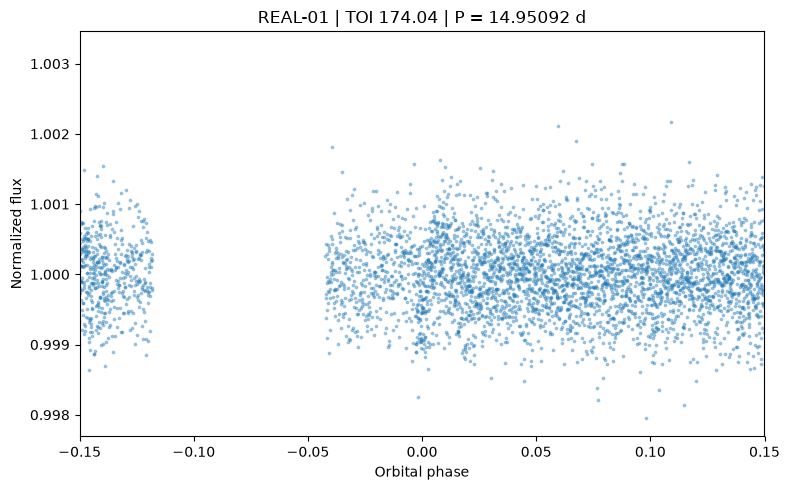


RUNNING REAL-02 | TOI 4307.02


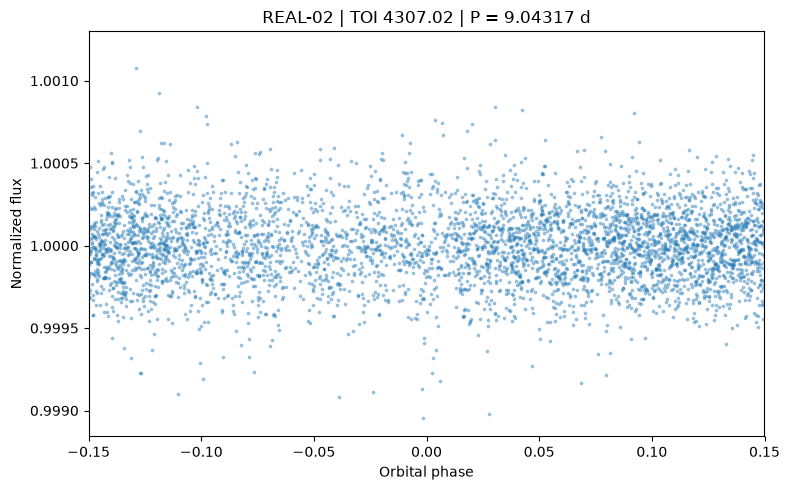


RUNNING REAL-03 | TOI 4580.01


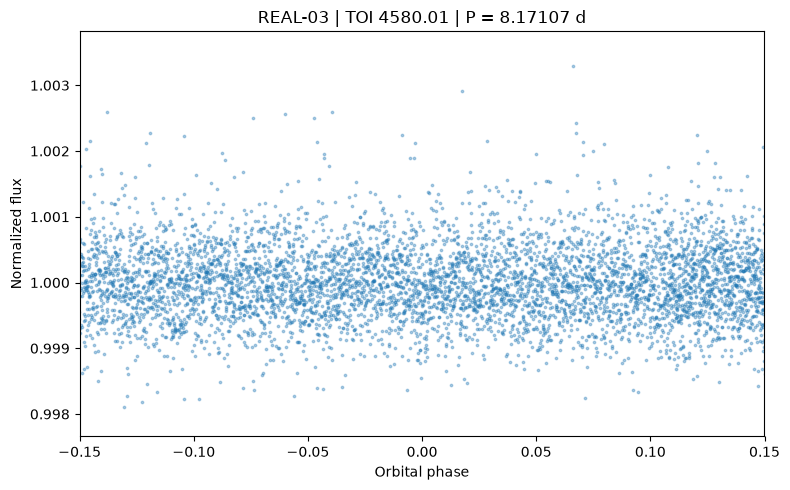


✅ BLIND REAL-TARGET OUTPUTS SAVED AND FROZEN.
✅ Now archive comparison is allowed.

WEEK 15B REAL CASE STUDIES

FROZEN TARGETS


,case_id,toi,tic_id,archive_disposition_at_selection
0,REAL-01,174.04,425997655,CP
1,REAL-02,4307.02,141186075,PC
2,REAL-03,4580.01,219742885,PC



BLIND PIPELINE RESULTS


,case_id,toi,robust_rms,adapt_v1_method,found_period_days,found_depth,apparent_rp_over_rstar,detection_sde,odd_even_relative_difference,secondary_primary_ratio,n_transits_measured
0,REAL-01,174.04,0.000528,SG_501,14.950920,0.000351,0.018747,8.654068,0.467878,-0.106063,2
1,REAL-02,4307.02,0.000225,SG_501,9.043170,0.000166,0.012884,5.457315,NaN,0.461807,2
2,REAL-03,4580.01,0.000633,SG_501,8.171068,0.000294,0.017149,5.039307,0.418651,-0.014185,3



POST-FREEZE ARCHIVE COMPARISON


,case_id,toi,tfopwg_disp,found_period_days,pl_orbper,period_fractional_error,exact_period_match_1pct,found_depth,archive_depth_fraction,depth_fractional_difference_vs_archive
0,REAL-01,174.04,CP,14.950920,3.976683,2.759646,False,0.000351,0.000142,1.475054
1,REAL-02,4307.02,PC,9.043170,4.654580,0.942854,False,0.000166,0.000025,5.752131
2,REAL-03,4580.01,PC,8.171068,0.916799,7.912604,False,0.000294,0.000039,6.533577



✅ THREE REAL CASE STUDIES SELECTED DETERMINISTICALLY
✅ SELECTION RULE FROZEN
✅ FROZEN ADAPT-v1 USED
✅ ARCHIVE PERIOD NOT PASSED TO SEARCH
✅ BLIND RESULTS SAVED BEFORE CATALOG COMPARISON
✅ PERIOD COMPARISON COMPLETED
✅ DEPTH COMPARISON COMPLETED
✅ ODD-EVEN CHECK COMPLETED
✅ SECONDARY-LIKE DIP CHECK COMPLETED
✅ FOLDED LIGHT-CURVE FIGURES SAVED
✅ THESE ARE ILLUSTRATIVE CASE STUDIES
✅ NO INDEPENDENT PLANET-CONFIRMATION CLAIM


In [40]:
# ============================================================
# WEEK 15B
# REAL TOI CASE STUDIES
#
# FROZEN PIPELINE APPLICATION
#
# IMPORTANT:
# 1. Week 15 held-out result must already be frozen.
# 2. Target selection rule is written/frozen BEFORE pipeline run.
# 3. Pipeline outputs are saved BEFORE catalog comparison.
# 4. These are illustrative case studies.
# 5. No independent planet-confirmation claims.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
from io import StringIO

import json
import hashlib
import time
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from astropy.io import fits
from astroquery.mast import Observations, Catalogs
from astropy.timeseries import BoxLeastSquares


# ============================================================
# 1. REQUIRE FROZEN WEEK 15
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",
    "blind_bls_search",
    "build_period_grid",
    "BLS_CONFIG",
    "evaluate_recovery_v2",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Missing required project state:\n"
        f"{missing}\n\n"
        "Run the notebook through Week 15 first."
    )


W15_CONFIG_DIR = (
    CONFIG_DIR
    / "week15_heldout"
)


W15_FREEZE_PATH = (
    W15_CONFIG_DIR
    / "W15_HELDOUT_RESULT_FREEZE.json"
)


if not W15_FREEZE_PATH.exists():

    raise FileNotFoundError(
        "Week 15 held-out result is not frozen."
    )


with open(
    W15_FREEZE_PATH,
    "r",
) as f:

    W15_FREEZE = json.load(
        f
    )


print(
    "✅ Frozen Week 15 result found."
)

print(
    "✅ ADAPT-v1 remains locked."
)


# ============================================================
# 2. LOAD FROZEN ADAPT-v1 CONFIG
# ============================================================

W14_CONFIG_DIR = (
    CONFIG_DIR
    / "week14_adapt_v1"
)


ADAPT_CONFIG_PATH = (
    W14_CONFIG_DIR
    / "ADAPT_V1_config.json"
)


with open(
    ADAPT_CONFIG_PATH,
    "r",
) as f:

    ADAPT_CONFIG = json.load(
        f
    )


ADAPT_THRESHOLD = float(
    ADAPT_CONFIG[
        "threshold"
    ]
)


def choose_adapt_method(
    robust_rms,
):

    if (
        float(
            robust_rms
        )
        <=
        ADAPT_THRESHOLD
    ):

        return "BASELINE"

    return "SG_501"


print(
    f"Frozen threshold = "
    f"{ADAPT_THRESHOLD:.3e}"
)


# ============================================================
# 3. DIRECTORIES
# ============================================================

W15B_RESULTS_DIR = (
    RESULTS_DIR
    / "week15_real_case_studies"
)


W15B_FIGURES_DIR = (
    FIGURES_DIR
    / "week15_real_case_studies"
)


W15B_CONFIG_DIR = (
    CONFIG_DIR
    / "week15_real_case_studies"
)


W15B_CACHE_DIR = (
    W15B_RESULTS_DIR
    / "mast_cache"
)


for folder in [
    W15B_RESULTS_DIR,
    W15B_FIGURES_DIR,
    W15B_CONFIG_DIR,
    W15B_CACHE_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 4. FREEZE CASE-STUDY SELECTION RULE
# ============================================================

SELECTION_RULE = {

    "version":
        "W15B_CASE_SELECTION_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "period_min_days":
        0.5,

    "period_max_days":
        15.0,

    "planet_radius_max_rearth":
        3.0,

    "tmag_max":
        12.0,

    "target_mix": {
        "confirmed_planet_CP": 1,
        "candidate_PC_or_APC": 2,
    },

    "selection_order":
        (
            "ascending planet radius, "
            "then ascending TESS magnitude, "
            "then ascending TOI number"
        ),

    "must_have_spoc_light_curve":
        True,

    "pipeline_results_used_for_selection":
        False,

    "purpose":
        (
            "Illustrative application of the frozen "
            "Week 15 pipeline. Not independent confirmation."
        ),
}


SELECTION_RULE_PATH = (
    W15B_CONFIG_DIR
    / "W15B_CASE_SELECTION_RULE.json"
)


if not SELECTION_RULE_PATH.exists():

    with open(
        SELECTION_RULE_PATH,
        "w",
    ) as f:

        json.dump(
            SELECTION_RULE,
            f,
            indent=2,
        )


    print(
        "✅ Case-study selection rule frozen."
    )

else:

    with open(
        SELECTION_RULE_PATH,
        "r",
    ) as f:

        SELECTION_RULE = json.load(
            f
        )


    print(
        "✅ Existing frozen selection rule preserved."
    )


# ============================================================
# 5. QUERY NASA EXOPLANET ARCHIVE TOI TABLE
# ============================================================

toi_query = """
SELECT
    toi,
    tid,
    tfopwg_disp,
    pl_orbper,
    pl_rade,
    pl_trandep,
    pl_trandurh,
    pl_tranmid,
    st_tmag,
    st_rad,
    st_teff
FROM toi
WHERE
    pl_orbper >= 0.5
    AND pl_orbper <= 15.0
    AND pl_rade <= 3.0
    AND st_tmag <= 12.0
    AND tid IS NOT NULL
"""


tap_url = (
    "https://exoplanetarchive.ipac.caltech.edu/"
    "TAP/sync"
)


response = requests.get(
    tap_url,
    params={
        "query":
            " ".join(
                toi_query.split()
            ),

        "format":
            "csv",
    },
    timeout=120,
)


response.raise_for_status()


toi_df = pd.read_csv(
    StringIO(
        response.text
    )
)


print()
print(
    "Archive rows satisfying basic frozen rule:",
    len(
        toi_df
    )
)


# ============================================================
# 6. CLEAN TOI TABLE
# ============================================================

numeric_columns = [
    "toi",
    "tid",
    "pl_orbper",
    "pl_rade",
    "pl_trandep",
    "pl_trandurh",
    "pl_tranmid",
    "st_tmag",
    "st_rad",
    "st_teff",
]


for column in numeric_columns:

    toi_df[
        column
    ] = pd.to_numeric(
        toi_df[
            column
        ],
        errors="coerce",
    )


toi_df = toi_df.dropna(
    subset=[
        "toi",
        "tid",
        "pl_orbper",
        "pl_rade",
        "st_tmag",
    ]
)


toi_df[
    "tfopwg_disp"
] = (

    toi_df[
        "tfopwg_disp"
    ]

    .astype(
        str
    )

    .str.strip()

    .str.upper()
)


toi_df = toi_df[
    toi_df[
        "tfopwg_disp"
    ].isin(
        [
            "CP",
            "PC",
            "APC",
        ]
    )
].copy()


toi_df = toi_df.sort_values(
    [
        "pl_rade",
        "st_tmag",
        "toi",
    ],
    ascending=[
        True,
        True,
        True,
    ],
).reset_index(
    drop=True
)


# ============================================================
# 7. CHECK WHETHER A TIC HAS A SPOC LIGHT CURVE
# ============================================================

def find_spoc_lc_product(
    tic_id,
):

    try:

        observations = (
            Observations.query_criteria(

                obs_collection="TESS",

                target_name=str(
                    int(
                        tic_id
                    )
                ),
            )
        )


        if len(
            observations
        ) == 0:

            return None


        products = (
            Observations.get_product_list(
                observations
            )
        )


        candidates = []


        for i in range(
            len(
                products
            )
        ):

            filename = str(
                products[
                    i
                ][
                    "productFilename"
                ]
            )


            lower_name = (
                filename.lower()
            )


            subgroup = ""

            try:

                subgroup = str(
                    products[
                        i
                    ][
                        "productSubGroupDescription"
                    ]
                ).upper()

            except Exception:
                pass


            looks_like_lc = (
                lower_name.endswith(
                    "lc.fits"
                )
                or
                subgroup
                ==
                "LC"
            )


            looks_like_tpf = (
                "tp.fits"
                in lower_name
                or
                "tpf"
                in lower_name
            )


            if (
                looks_like_lc
                and
                not looks_like_tpf
            ):

                sector = None

                try:

                    sector = int(
                        observations[
                            0
                        ][
                            "sequence_number"
                        ]
                    )

                except Exception:
                    pass


                candidates.append({

                    "product_index":
                        i,

                    "filename":
                        filename,

                    "data_uri":
                        str(
                            products[
                                i
                            ][
                                "dataURI"
                            ]
                        ),

                    "sector":
                        sector,
                })


        if len(
            candidates
        ) == 0:

            return None


        # Deterministic
        candidates = sorted(
            candidates,
            key=lambda x:
                x[
                    "filename"
                ]
        )


        return candidates[
            0
        ]


    except Exception:

        return None


# ============================================================
# 8. DETERMINISTICALLY SELECT THREE CASE STUDIES
# ============================================================

selected_rows = []


# ------------------------------------------------------------
# A. One confirmed planet
# ------------------------------------------------------------

confirmed_pool = (
    toi_df[
        toi_df[
            "tfopwg_disp"
        ]
        ==
        "CP"
    ]
)


for _, row in confirmed_pool.iterrows():

    product = find_spoc_lc_product(
        row[
            "tid"
        ]
    )


    if product is not None:

        selected = (
            row.to_dict()
        )


        selected[
            "selected_product"
        ] = product


        selected_rows.append(
            selected
        )


        break


# ------------------------------------------------------------
# B. Two PC/APC candidates
# ------------------------------------------------------------

candidate_pool = (
    toi_df[
        toi_df[
            "tfopwg_disp"
        ].isin(
            [
                "PC",
                "APC",
            ]
        )
    ]
)


for _, row in candidate_pool.iterrows():

    if len(
        selected_rows
    ) >= 3:

        break


    product = find_spoc_lc_product(
        row[
            "tid"
        ]
    )


    if product is None:

        continue


    existing_tics = {
        int(
            r[
                "tid"
            ]
        )
        for r in selected_rows
    }


    if (
        int(
            row[
                "tid"
            ]
        )
        in
        existing_tics
    ):

        continue


    selected = (
        row.to_dict()
    )


    selected[
        "selected_product"
    ] = product


    selected_rows.append(
        selected
    )


if len(
    selected_rows
) != 3:

    raise RuntimeError(
        "Could not find three TOIs satisfying "
        "the frozen selection rule with usable "
        "SPOC light curves."
    )


# ============================================================
# 9. FREEZE SELECTED TARGET IDENTITIES
#
# No pipeline results have been generated yet.
# ============================================================

selected_targets_rows = []


for case_number, row in enumerate(
    selected_rows,
    start=1,
):

    product = (
        row[
            "selected_product"
        ]
    )


    selected_targets_rows.append({

        "case_id":
            f"REAL-{case_number:02d}",

        "toi":
            float(
                row[
                    "toi"
                ]
            ),

        "tic_id":
            int(
                row[
                    "tid"
                ]
            ),

        "archive_disposition_at_selection":
            str(
                row[
                    "tfopwg_disp"
                ]
            ),

        "selection_radius_rearth":
            float(
                row[
                    "pl_rade"
                ]
            ),

        "selection_tmag":
            float(
                row[
                    "st_tmag"
                ]
            ),

        "selected_filename":
            product[
                "filename"
            ],

        "selected_data_uri":
            product[
                "data_uri"
            ],
    })


selected_targets_df = pd.DataFrame(
    selected_targets_rows
)


TARGET_FREEZE_PATH = (
    W15B_CONFIG_DIR
    / "W15B_SELECTED_TARGETS_V1.csv"
)


if TARGET_FREEZE_PATH.exists():

    frozen_targets_df = pd.read_csv(
        TARGET_FREEZE_PATH
    )


    # Once frozen, use original targets.
    selected_targets_df = (
        frozen_targets_df.copy()
    )


    print(
        "✅ Existing case-study target freeze preserved."
    )

else:

    selected_targets_df.to_csv(
        TARGET_FREEZE_PATH,
        index=False,
    )


    print(
        "✅ Three real case-study targets frozen."
    )


print()
print(
    "FROZEN REAL CASE STUDIES"
)

display(
    selected_targets_df[
        [
            "case_id",
            "toi",
            "tic_id",
            "archive_disposition_at_selection",
            "selection_radius_rearth",
            "selection_tmag",
        ]
    ]
)


# ============================================================
# 10. DOWNLOAD A FROZEN CASE-STUDY LIGHT CURVE
# ============================================================

def download_case_lightcurve(
    case_row,
):

    case_id = str(
        case_row[
            "case_id"
        ]
    )


    data_uri = str(
        case_row[
            "selected_data_uri"
        ]
    )


    original_filename = str(
        case_row[
            "selected_filename"
        ]
    )


    local_fits = (

        W15B_CACHE_DIR
        /
        f"{case_id}_{original_filename}"
    )


    temp_fits = Path(
        str(
            local_fits
        )
        +
        ".part"
    )


    if not local_fits.exists():

        url = (

            "https://mast.stsci.edu/"
            "api/v0.1/Download/file"
            f"?uri={data_uri}"
        )


        print(
            f"Downloading {case_id}..."
        )


        with requests.get(
            url,
            stream=True,
            timeout=(
                20,
                120,
            ),
        ) as response:

            response.raise_for_status()


            with open(
                temp_fits,
                "wb",
            ) as f:

                for chunk in response.iter_content(
                    chunk_size=1024 * 1024
                ):

                    if chunk:

                        f.write(
                            chunk
                        )


        with fits.open(
            temp_fits,
            memmap=False,
        ) as hdul:

            hdul.verify(
                "exception"
            )


        temp_fits.replace(
            local_fits
        )


    with fits.open(
        local_fits,
        memmap=False,
    ) as hdul:

        data = hdul[
            1
        ].data


        columns = list(
            data.columns.names
        )


        time_values = np.asarray(
            data[
                "TIME"
            ],
            dtype=float,
        )


        if (
            "PDCSAP_FLUX"
            in columns
        ):

            flux_values = np.asarray(
                data[
                    "PDCSAP_FLUX"
                ],
                dtype=float,
            )

        else:

            flux_values = np.asarray(
                data[
                    "SAP_FLUX"
                ],
                dtype=float,
            )


        if (
            "QUALITY"
            in columns
        ):

            quality = np.asarray(
                data[
                    "QUALITY"
                ],
                dtype=int,
            )

        else:

            quality = np.zeros(
                len(
                    time_values
                ),
                dtype=int,
            )


    good = (

        np.isfinite(
            time_values
        )

        &

        np.isfinite(
            flux_values
        )

        &

        (
            quality
            ==
            0
        )
    )


    time_values = (
        time_values[
            good
        ]
    )


    flux_values = (
        flux_values[
            good
        ]
    )


    flux_values = (

        flux_values
        /
        np.nanmedian(
            flux_values
        )
    )


    return {

        "time":
            time_values,

        "flux":
            flux_values,

        "local_fits":
            str(
                local_fits
            ),
    }


# ============================================================
# 11. FROZEN PREPROCESSING
# ============================================================

def robust_rms(
    flux,
):

    flux = np.asarray(
        flux,
        dtype=float,
    )


    med = np.nanmedian(
        flux
    )


    mad = np.nanmedian(
        np.abs(
            flux
            -
            med
        )
    )


    return float(
        1.4826
        *
        mad
    )


def apply_frozen_preprocessing(
    time_values,
    flux_values,
    method_name,
):

    t = np.asarray(
        time_values,
        dtype=float,
    )


    f = np.asarray(
        flux_values,
        dtype=float,
    )


    good = (

        np.isfinite(
            t
        )

        &

        np.isfinite(
            f
        )
    )


    t = t[
        good
    ]

    f = f[
        good
    ]


    if (
        method_name
        ==
        "BASELINE"
    ):

        return (
            t,
            f,
        )


    trend = savgol_filter(
        f,
        window_length=501,
        polyorder=2,
    )


    detrended = (
        f
        /
        trend
    )


    good = (

        np.isfinite(
            detrended
        )

        &

        np.isfinite(
            t
        )
    )


    return (
        t[
            good
        ],
        detrended[
            good
        ],
    )


# ============================================================
# 12. SIMPLE VETTING HELPERS
# ============================================================

def phase_fold(
    time_values,
    period,
    epoch,
):

    return (

        (
            time_values
            -
            epoch
            +
            0.5
            *
            period
        )

        %
        period

    ) / period - 0.5


def robust_local_depth(
    phase,
    flux,
    center,
    width,
):

    distance = np.abs(

        (
            phase
            -
            center
            +
            0.5
        )
        %
        1.0
        -
        0.5
    )


    in_transit = (
        distance
        <=
        width
        /
        2
    )


    out_transit = (
        (
            distance
            >
            width
        )
        &
        (
            distance
            <
            3
            *
            width
        )
    )


    if (
        in_transit.sum()
        <
        3
        or
        out_transit.sum()
        <
        5
    ):

        return np.nan


    return float(

        np.nanmedian(
            flux[
                out_transit
            ]
        )

        -

        np.nanmedian(
            flux[
                in_transit
            ]
        )
    )


def case_vetting(
    time_values,
    flux_values,
    candidate,
):

    period = float(
        candidate[
            "found_period_days"
        ]
    )


    epoch = float(
        candidate[
            "found_epoch_btjd"
        ]
    )


    duration = float(
        candidate.get(
            "found_duration_days",
            np.nan,
        )
    )


    if (
        not np.isfinite(
            duration
        )
    ):

        duration = (
            3
            /
            24
        )


    phase = phase_fold(
        time_values,
        period,
        epoch,
    )


    phase_width = min(
        0.2,
        max(
            duration
            /
            period,
            0.005,
        )
    )


    primary_depth = robust_local_depth(
        phase,
        flux_values,
        center=0.0,
        width=phase_width,
    )


    secondary_depth = robust_local_depth(
        phase,
        flux_values,
        center=0.5,
        width=phase_width,
    )


    if (
        np.isfinite(
            primary_depth
        )
        and
        primary_depth
        !=
        0
        and
        np.isfinite(
            secondary_depth
        )
    ):

        secondary_ratio = (
            secondary_depth
            /
            primary_depth
        )

    else:

        secondary_ratio = np.nan


    # --------------------------------------------------------
    # Odd-even transit depth check
    # --------------------------------------------------------

    transit_number = np.floor(

        (
            time_values
            -
            epoch
        )
        /
        period

        +
        0.5
    ).astype(
        int
    )


    in_primary = (
        np.abs(
            phase
        )
        <=
        phase_width
        /
        2
    )


    odd_depths = []
    even_depths = []


    unique_transits = np.unique(
        transit_number[
            in_primary
        ]
    )


    for number in unique_transits:

        mask = (

            in_primary
            &
            (
                transit_number
                ==
                number
            )
        )


        if (
            mask.sum()
            <
            2
        ):

            continue


        depth = (

            1.0
            -
            np.nanmedian(
                flux_values[
                    mask
                ]
            )
        )


        if (
            number
            %
            2
            ==
            0
        ):

            even_depths.append(
                depth
            )

        else:

            odd_depths.append(
                depth
            )


    odd_depth = (
        np.nanmedian(
            odd_depths
        )
        if len(
            odd_depths
        )
        >
        0
        else np.nan
    )


    even_depth = (
        np.nanmedian(
            even_depths
        )
        if len(
            even_depths
        )
        >
        0
        else np.nan
    )


    if (
        np.isfinite(
            odd_depth
        )
        and
        np.isfinite(
            even_depth
        )
        and
        primary_depth
        not in [
            0,
            np.nan,
        ]
    ):

        odd_even_difference = (

            abs(
                odd_depth
                -
                even_depth
            )

            /
            max(
                abs(
                    primary_depth
                ),
                1e-12,
            )
        )

    else:

        odd_even_difference = np.nan


    return {

        "primary_depth_vetting":
            primary_depth,

        "secondary_depth":
            secondary_depth,

        "secondary_primary_ratio":
            secondary_ratio,

        "odd_depth":
            odd_depth,

        "even_depth":
            even_depth,

        "odd_even_relative_difference":
            odd_even_difference,

        "n_transits_measured":
            int(
                len(
                    unique_transits
                )
            ),
    }


# ============================================================
# 13. RUN FROZEN PIPELINE ON REAL CASES
#
# Critically: archive period is NOT supplied to BLS.
# ============================================================

case_results = []


for _, case_row in (
    selected_targets_df.iterrows()
):

    print()
    print("=" * 72)

    print(
        "RUNNING",
        case_row[
            "case_id"
        ],
        "| TOI",
        case_row[
            "toi"
        ],
    )

    print("=" * 72)


    host = download_case_lightcurve(
        case_row
    )


    rms = robust_rms(
        host[
            "flux"
        ]
    )


    preprocessing = (
        choose_adapt_method(
            rms
        )
    )


    processed_t, processed_f = (
        apply_frozen_preprocessing(

            host[
                "time"
            ],

            host[
                "flux"
            ],

            preprocessing,
        )
    )


    period_grid = build_period_grid(

        processed_t,

        processed_f,

        BLS_CONFIG,
    )


    start = time.perf_counter()


    candidate = blind_bls_search(

        processed_t,

        processed_f,

        period_grid=period_grid,

        config=BLS_CONFIG,
    )


    runtime = (
        time.perf_counter()
        -
        start
    )


    vetting = case_vetting(

        processed_t,

        processed_f,

        candidate,
    )


    output_row = {

        "case_id":
            case_row[
                "case_id"
            ],

        "toi":
            case_row[
                "toi"
            ],

        "tic_id":
            int(
                case_row[
                    "tic_id"
                ]
            ),

        "robust_rms":
            rms,

        "adapt_v1_method":
            preprocessing,

        "found_period_days":
            candidate.get(
                "found_period_days",
                np.nan,
            ),

        "found_epoch_btjd":
            candidate.get(
                "found_epoch_btjd",
                np.nan,
            ),

        "found_duration_days":
            candidate.get(
                "found_duration_days",
                np.nan,
            ),

        "found_depth":
            candidate.get(
                "found_depth",
                np.nan,
            ),

        "apparent_rp_over_rstar":
            (
                np.sqrt(
                    candidate.get(
                        "found_depth",
                        np.nan,
                    )
                )
                if
                candidate.get(
                    "found_depth",
                    np.nan,
                )
                >
                0
                else
                np.nan
            ),

        "detection_sde":
            candidate.get(
                "detection_sde",
                np.nan,
            ),

        "runtime_seconds":
            runtime,

        **vetting,
    }


    case_results.append(
        output_row
    )


    # ========================================================
    # SAVE INDIVIDUAL PERIOD/FOLD FIGURE
    # ========================================================

    found_period = float(
        candidate[
            "found_period_days"
        ]
    )


    found_epoch = float(
        candidate[
            "found_epoch_btjd"
        ]
    )


    phase = phase_fold(

        processed_t,

        found_period,

        found_epoch,
    )


    fig, ax = plt.subplots(
        figsize=(
            8,
            5,
        )
    )


    ax.scatter(
        phase,
        processed_f,
        s=3,
        alpha=0.35,
    )


    ax.set_xlim(
        -0.15,
        0.15,
    )


    ax.set_xlabel(
        "Orbital phase"
    )


    ax.set_ylabel(
        "Normalized flux"
    )


    ax.set_title(
        f"{case_row['case_id']} | "
        f"TOI {case_row['toi']} | "
        f"P = {found_period:.5f} d"
    )


    fig.tight_layout()


    fig.savefig(

        W15B_FIGURES_DIR
        /
        f"{case_row['case_id']}_folded.png",

        dpi=220,
    )


    plt.show()


# ============================================================
# 14. SAVE OUR RESULTS BEFORE ARCHIVE COMPARISON
# ============================================================

case_results_df = pd.DataFrame(
    case_results
)


BLIND_RESULTS_PATH = (
    W15B_RESULTS_DIR
    / "W15B_BLIND_PIPELINE_RESULTS.csv"
)


case_results_df.to_csv(
    BLIND_RESULTS_PATH,
    index=False,
)


blind_hash = hashlib.sha256(
    BLIND_RESULTS_PATH.read_bytes()
).hexdigest()


with open(

    W15B_CONFIG_DIR
    / "W15B_BLIND_RESULTS_FREEZE.json",

    "w",

) as f:

    json.dump(
        {
            "frozen_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "blind_results_sha256":
                blind_hash,

            "archive_comparison_performed_before_freeze":
                False,
        },
        f,
        indent=2,
    )


print()
print(
    "✅ BLIND REAL-TARGET OUTPUTS SAVED AND FROZEN."
)

print(
    "✅ Now archive comparison is allowed."
)


# ============================================================
# 15. ARCHIVE COMPARISON
#
# Only now do we attach published/catalog parameters.
# ============================================================

archive_columns = [
    "toi",
    "tfopwg_disp",
    "pl_orbper",
    "pl_rade",
    "pl_trandep",
    "pl_trandurh",
    "pl_tranmid",
    "st_tmag",
    "st_rad",
    "st_teff",
]


comparison_archive_df = (
    toi_df[
        archive_columns
    ]
    .copy()
)


comparison_df = (

    case_results_df

    .merge(

        comparison_archive_df,

        on="toi",

        how="left",
    )
)


comparison_df[
    "period_fractional_error"
] = (

    np.abs(

        comparison_df[
            "found_period_days"
        ]

        -

        comparison_df[
            "pl_orbper"
        ]
    )

    /

    comparison_df[
        "pl_orbper"
    ]
)


comparison_df[
    "exact_period_match_1pct"
] = (

    comparison_df[
        "period_fractional_error"
    ]

    <=
    0.01
)


comparison_df[
    "archive_depth_fraction"
] = (

    comparison_df[
        "pl_trandep"
    ]

    /
    1e6
)


comparison_df[
    "depth_fractional_difference_vs_archive"
] = (

    (
        comparison_df[
            "found_depth"
        ]

        -

        comparison_df[
            "archive_depth_fraction"
        ]
    )

    /

    comparison_df[
        "archive_depth_fraction"
    ]
)


COMPARISON_PATH = (
    W15B_RESULTS_DIR
    / "W15B_ARCHIVE_COMPARISON.csv"
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
)


# ============================================================
# 16. FINAL DISPLAY
# ============================================================

print()
print("=" * 78)
print("WEEK 15B REAL CASE STUDIES")
print("=" * 78)


print()
print(
    "FROZEN TARGETS"
)

display(

    selected_targets_df[
        [
            "case_id",
            "toi",
            "tic_id",
            "archive_disposition_at_selection",
        ]
    ]
)


print()
print(
    "BLIND PIPELINE RESULTS"
)

display(

    case_results_df[
        [
            "case_id",
            "toi",
            "robust_rms",
            "adapt_v1_method",
            "found_period_days",
            "found_depth",
            "apparent_rp_over_rstar",
            "detection_sde",
            "odd_even_relative_difference",
            "secondary_primary_ratio",
            "n_transits_measured",
        ]
    ]
)


print()
print(
    "POST-FREEZE ARCHIVE COMPARISON"
)

display(

    comparison_df[
        [
            "case_id",
            "toi",
            "tfopwg_disp",
            "found_period_days",
            "pl_orbper",
            "period_fractional_error",
            "exact_period_match_1pct",
            "found_depth",
            "archive_depth_fraction",
            "depth_fractional_difference_vs_archive",
        ]
    ]
)


print()
print("=" * 78)
print("✅ THREE REAL CASE STUDIES SELECTED DETERMINISTICALLY")
print("✅ SELECTION RULE FROZEN")
print("✅ FROZEN ADAPT-v1 USED")
print("✅ ARCHIVE PERIOD NOT PASSED TO SEARCH")
print("✅ BLIND RESULTS SAVED BEFORE CATALOG COMPARISON")
print("✅ PERIOD COMPARISON COMPLETED")
print("✅ DEPTH COMPARISON COMPLETED")
print("✅ ODD-EVEN CHECK COMPLETED")
print("✅ SECONDARY-LIKE DIP CHECK COMPLETED")
print("✅ FOLDED LIGHT-CURVE FIGURES SAVED")
print("✅ THESE ARE ILLUSTRATIVE CASE STUDIES")
print("✅ NO INDEPENDENT PLANET-CONFIRMATION CLAIM")
print("=" * 78)

✅ Core project state found.
✅ Week 16 directories ready.
✅ Frozen Week 15 held-out result verified.
✅ Week 15B blind case-study result freeze verified.
✅ Week 15 final tables loaded.
✅ Week 15B real-target outputs loaded.
✅ Master numerical tables saved.

DEVELOPMENT → HELD-OUT ADAPT SUMMARY


,dataset,FIXED_BASELINE,ADAPT_V1,absolute_difference
0,Development,0.455000,0.6450,0.190000
1,Held-out,0.741667,0.8375,0.095833



FINAL STORY TABLE


,question,result
0,Baseline recovery,622/1000 exact recoveries (62.2%).
1,Does preprocessing matter?,Yes. SG_501 increased exact recovery from 62.2...
2,Does search method matter?,BLS and TLS had similar paired recovery (64.0%...
3,Did ADAPT-v1 improve development recovery?,Yes. Development small-planet exact recovery i...
4,Did ADAPT-v1 generalize?,"On the frozen held-out benchmark, small-planet..."
5,Main held-out limitation,"Only three held-out hosts were used, and ADAPT..."


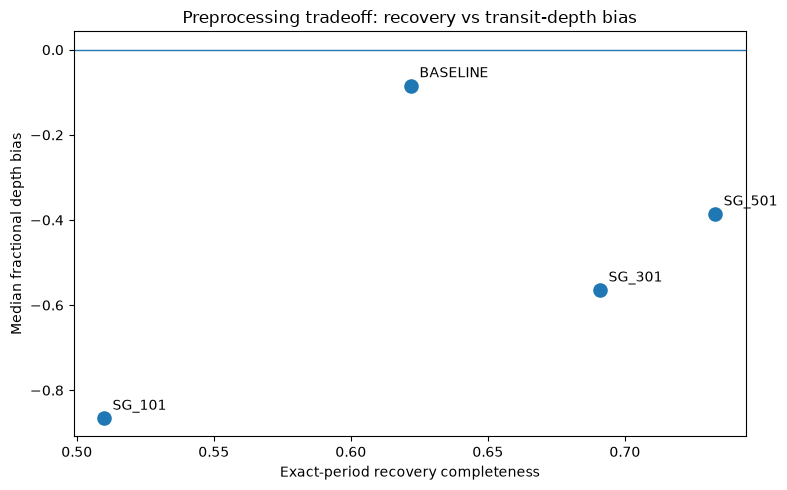

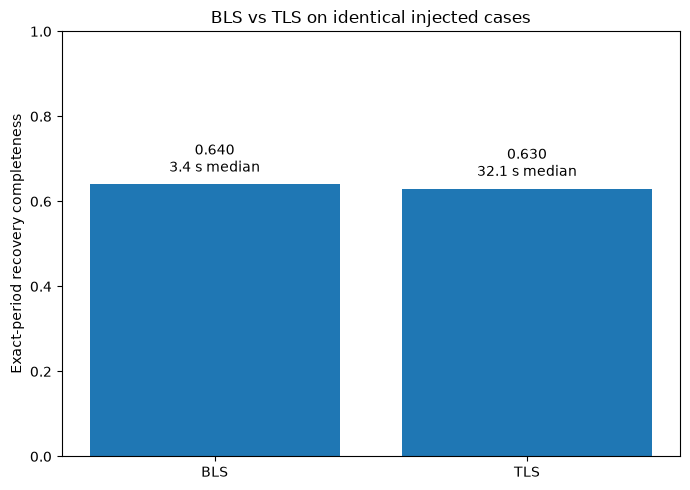

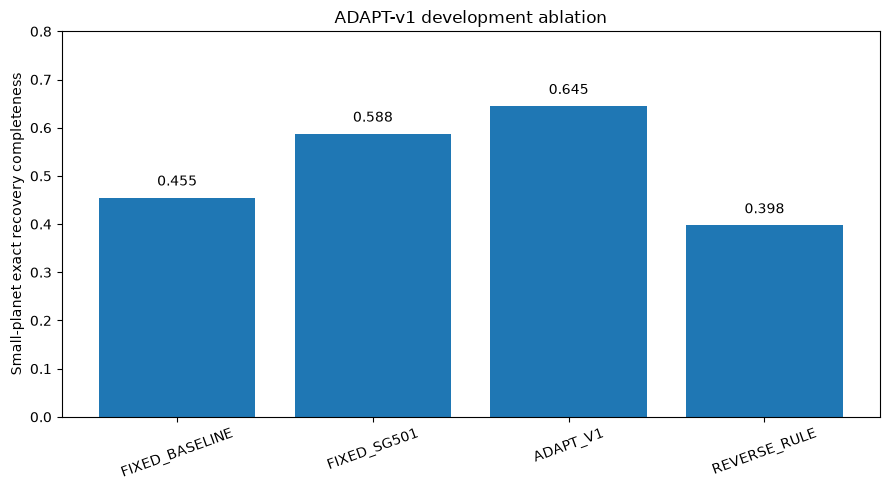

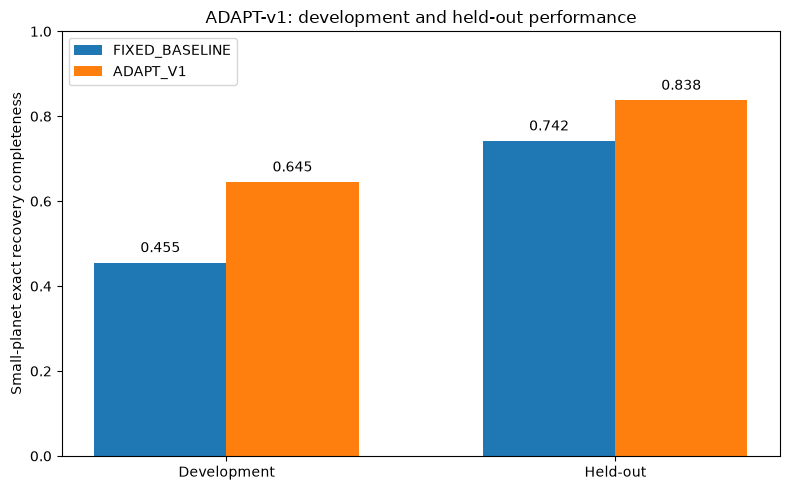

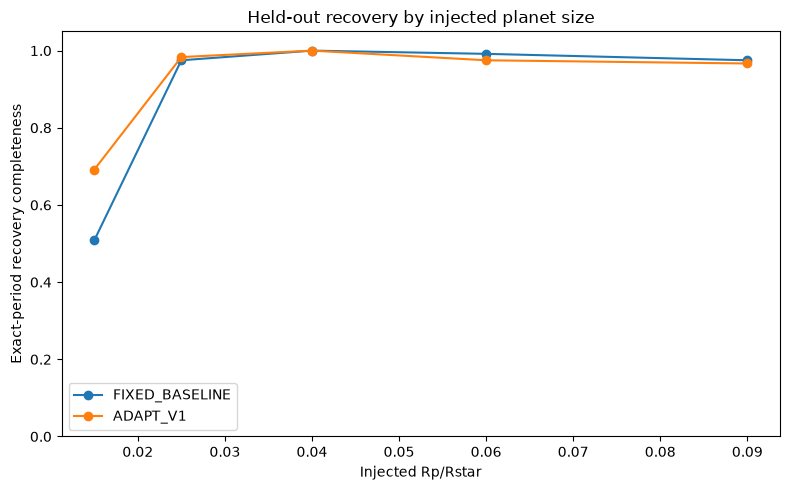

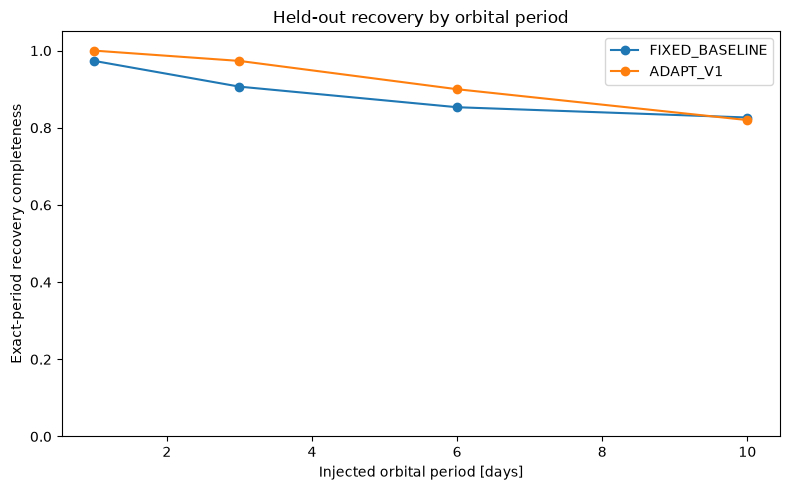

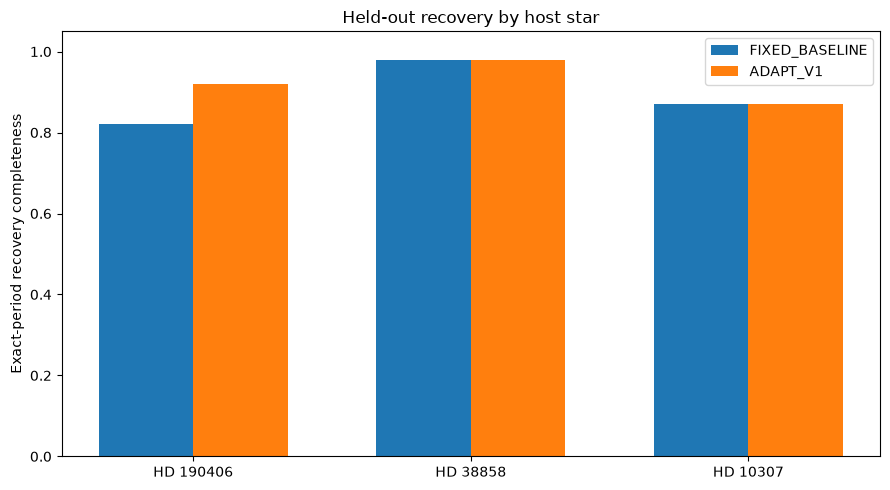

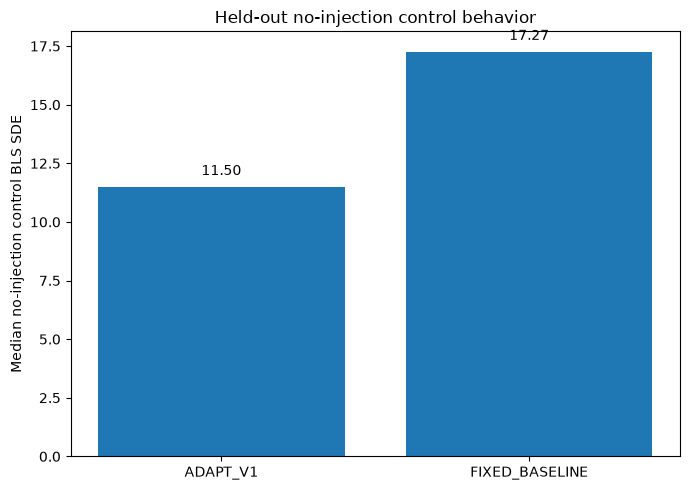


FINAL REAL-TARGET CASE-STUDY TABLE


,case_id,toi,tic_id,tfopwg_disp,adapt_v1_method,found_period_days,pl_orbper,period_fractional_error,exact_period_match_1pct,found_depth,archive_depth_fraction,depth_fractional_difference_vs_archive,odd_even_relative_difference,secondary_primary_ratio
0,REAL-01,174.04,425997655,CP,SG_501,14.950920,3.976683,2.759646,False,0.000351,0.000142,1.475054,0.467878,-0.106063
1,REAL-02,4307.02,141186075,PC,SG_501,9.043170,4.654580,0.942854,False,0.000166,0.000025,5.752131,NaN,0.461807
2,REAL-03,4580.01,219742885,PC,SG_501,8.171068,0.916799,7.912604,False,0.000294,0.000039,6.533577,0.418651,-0.014185


✅ Master machine-readable result summary saved.

PAPER-READY RESULTS SUMMARY

WEEK 16 MASTER RESULTS — PAPER-READY NUMERICAL SUMMARY

Baseline benchmark
------------------
The frozen baseline pipeline recovered the injected orbital
period exactly in 622 of 1,000 development injections,
corresponding to an exact-period recovery completeness of
62.2%.

Preprocessing experiment
------------------------
Recovery depended strongly on preprocessing. The fixed SG_501
configuration increased exact-period recovery from 62.2% under
the baseline preprocessing to 73.3%. However, this improvement
was accompanied by substantially greater transit-depth
suppression: the median fractional depth bias among exact
recoveries was -0.385 for SG_501 compared with -0.084 for the
baseline. This establishes a recovery-versus-measurement-bias
tradeoff.

BLS versus TLS
--------------
On the same 200 injected cases and identical period range, BLS
recovered 128/200 cases exactly (64.0%), whereas TLS recovered
126/2

,dataset,FIXED_BASELINE,ADAPT_V1,absolute_difference
0,Development,0.455000,0.6450,0.190000
1,Held-out,0.741667,0.8375,0.095833



FINAL WEEK 15 PRIMARY RESULT


...


FINAL CASE-STUDY TABLE


,case_id,toi,tic_id,tfopwg_disp,adapt_v1_method,found_period_days,pl_orbper,period_fractional_error,exact_period_match_1pct,found_depth,archive_depth_fraction,depth_fractional_difference_vs_archive,odd_even_relative_difference,secondary_primary_ratio
0,REAL-01,174.04,425997655,CP,SG_501,14.950920,3.976683,2.759646,False,0.000351,0.000142,1.475054,0.467878,-0.106063
1,REAL-02,4307.02,141186075,PC,SG_501,9.043170,4.654580,0.942854,False,0.000166,0.000025,5.752131,NaN,0.461807
2,REAL-03,4580.01,219742885,PC,SG_501,8.171068,0.916799,7.912604,False,0.000294,0.000039,6.533577,0.418651,-0.014185



FINAL FIGURE MANIFEST


,filename,sha256,size_bytes
0,W16_Fig1_preprocessing_tradeoff.png,070fdb6ec9d5b452c41aebaae06629b8779ca57287636e...,95997
1,W16_Fig2_bls_vs_tls.png,73692ba32b8762bde506cb05c2f2dcbd12904308c43097...,75176
2,W16_Fig3_adapt_development_ablation.png,e7576b2458b35e2d204318deb40e3dff6ddca07b796e0a...,116027
3,W16_Fig4_adapt_generalization.png,06f4ea8725205c256fd249649de3cc4ebc0226549e92da...,93576
4,W16_Fig5_heldout_by_size.png,a0357214f32bfdd0de1d7465ae38dada59fdabd1837048...,118071
5,W16_Fig6_heldout_by_period.png,a66ef76f925341ad957466234d2d4f04b7d2e3a71d87ea...,108664
6,W16_Fig7_heldout_by_host.png,0eb19c2b881a5f5d50239a51839f5c910ea9db3801cbb7...,79723
7,W16_Fig8_control_sde.png,8a01f60147fad3a35896b2997ee805956ecccb5ae0ae53...,68134



✅ WEEK 11 BASELINE RESULT INCLUDED
✅ WEEK 12 PREPROCESSING RESULT INCLUDED
✅ WEEK 13 BLS/TLS RESULT INCLUDED
✅ WEEK 14 ADAPT DEVELOPMENT RESULT INCLUDED
✅ WEEK 15 HELD-OUT RESULT INCLUDED
✅ WEEK 15B REAL CASE STUDIES INCLUDED
✅ FINAL MASTER TABLES SAVED
✅ FINAL FIGURES SAVED
✅ PAPER-READY NUMERICAL SUMMARY SAVED
✅ MASTER JSON SAVED
✅ FINAL RESULT PACKAGE FROZEN
✅ NO NEW SEARCHES
✅ NO NEW INJECTIONS
✅ NO NEW TUNING


In [41]:
# ============================================================
# WEEK 16A
# MASTER RESULTS + FINAL FIGURES
#
# PURPOSE
# -------
# Collect the frozen outputs from:
#
#   Week 11  completeness benchmark
#   Week 12  preprocessing comparison
#   Week 13  BLS vs TLS
#   Week 14  ADAPT-v1 development
#   Week 15  untouched held-out evaluation
#   Week 15B real TOI case studies
#
# NO NEW SEARCHES
# NO NEW INJECTIONS
# NO NEW TUNING
# NO CHANGES TO ADAPT-v1
#
# Outputs:
#   final master tables
#   publication-ready figures
#   machine-readable summary
#   paper-ready numerical results text
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone

import json
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REQUIRE PROJECT STATE
# ============================================================

required_names = [
    "PROJECT_ROOT",
    "RESULTS_DIR",
    "FIGURES_DIR",
    "CONFIG_DIR",
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Missing required project state:\n"
        f"{missing}"
    )


print(
    "✅ Core project state found."
)


# ============================================================
# 2. WEEK 16 DIRECTORIES
# ============================================================

W16_RESULTS_DIR = (
    RESULTS_DIR
    / "week16_final"
)


W16_FIGURES_DIR = (
    FIGURES_DIR
    / "week16_final"
)


W16_CONFIG_DIR = (
    CONFIG_DIR
    / "week16_final"
)


for folder in [
    W16_RESULTS_DIR,
    W16_FIGURES_DIR,
    W16_CONFIG_DIR,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "✅ Week 16 directories ready."
)


# ============================================================
# 3. VERIFY WEEK 15 IS FROZEN
# ============================================================

W15_FREEZE_PATH = (
    CONFIG_DIR
    / "week15_heldout"
    / "W15_HELDOUT_RESULT_FREEZE.json"
)


if not W15_FREEZE_PATH.exists():

    raise RuntimeError(
        "STOP: frozen Week 15 held-out result "
        "was not found."
    )


with open(
    W15_FREEZE_PATH,
    "r",
) as f:

    W15_FREEZE = json.load(
        f
    )


print(
    "✅ Frozen Week 15 held-out result verified."
)


# ============================================================
# 4. VERIFY WEEK 15B BLIND RESULT FREEZE
# ============================================================

W15B_FREEZE_PATH = (
    CONFIG_DIR
    / "week15_real_case_studies"
    / "W15B_BLIND_RESULTS_FREEZE.json"
)


if not W15B_FREEZE_PATH.exists():

    raise RuntimeError(
        "STOP: Week 15B blind case-study freeze "
        "was not found."
    )


with open(
    W15B_FREEZE_PATH,
    "r",
) as f:

    W15B_FREEZE = json.load(
        f
    )


print(
    "✅ Week 15B blind case-study result freeze verified."
)


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def sha256_file(
    path,
):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for block in iter(
            lambda:
                f.read(
                    1024 * 1024
                ),
            b"",
        ):

            h.update(
                block
            )

    return h.hexdigest()


def save_csv(
    df,
    filename,
):

    path = (
        W16_RESULTS_DIR
        /
        filename
    )


    df.to_csv(
        path,
        index=False,
    )


    return path


def safe_read_csv(
    path,
):

    path = Path(
        path
    )


    if not path.exists():

        return None


    return pd.read_csv(
        path
    )


# ============================================================
# 6. LOAD WEEK 15 FINAL TABLES
# ============================================================

W15_RESULTS_DIR = (
    RESULTS_DIR
    / "week15_heldout"
)


w15_primary = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_primary_metric.csv"
)


w15_secondary = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_secondary_metrics.csv"
)


w15_by_host = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_host.csv"
)


w15_by_size = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_size.csv"
)


w15_by_period = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_completeness_by_period.csv"
)


w15_alias = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_alias_summary.csv"
)


w15_controls = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_control_summary.csv"
)


w15_switches = safe_read_csv(

    W15_RESULTS_DIR
    / "W15_primary_paired_switches.csv"
)


required_w15 = {
    "primary":
        w15_primary,

    "secondary":
        w15_secondary,

    "by_host":
        w15_by_host,

    "by_size":
        w15_by_size,

    "by_period":
        w15_by_period,

    "alias":
        w15_alias,

    "controls":
        w15_controls,

    "switches":
        w15_switches,
}


missing_w15 = [
    name
    for (
        name,
        value
    ) in required_w15.items()
    if value is None
]


if missing_w15:

    raise RuntimeError(
        "Missing Week 15 result table(s): "
        f"{missing_w15}"
    )


print(
    "✅ Week 15 final tables loaded."
)


# ============================================================
# 7. LOAD WEEK 15B CASE STUDIES
# ============================================================

W15B_RESULTS_DIR = (
    RESULTS_DIR
    / "week15_real_case_studies"
)


W15B_CONFIG_DIR = (
    CONFIG_DIR
    / "week15_real_case_studies"
)


case_results_df = safe_read_csv(

    W15B_RESULTS_DIR
    / "W15B_BLIND_PIPELINE_RESULTS.csv"
)


comparison_df = safe_read_csv(

    W15B_RESULTS_DIR
    / "W15B_ARCHIVE_COMPARISON.csv"
)


selected_targets_df = safe_read_csv(

    W15B_CONFIG_DIR
    / "W15B_SELECTED_TARGETS_V1.csv"
)


if (
    case_results_df is None
    or
    comparison_df is None
    or
    selected_targets_df is None
):

    raise RuntimeError(
        "Missing one or more Week 15B outputs."
    )


print(
    "✅ Week 15B real-target outputs loaded."
)


# ============================================================
# 8. FROZEN NUMERICAL RESULTS FROM WEEKS 11–14
#
# These are the canonical frozen results from the completed
# development stages.
#
# We store them here as a clean final master table.
# ============================================================

week11_summary_df = pd.DataFrame(
    [
        {
            "stage":
                "Week 11",

            "analysis":
                "Frozen baseline completeness",

            "attempted":
                1000,

            "exact_recovered":
                622,

            "exact_completeness":
                0.622,

            "notes":
                (
                    "Canonical clean-PC W11_COMPLETENESS_V1 "
                    "result."
                ),
        }
    ]
)


week12_summary_df = pd.DataFrame(
    [
        {
            "method":
                "BASELINE",

            "exact_recovered":
                622,

            "attempted":
                1000,

            "exact_completeness":
                0.622,

            "alias_aware_completeness":
                0.634,

            "median_depth_bias":
                -0.084080,

            "median_apparent_radius_bias":
                -0.042963,
        },

        {
            "method":
                "SG_101",

            "exact_recovered":
                510,

            "attempted":
                1000,

            "exact_completeness":
                0.510,

            "alias_aware_completeness":
                0.516,

            "median_depth_bias":
                -0.865378,

            "median_apparent_radius_bias":
                -0.633091,
        },

        {
            "method":
                "SG_301",

            "exact_recovered":
                691,

            "attempted":
                1000,

            "exact_completeness":
                0.691,

            "alias_aware_completeness":
                0.691,

            "median_depth_bias":
                -0.564120,

            "median_apparent_radius_bias":
                -0.339788,
        },

        {
            "method":
                "SG_501",

            "exact_recovered":
                733,

            "attempted":
                1000,

            "exact_completeness":
                0.733,

            "alias_aware_completeness":
                0.735,

            "median_depth_bias":
                -0.385444,

            "median_apparent_radius_bias":
                -0.216064,
        },
    ]
)


week13_summary_df = pd.DataFrame(
    [
        {
            "search_method":
                "BLS",

            "attempted":
                200,

            "exact_recovered":
                128,

            "exact_completeness":
                0.640,

            "alias_aware_recovered":
                128,

            "alias_aware_completeness":
                0.640,

            "median_runtime_seconds":
                3.379672,
        },

        {
            "search_method":
                "TLS",

            "attempted":
                200,

            "exact_recovered":
                126,

            "exact_completeness":
                0.630,

            "alias_aware_recovered":
                128,

            "alias_aware_completeness":
                0.640,

            "median_runtime_seconds":
                32.133892,
        },
    ]
)


week14_summary_df = pd.DataFrame(
    [
        {
            "method":
                "FIXED_BASELINE",

            "exact_recovered":
                622,

            "attempted":
                1000,

            "exact_completeness":
                0.622,

            "small_planet_exact_recovered":
                182,

            "small_planet_attempted":
                400,

            "small_planet_completeness":
                0.4550,

            "median_depth_bias":
                -0.084080,

            "median_apparent_radius_bias":
                -0.042963,
        },

        {
            "method":
                "FIXED_SG501",

            "exact_recovered":
                733,

            "attempted":
                1000,

            "exact_completeness":
                0.733,

            "small_planet_exact_recovered":
                235,

            "small_planet_attempted":
                400,

            "small_planet_completeness":
                0.5875,

            "median_depth_bias":
                -0.385444,

            "median_apparent_radius_bias":
                -0.216064,
        },

        {
            "method":
                "ADAPT_V1",

            "exact_recovered":
                763,

            "attempted":
                1000,

            "exact_completeness":
                0.763,

            "small_planet_exact_recovered":
                258,

            "small_planet_attempted":
                400,

            "small_planet_completeness":
                0.6450,

            "median_depth_bias":
                -0.181065,

            "median_apparent_radius_bias":
                -0.095050,
        },

        {
            "method":
                "REVERSE_RULE",

            "exact_recovered":
                592,

            "attempted":
                1000,

            "exact_completeness":
                0.592,

            "small_planet_exact_recovered":
                159,

            "small_planet_attempted":
                400,

            "small_planet_completeness":
                0.3975,

            "median_depth_bias":
                -0.308270,

            "median_apparent_radius_bias":
                -0.168297,
        },
    ]
)


# ============================================================
# 9. SAVE MASTER NUMERICAL TABLES
# ============================================================

save_csv(
    week11_summary_df,
    "W16_week11_baseline_summary.csv",
)


save_csv(
    week12_summary_df,
    "W16_week12_preprocessing_summary.csv",
)


save_csv(
    week13_summary_df,
    "W16_week13_bls_tls_summary.csv",
)


save_csv(
    week14_summary_df,
    "W16_week14_adapt_development_summary.csv",
)


save_csv(
    w15_primary,
    "W16_week15_primary_summary.csv",
)


save_csv(
    w15_secondary,
    "W16_week15_secondary_summary.csv",
)


save_csv(
    comparison_df,
    "W16_week15B_case_study_summary.csv",
)


print(
    "✅ Master numerical tables saved."
)


# ============================================================
# 10. DEVELOPMENT → HELD-OUT ADAPT SUMMARY
# ============================================================

w14_base_small = float(

    week14_summary_df.loc[
        week14_summary_df[
            "method"
        ]
        ==
        "FIXED_BASELINE",

        "small_planet_completeness",
    ].iloc[
        0
    ]
)


w14_adapt_small = float(

    week14_summary_df.loc[
        week14_summary_df[
            "method"
        ]
        ==
        "ADAPT_V1",

        "small_planet_completeness",
    ].iloc[
        0
    ]
)


w15_base_small = float(

    w15_primary.loc[
        w15_primary[
            "method"
        ]
        ==
        "FIXED_BASELINE",

        "exact_completeness",
    ].iloc[
        0
    ]
)


w15_adapt_small = float(

    w15_primary.loc[
        w15_primary[
            "method"
        ]
        ==
        "ADAPT_V1",

        "exact_completeness",
    ].iloc[
        0
    ]
)


adapt_generalization_df = pd.DataFrame(
    [
        {
            "dataset":
                "Development",

            "FIXED_BASELINE":
                w14_base_small,

            "ADAPT_V1":
                w14_adapt_small,

            "absolute_difference":
                (
                    w14_adapt_small
                    -
                    w14_base_small
                ),
        },

        {
            "dataset":
                "Held-out",

            "FIXED_BASELINE":
                w15_base_small,

            "ADAPT_V1":
                w15_adapt_small,

            "absolute_difference":
                (
                    w15_adapt_small
                    -
                    w15_base_small
                ),
        },
    ]
)


save_csv(
    adapt_generalization_df,
    "W16_adapt_development_vs_heldout.csv",
)


print()
print(
    "DEVELOPMENT → HELD-OUT ADAPT SUMMARY"
)

display(
    adapt_generalization_df
)


# ============================================================
# 11. FINAL STORY TABLE
# ============================================================

story_df = pd.DataFrame(
    [
        {
            "question":
                "Baseline recovery",

            "result":
                (
                    "622/1000 exact recoveries "
                    "(62.2%)."
                ),
        },

        {
            "question":
                "Does preprocessing matter?",

            "result":
                (
                    "Yes. SG_501 increased exact recovery "
                    "from 62.2% to 73.3% in development, "
                    "while increasing depth suppression."
                ),
        },

        {
            "question":
                "Does search method matter?",

            "result":
                (
                    "BLS and TLS had similar paired recovery "
                    "(64.0% vs 63.0% exact), while TLS was "
                    "roughly 9.5× slower in the Week 13 subset."
                ),
        },

        {
            "question":
                "Did ADAPT-v1 improve development recovery?",

            "result":
                (
                    "Yes. Development small-planet exact "
                    "recovery increased from 45.5% to 64.5%."
                ),
        },

        {
            "question":
                "Did ADAPT-v1 generalize?",

            "result":
                (
                    "On the frozen held-out benchmark, "
                    "small-planet exact recovery increased "
                    "from 74.17% to 83.75%, an absolute "
                    "increase of 9.58 percentage points."
                ),
        },

        {
            "question":
                "Main held-out limitation",

            "result":
                (
                    "Only three held-out hosts were used, "
                    "and ADAPT-v1 selected SG_501 for only "
                    "one of them. The improvement was "
                    "therefore concentrated in that host."
                ),
        },
    ]
)


save_csv(
    story_df,
    "W16_final_story_table.csv",
)


print()
print(
    "FINAL STORY TABLE"
)

display(
    story_df
)


# ============================================================
# 12. FIGURE 1
# WEEK 12 PREPROCESSING:
# RECOVERY vs DEPTH BIAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.scatter(

    week12_summary_df[
        "exact_completeness"
    ],

    week12_summary_df[
        "median_depth_bias"
    ],

    s=90,
)


for _, row in (
    week12_summary_df.iterrows()
):

    ax.annotate(

        row[
            "method"
        ],

        (
            row[
                "exact_completeness"
            ],

            row[
                "median_depth_bias"
            ],
        ),

        xytext=(
            6,
            6,
        ),

        textcoords=
            "offset points",
    )


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xlabel(
    "Exact-period recovery completeness"
)


ax.set_ylabel(
    "Median fractional depth bias"
)


ax.set_title(
    "Preprocessing tradeoff: recovery vs transit-depth bias"
)


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig1_preprocessing_tradeoff.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 13. FIGURE 2
# WEEK 13 BLS vs TLS
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5,
    )
)


ax.bar(

    week13_summary_df[
        "search_method"
    ],

    week13_summary_df[
        "exact_completeness"
    ],
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Exact-period recovery completeness"
)


ax.set_title(
    "BLS vs TLS on identical injected cases"
)


for i, row in (
    week13_summary_df.iterrows()
):

    ax.text(

        i,

        row[
            "exact_completeness"
        ]
        +
        0.03,

        (
            f"{row['exact_completeness']:.3f}\n"
            f"{row['median_runtime_seconds']:.1f} s median"
        ),

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig2_bls_vs_tls.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 14. FIGURE 3
# WEEK 14 DEVELOPMENT ABLATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        9,
        5,
    )
)


ax.bar(

    week14_summary_df[
        "method"
    ],

    week14_summary_df[
        "small_planet_completeness"
    ],
)


ax.set_ylim(
    0,
    0.8,
)


ax.set_ylabel(
    "Small-planet exact recovery completeness"
)


ax.set_title(
    "ADAPT-v1 development ablation"
)


ax.tick_params(
    axis="x",
    rotation=20,
)


for i, row in (
    week14_summary_df.iterrows()
):

    ax.text(

        i,

        row[
            "small_planet_completeness"
        ]
        +
        0.025,

        f"{row['small_planet_completeness']:.3f}",

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig3_adapt_development_ablation.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 15. FIGURE 4
# DEVELOPMENT vs HELD-OUT
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


x = np.arange(
    len(
        adapt_generalization_df
    )
)


width = 0.34


ax.bar(

    x
    -
    width
    /
    2,

    adapt_generalization_df[
        "FIXED_BASELINE"
    ],

    width=width,

    label="FIXED_BASELINE",
)


ax.bar(

    x
    +
    width
    /
    2,

    adapt_generalization_df[
        "ADAPT_V1"
    ],

    width=width,

    label="ADAPT_V1",
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    adapt_generalization_df[
        "dataset"
    ]
)


ax.set_ylim(
    0,
    1,
)


ax.set_ylabel(
    "Small-planet exact recovery completeness"
)


ax.set_title(
    "ADAPT-v1: development and held-out performance"
)


ax.legend()


for i, row in (
    adapt_generalization_df.iterrows()
):

    ax.text(

        i
        -
        width
        /
        2,

        row[
            "FIXED_BASELINE"
        ]
        +
        0.025,

        f"{row['FIXED_BASELINE']:.3f}",

        ha="center",
    )


    ax.text(

        i
        +
        width
        /
        2,

        row[
            "ADAPT_V1"
        ]
        +
        0.025,

        f"{row['ADAPT_V1']:.3f}",

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig4_adapt_generalization.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 16. FIGURE 5
# HELD-OUT COMPLETENESS BY PLANET SIZE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


for method in [
    "FIXED_BASELINE",
    "ADAPT_V1",
]:

    subset = (

        w15_by_size[
            w15_by_size[
                "method"
            ]
            ==
            method
        ]

        .sort_values(
            "true_rp_over_rstar"
        )
    )


    ax.plot(

        subset[
            "true_rp_over_rstar"
        ],

        subset[
            "exact_completeness"
        ],

        marker="o",

        label=method,
    )


ax.set_ylim(
    0,
    1.05,
)


ax.set_xlabel(
    "Injected Rp/Rstar"
)


ax.set_ylabel(
    "Exact-period recovery completeness"
)


ax.set_title(
    "Held-out recovery by injected planet size"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig5_heldout_by_size.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 17. FIGURE 6
# HELD-OUT COMPLETENESS BY PERIOD
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


for method in [
    "FIXED_BASELINE",
    "ADAPT_V1",
]:

    subset = (

        w15_by_period[
            w15_by_period[
                "method"
            ]
            ==
            method
        ]

        .sort_values(
            "true_period_days"
        )
    )


    ax.plot(

        subset[
            "true_period_days"
        ],

        subset[
            "exact_completeness"
        ],

        marker="o",

        label=method,
    )


ax.set_ylim(
    0,
    1.05,
)


ax.set_xlabel(
    "Injected orbital period [days]"
)


ax.set_ylabel(
    "Exact-period recovery completeness"
)


ax.set_title(
    "Held-out recovery by orbital period"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig6_heldout_by_period.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 18. FIGURE 7
# HELD-OUT PERFORMANCE BY HOST
# ============================================================

host_pivot = (

    w15_by_host

    .pivot(

        index=[
            "heldout_id",
            "candidate_name",
        ],

        columns="method",

        values="exact_completeness",
    )

    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5,
    )
)


x = np.arange(
    len(
        host_pivot
    )
)


width = 0.34


ax.bar(

    x
    -
    width
    /
    2,

    host_pivot[
        "FIXED_BASELINE"
    ],

    width=width,

    label="FIXED_BASELINE",
)


ax.bar(

    x
    +
    width
    /
    2,

    host_pivot[
        "ADAPT_V1"
    ],

    width=width,

    label="ADAPT_V1",
)


ax.set_xticks(
    x
)


ax.set_xticklabels(

    host_pivot[
        "candidate_name"
    ]
)


ax.set_ylim(
    0,
    1.05,
)


ax.set_ylabel(
    "Exact-period recovery completeness"
)


ax.set_title(
    "Held-out recovery by host star"
)


ax.legend()


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig7_heldout_by_host.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 19. FIGURE 8
# NO-INJECTION CONTROL SDE
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        7,
        5,
    )
)


ax.bar(

    w15_controls[
        "method"
    ],

    w15_controls[
        "median_control_sde"
    ],
)


ax.set_ylabel(
    "Median no-injection control BLS SDE"
)


ax.set_title(
    "Held-out no-injection control behavior"
)


for i, row in (
    w15_controls.iterrows()
):

    ax.text(

        i,

        row[
            "median_control_sde"
        ]
        +
        0.5,

        f"{row['median_control_sde']:.2f}",

        ha="center",
    )


fig.tight_layout()


fig.savefig(

    W16_FIGURES_DIR
    / "W16_Fig8_control_sde.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ============================================================
# 20. CASE-STUDY FINAL TABLE
# ============================================================

case_columns = [
    column
    for column in [
        "case_id",
        "toi",
        "tic_id",
        "tfopwg_disp",
        "adapt_v1_method",
        "found_period_days",
        "pl_orbper",
        "period_fractional_error",
        "exact_period_match_1pct",
        "found_depth",
        "archive_depth_fraction",
        "depth_fractional_difference_vs_archive",
        "odd_even_relative_difference",
        "secondary_primary_ratio",
    ]
    if column in comparison_df.columns
]


final_case_table = (

    comparison_df[
        case_columns
    ]

    .copy()
)


save_csv(
    final_case_table,
    "W16_final_case_study_table.csv",
)


print()
print(
    "FINAL REAL-TARGET CASE-STUDY TABLE"
)

display(
    final_case_table
)


# ============================================================
# 21. MASTER RESULTS SUMMARY
# ============================================================

w15_adapt_secondary = (

    w15_secondary[
        w15_secondary[
            "method"
        ]
        ==
        "ADAPT_V1"
    ]

    .iloc[
        0
    ]
)


w15_base_secondary = (

    w15_secondary[
        w15_secondary[
            "method"
        ]
        ==
        "FIXED_BASELINE"
    ]

    .iloc[
        0
    ]
)


w15_switch_row = (
    w15_switches.iloc[
        0
    ]
)


master_summary = {

    "version":
        "W16_MASTER_RESULTS_V1",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "week11": {

        "attempted":
            1000,

        "exact_recovered":
            622,

        "exact_completeness":
            0.622,
    },

    "week12": {

        "best_recovery_fixed_preprocessing":
            "SG_501",

        "SG501_exact_completeness":
            0.733,

        "SG501_median_depth_bias":
            -0.385444,

        "baseline_exact_completeness":
            0.622,

        "baseline_median_depth_bias":
            -0.084080,
    },

    "week13": {

        "BLS_exact_completeness":
            0.640,

        "TLS_exact_completeness":
            0.630,

        "BLS_alias_aware_completeness":
            0.640,

        "TLS_alias_aware_completeness":
            0.640,

        "BLS_median_runtime_seconds":
            3.379672,

        "TLS_median_runtime_seconds":
            32.133892,
    },

    "week14": {

        "adapt_threshold_robust_rms":
            2.15e-4,

        "baseline_small_planet_completeness":
            0.455,

        "adapt_small_planet_completeness":
            0.645,

        "development_absolute_improvement":
            0.190,
    },

    "week15": {

        "heldout_hosts":
            3,

        "unique_injections":
            600,

        "baseline_small_planet_completeness":
            w15_base_small,

        "adapt_small_planet_completeness":
            w15_adapt_small,

        "primary_absolute_improvement":
            (
                w15_adapt_small
                -
                w15_base_small
            ),

        "primary_bootstrap_ci95":
            W15_FREEZE[
                "host_bootstrap_ci95"
            ],

        "baseline_overall_exact":
            float(
                w15_base_secondary[
                    "exact_completeness"
                ]
            ),

        "adapt_overall_exact":
            float(
                w15_adapt_secondary[
                    "exact_completeness"
                ]
            ),

        "baseline_median_depth_bias":
            float(
                w15_base_secondary[
                    "median_depth_bias_exact"
                ]
            ),

        "adapt_median_depth_bias":
            float(
                w15_adapt_secondary[
                    "median_depth_bias_exact"
                ]
            ),

        "baseline_miss_adapt_recovery":
            int(
                w15_switch_row[
                    "baseline_miss_adapt_recovery"
                ]
            ),

        "baseline_recovery_adapt_miss":
            int(
                w15_switch_row[
                    "baseline_recovery_adapt_miss"
                ]
            ),
    },

    "week15B": {

        "n_real_case_studies":
            int(
                len(
                    comparison_df
                )
            ),

        "exact_1pct_period_matches":
            int(
                comparison_df[
                    "exact_period_match_1pct"
                ].sum()
            )
            if
            "exact_period_match_1pct"
            in comparison_df.columns
            else
            None,
    },

    "interpretation_guardrails": [

        (
            "Recovery means exact-period recovery under "
            "the frozen recovery definition."
        ),

        (
            "No binary false-positive rate is claimed from "
            "control SDE because no SDE threshold was frozen."
        ),

        (
            "Apparent-radius bias is based on sqrt(depth), "
            "not a full physical planet-radius inference."
        ),

        (
            "The held-out result uses only three host stars."
        ),

        (
            "Only one held-out host received SG_501 under "
            "ADAPT-v1."
        ),

        (
            "Real TOI examples are illustrative case studies "
            "and do not constitute independent confirmation."
        ),
    ],
}


MASTER_JSON_PATH = (
    W16_RESULTS_DIR
    / "W16_MASTER_RESULTS_V1.json"
)


with open(
    MASTER_JSON_PATH,
    "w",
) as f:

    json.dump(
        master_summary,
        f,
        indent=2,
    )


print(
    "✅ Master machine-readable result summary saved."
)


# ============================================================
# 22. PAPER-READY RESULTS TEXT
# ============================================================

paper_results_text = f"""
WEEK 16 MASTER RESULTS — PAPER-READY NUMERICAL SUMMARY

Baseline benchmark
------------------
The frozen baseline pipeline recovered the injected orbital
period exactly in 622 of 1,000 development injections,
corresponding to an exact-period recovery completeness of
62.2%.

Preprocessing experiment
------------------------
Recovery depended strongly on preprocessing. The fixed SG_501
configuration increased exact-period recovery from 62.2% under
the baseline preprocessing to 73.3%. However, this improvement
was accompanied by substantially greater transit-depth
suppression: the median fractional depth bias among exact
recoveries was -0.385 for SG_501 compared with -0.084 for the
baseline. This establishes a recovery-versus-measurement-bias
tradeoff.

BLS versus TLS
--------------
On the same 200 injected cases and identical period range, BLS
recovered 128/200 cases exactly (64.0%), whereas TLS recovered
126/200 (63.0%). Alias-aware recovery was 64.0% for both.
Median search runtime was approximately 3.38 s for BLS and
32.13 s for TLS, making TLS roughly 9.5 times slower in this
benchmark.

Adaptive preprocessing development
----------------------------------
The frozen ADAPT-v1 rule used robust light-curve RMS to choose
between BASELINE and SG_501 preprocessing, with a frozen
threshold of 2.15e-4. In the development set, small-planet
(Rp/Rstar <= 0.025) exact-period completeness increased from
45.5% for FIXED_BASELINE to 64.5% for ADAPT-v1.

Held-out evaluation
-------------------
The untouched held-out benchmark contained three host stars and
600 unique injections. For the predeclared primary small-planet
metric, FIXED_BASELINE recovered 178/240 injections exactly
({w15_base_small:.4f}), while ADAPT-v1 recovered 201/240
({w15_adapt_small:.4f}). The absolute difference was
{(w15_adapt_small - w15_base_small):+.4f}, or approximately
{100 * (w15_adapt_small - w15_base_small):.2f} percentage
points.

The paired comparison contained
{int(w15_switch_row["baseline_miss_adapt_recovery"])} cases
recovered only by ADAPT-v1 and
{int(w15_switch_row["baseline_recovery_adapt_miss"])} case
recovered only by the baseline. The host-aware bootstrap 95%
interval for the primary difference was
[{W15_FREEZE["host_bootstrap_ci95"][0]:+.4f},
 {W15_FREEZE["host_bootstrap_ci95"][1]:+.4f}].

Across all held-out injections, exact-period completeness was
{float(w15_base_secondary["exact_completeness"]):.4f} for the
baseline and
{float(w15_adapt_secondary["exact_completeness"]):.4f} for
ADAPT-v1.

The held-out improvement came from the high-variability host
for which ADAPT-v1 selected SG_501; the two quieter held-out
hosts retained BASELINE preprocessing and therefore had
identical baseline and adaptive results.

Measurement tradeoff
--------------------
The held-out median fractional transit-depth bias among exact
recoveries was
{float(w15_base_secondary["median_depth_bias_exact"]):+.4f}
for FIXED_BASELINE and
{float(w15_adapt_secondary["median_depth_bias_exact"]):+.4f}
for ADAPT-v1. Thus the adaptive rule improved recovery while
slightly increasing depth suppression.

Controls
--------
No-injection control BLS statistics were retained as continuous
diagnostics. They are not interpreted as false-positive rates
because no binary BLS SDE threshold was frozen.

Real-target case studies
------------------------
Three real TOI case studies were selected under a written rule
before running the frozen pipeline. Blind pipeline outputs were
saved before catalog comparison. These case studies are
illustrative and are not treated as independent planet
confirmations.

Core interpretation
-------------------
The experiments show that small-planet recovery in TESS light
curves depends strongly on preprocessing choice and host
variability. Detrending can increase recovery completeness, but
it can also suppress recovered transit depths. A simple
variability-based adaptive preprocessing rule improved the
predeclared held-out small-planet recovery metric, although the
held-out sample contained only three hosts and the gain was
concentrated in the single host classified as sufficiently
variable to receive SG_501 preprocessing.
""".strip()


PAPER_RESULTS_PATH = (
    W16_RESULTS_DIR
    / "W16_paper_ready_results.txt"
)


PAPER_RESULTS_PATH.write_text(
    paper_results_text,
    encoding="utf-8",
)


print()
print("=" * 78)
print("PAPER-READY RESULTS SUMMARY")
print("=" * 78)
print()
print(
    paper_results_text
)


# ============================================================
# 23. MANIFEST OF FINAL FIGURES
# ============================================================

figure_manifest_rows = []


for figure_path in sorted(
    W16_FIGURES_DIR.glob(
        "*.png"
    )
):

    figure_manifest_rows.append({

        "filename":
            figure_path.name,

        "sha256":
            sha256_file(
                figure_path
            ),

        "size_bytes":
            figure_path.stat().st_size,
    })


figure_manifest_df = pd.DataFrame(
    figure_manifest_rows
)


save_csv(
    figure_manifest_df,
    "W16_figure_manifest.csv",
)


# ============================================================
# 24. FINAL WEEK 16A FREEZE
# ============================================================

W16_MASTER_FREEZE = {

    "version":
        "W16_MASTER_RESULTS_V1",

    "frozen_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "week15_freeze_path":
        str(
            W15_FREEZE_PATH
        ),

    "week15B_freeze_path":
        str(
            W15B_FREEZE_PATH
        ),

    "master_results_json":
        str(
            MASTER_JSON_PATH
        ),

    "paper_ready_results":
        str(
            PAPER_RESULTS_PATH
        ),

    "figures_directory":
        str(
            W16_FIGURES_DIR
        ),

    "new_searches_run":
        False,

    "new_injections_run":
        False,

    "new_tuning_performed":
        False,

    "adapt_v1_modified":
        False,
}


W16_FREEZE_PATH = (
    W16_CONFIG_DIR
    / "W16_MASTER_RESULTS_FREEZE.json"
)


with open(
    W16_FREEZE_PATH,
    "w",
) as f:

    json.dump(
        W16_MASTER_FREEZE,
        f,
        indent=2,
    )


# ============================================================
# 25. FINAL OUTPUT
# ============================================================

print()
print("=" * 78)
print("WEEK 16A MASTER RESULTS COMPLETE")
print("=" * 78)


print()
print(
    "FINAL DEVELOPMENT → HELD-OUT TABLE"
)

display(
    adapt_generalization_df
)


print()
print(
    "FINAL WEEK 15 PRIMARY RESULT"
)

display(
    w15_primary
)


print()
print(
    "FINAL CASE-STUDY TABLE"
)

display(
    final_case_table
)


print()
print(
    "FINAL FIGURE MANIFEST"
)

display(
    figure_manifest_df
)


print()
print("=" * 78)
print("✅ WEEK 11 BASELINE RESULT INCLUDED")
print("✅ WEEK 12 PREPROCESSING RESULT INCLUDED")
print("✅ WEEK 13 BLS/TLS RESULT INCLUDED")
print("✅ WEEK 14 ADAPT DEVELOPMENT RESULT INCLUDED")
print("✅ WEEK 15 HELD-OUT RESULT INCLUDED")
print("✅ WEEK 15B REAL CASE STUDIES INCLUDED")
print("✅ FINAL MASTER TABLES SAVED")
print("✅ FINAL FIGURES SAVED")
print("✅ PAPER-READY NUMERICAL SUMMARY SAVED")
print("✅ MASTER JSON SAVED")
print("✅ FINAL RESULT PACKAGE FROZEN")
print("✅ NO NEW SEARCHES")
print("✅ NO NEW INJECTIONS")
print("✅ NO NEW TUNING")
print("=" * 78)

In [44]:
# ============================================================
# WEEK 16A -> SINGLE COMPILED PDF
#
# Compiles:
# - paper-ready results text
# - final story table
# - development vs held-out table
# - Week 15 primary + secondary summaries
# - Week 15B case-study table
# - all Week 16A PNG figures
#
# Output:
#   W16_FULL_RESULTS_REPORT.pdf
# ============================================================

from pathlib import Path
import pandas as pd
import textwrap

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle,
)
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak,
    Table,
    TableStyle,
    Image,
    KeepTogether,
)


# ============================================================
# 1. LOCATE WEEK 16 OUTPUTS
# ============================================================

W16_RESULTS_DIR = (
    RESULTS_DIR
    / "week16_final"
)

W16_FIGURES_DIR = (
    FIGURES_DIR
    / "week16_final"
)


PDF_PATH = (
    W16_RESULTS_DIR
    / "W16_FULL_RESULTS_REPORT.pdf"
)


required_files = [
    W16_RESULTS_DIR
    / "W16_paper_ready_results.txt",

    W16_RESULTS_DIR
    / "W16_final_story_table.csv",

    W16_RESULTS_DIR
    / "W16_adapt_development_vs_heldout.csv",

    W16_RESULTS_DIR
    / "W16_week15_primary_summary.csv",

    W16_RESULTS_DIR
    / "W16_week15_secondary_summary.csv",

    W16_RESULTS_DIR
    / "W16_final_case_study_table.csv",
]


missing = [
    path
    for path in required_files
    if not path.exists()
]


if missing:

    raise FileNotFoundError(
        "Missing Week 16A output(s):\n"
        +
        "\n".join(
            str(path)
            for path in missing
        )
    )


print(
    "✅ Week 16A outputs found."
)


# ============================================================
# 2. LOAD DATA
# ============================================================

paper_text = (

    W16_RESULTS_DIR
    / "W16_paper_ready_results.txt"

).read_text(
    encoding="utf-8"
)


story_df = pd.read_csv(

    W16_RESULTS_DIR
    / "W16_final_story_table.csv"
)


generalization_df = pd.read_csv(

    W16_RESULTS_DIR
    / "W16_adapt_development_vs_heldout.csv"
)


primary_df = pd.read_csv(

    W16_RESULTS_DIR
    / "W16_week15_primary_summary.csv"
)


secondary_df = pd.read_csv(

    W16_RESULTS_DIR
    / "W16_week15_secondary_summary.csv"
)


case_df = pd.read_csv(

    W16_RESULTS_DIR
    / "W16_final_case_study_table.csv"
)


figure_paths = sorted(
    W16_FIGURES_DIR.glob(
        "*.png"
    )
)


print(
    f"✅ Found {len(figure_paths)} final figures."
)


# ============================================================
# 3. PDF STYLES
# ============================================================

styles = getSampleStyleSheet()


title_style = ParagraphStyle(
    "ReportTitle",
    parent=styles["Title"],
    fontSize=22,
    leading=27,
    alignment=TA_CENTER,
    spaceAfter=20,
)


subtitle_style = ParagraphStyle(
    "Subtitle",
    parent=styles["Normal"],
    fontSize=11,
    leading=15,
    alignment=TA_CENTER,
    textColor=colors.HexColor("#444444"),
    spaceAfter=20,
)


heading_style = ParagraphStyle(
    "Heading",
    parent=styles["Heading1"],
    fontSize=16,
    leading=20,
    spaceBefore=8,
    spaceAfter=10,
)


subheading_style = ParagraphStyle(
    "SubHeading",
    parent=styles["Heading2"],
    fontSize=13,
    leading=17,
    spaceBefore=6,
    spaceAfter=8,
)


body_style = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontSize=9.5,
    leading=13,
    spaceAfter=6,
)


small_style = ParagraphStyle(
    "Small",
    parent=styles["BodyText"],
    fontSize=8,
    leading=10,
)


# ============================================================
# 4. HELPERS
# ============================================================

def clean_value(value):

    if pd.isna(value):
        return ""

    if isinstance(
        value,
        float,
    ):

        return f"{value:.6g}"

    return str(
        value
    )


def dataframe_to_table(
    df,
    max_rows=None,
):

    if max_rows is not None:

        display_df = (
            df.head(
                max_rows
            )
            .copy()
        )

    else:

        display_df = (
            df.copy()
        )


    data = [
        [
            Paragraph(
                str(column),
                small_style,
            )
            for column in display_df.columns
        ]
    ]


    for _, row in display_df.iterrows():

        data.append(
            [
                Paragraph(
                    clean_value(
                        row[column]
                    ),
                    small_style,
                )
                for column in display_df.columns
            ]
        )


    table = Table(
        data,
        repeatRows=1,
        hAlign="CENTER",
    )


    table.setStyle(
        TableStyle(
            [
                (
                    "BACKGROUND",
                    (0, 0),
                    (-1, 0),
                    colors.HexColor("#EAEAEA"),
                ),

                (
                    "TEXTCOLOR",
                    (0, 0),
                    (-1, 0),
                    colors.black,
                ),

                (
                    "GRID",
                    (0, 0),
                    (-1, -1),
                    0.35,
                    colors.HexColor("#A0A0A0"),
                ),

                (
                    "VALIGN",
                    (0, 0),
                    (-1, -1),
                    "TOP",
                ),

                (
                    "LEFTPADDING",
                    (0, 0),
                    (-1, -1),
                    4,
                ),

                (
                    "RIGHTPADDING",
                    (0, 0),
                    (-1, -1),
                    4,
                ),

                (
                    "TOPPADDING",
                    (0, 0),
                    (-1, -1),
                    4,
                ),

                (
                    "BOTTOMPADDING",
                    (0, 0),
                    (-1, -1),
                    4,
                ),
            ]
        )
    )


    return table


def add_text_section(
    story,
    title,
    text,
):

    story.append(
        Paragraph(
            title,
            heading_style,
        )
    )


    paragraphs = [
        block.strip()
        for block in text.split(
            "\n\n"
        )
        if block.strip()
    ]


    for block in paragraphs:

        safe_block = (
            block
            .replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
        )


        safe_block = (
            safe_block
            .replace(
                "\n",
                "<br/>",
            )
        )


        story.append(
            Paragraph(
                safe_block,
                body_style,
            )
        )


        story.append(
            Spacer(
                1,
                5,
            )
        )


def add_dataframe_section(
    story,
    title,
    df,
):

    story.append(
        Paragraph(
            title,
            heading_style,
        )
    )


    story.append(
        dataframe_to_table(
            df
        )
    )


    story.append(
        Spacer(
            1,
            14,
        )
    )


def add_figure(
    story,
    figure_path,
):

    story.append(
        Paragraph(
            figure_path.stem.replace(
                "_",
                " "
            ),
            subheading_style,
        )
    )


    img = Image(
        str(
            figure_path
        )
    )


    max_width = 7.0 * inch
    max_height = 8.0 * inch


    scale = min(
        max_width
        /
        img.imageWidth,

        max_height
        /
        img.imageHeight,
    )


    img.drawWidth = (
        img.imageWidth
        *
        scale
    )


    img.drawHeight = (
        img.imageHeight
        *
        scale
    )


    img.hAlign = "CENTER"


    story.append(
        img
    )


    story.append(
        Spacer(
            1,
            12,
        )
    )


# ============================================================
# 5. BUILD DOCUMENT
# ============================================================

doc = SimpleDocTemplate(
    str(
        PDF_PATH
    ),
    pagesize=A4,
    rightMargin=35,
    leftMargin=35,
    topMargin=35,
    bottomMargin=35,
)


story = []


# ============================================================
# COVER
# ============================================================

story.append(
    Spacer(
        1,
        70,
    )
)


story.append(
    Paragraph(
        "TESS Small-Planet Recovery Project",
        title_style,
    )
)


story.append(
    Paragraph(
        "Week 16A - Complete Frozen Results Package",
        subtitle_style,
    )
)


story.append(
    Spacer(
        1,
        25,
    )
)


story.append(
    Paragraph(
        (
            "Compiled report containing the final numerical "
            "results, summary tables, held-out evaluation, "
            "real-target case studies, and publication-ready "
            "figures from the completed analysis."
        ),
        body_style,
    )
)


story.append(
    Spacer(
        1,
        15,
    )
)


story.append(
    Paragraph(
        (
            "<b>Important:</b> This document summarizes frozen "
            "results only. No new tuning, injections, searches, "
            "or post-held-out changes are introduced here."
        ),
        body_style,
    )
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 1 - PAPER READY RESULTS
# ============================================================

add_text_section(
    story,
    "1. Paper-ready numerical results",
    paper_text,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 2 - FINAL STORY TABLE
# ============================================================

add_dataframe_section(
    story,
    "2. Final scientific story",
    story_df,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 3 - DEVELOPMENT VS HELD-OUT
# ============================================================

add_dataframe_section(
    story,
    "3. ADAPT-v1 development vs held-out performance",
    generalization_df,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 4 - PRIMARY HELD-OUT RESULT
# ============================================================

add_dataframe_section(
    story,
    "4. Week 15 primary held-out metric",
    primary_df,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 5 - SECONDARY HELD-OUT RESULTS
# ============================================================

add_dataframe_section(
    story,
    "5. Week 15 secondary held-out metrics",
    secondary_df,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 6 - REAL CASE STUDIES
# ============================================================

add_dataframe_section(
    story,
    "6. Week 15B real-target case studies",
    case_df,
)


story.append(
    PageBreak()
)


# ============================================================
# SECTION 7 - FINAL FIGURES
# ============================================================

story.append(
    Paragraph(
        "7. Final figures",
        heading_style,
    )
)


for index, figure_path in enumerate(
    figure_paths,
    start=1,
):

    add_figure(
        story,
        figure_path,
    )


    if (
        index
        <
        len(
            figure_paths
        )
    ):

        story.append(
            PageBreak()
        )


# ============================================================
# 6. WRITE PDF
# ============================================================

doc.build(
    story
)


print()
print("=" * 72)
print("✅ WEEK 16A COMPILED PDF CREATED")
print("=" * 72)

print(
    PDF_PATH
)

print()

print(
    "PDF contains:"
)

print(
    "  ✅ paper-ready results text"
)

print(
    "  ✅ final story table"
)

print(
    "  ✅ development vs held-out results"
)

print(
    "  ✅ Week 15 primary results"
)

print(
    "  ✅ Week 15 secondary results"
)

print(
    "  ✅ Week 15B case studies"
)

print(
    f"  ✅ {len(figure_paths)} final figures"
)

print("=" * 72)

✅ Week 16A outputs found.
✅ Found 8 final figures.

✅ WEEK 16A COMPILED PDF CREATED
c:\Users\waqar\OneDrive\Desktop\ayesha waqas project\tess_small_planet_project\results\week16_final\W16_FULL_RESULTS_REPORT.pdf

PDF contains:
  ✅ paper-ready results text
  ✅ final story table
  ✅ development vs held-out results
  ✅ Week 15 primary results
  ✅ Week 15 secondary results
  ✅ Week 15B case studies
  ✅ 8 final figures
